<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Blending Ensemble for BTCUSDT Directional Classification**

**Project Code:** ML  
**Cohort:** January 2026

## **Project Objectives and Executive Summary**

This project develops a machine-learning stacking framework to predict the direction of the four-hour forward return of BTCUSDT perpetual futures and assess whether the resulting statistical signal survives assumed execution costs.

The analysis combines point-in-time-aligned data from Binance, Glassnode, Deribit, Coinbase, OKX and Yahoo Finance, spanning market, derivatives, futures term-structure, cross-exchange, on-chain, macroeconomic and calendar information. Candidate forward-return horizons of 1, 4, 6, 8, 12 and 24 hours are compared before selecting the four-hour target with a ±0.05% dead zone. The modelling period runs from 1 January 2020 to 30 June 2026 and is divided chronologically into an 80% training sample and a 20% untouched test sample, separated by a 24-hour purge.

Following feature engineering and stability-based selection, the final model uses 30 predictors. CatBoost, RBF SVM and GRU are retained as Level-0 base learners, spanning tree-ensemble, kernel and recurrent architectures. Their aligned out-of-fold predictions form the Level-1 meta-feature matrix used to train an L2-regularised logistic-regression meta-model. The meta-model is cross-fitted on expanding chronological folds so that temporal order is preserved at both levels. A fixed 30% CatBoost–70% SVM blend is retained as a simpler benchmark. Model selection is based primarily on ROC-AUC, supported by balanced accuracy, precision, recall, F1 score, confusion matrices and temporal stability.

The stack achieved a mean cross-fitted ROC-AUC of 0.5687 and balanced accuracy of 0.5406. Its advantage over simpler combination rules was modest in classification terms, but the supervised stack later produced the stronger economic result.

On the untouched test set, performance moderated to ROC-AUC of 0.5361 and balanced accuracy of 0.5278 across 10,563 dead-zone-filtered observations. The fixed benchmark produced similar but slightly weaker results, with ROC-AUC of 0.5345 and balanced accuracy of 0.5240. Quarterly classification performance was strongest in 2025Q2 and weakened into 2026. However, the economic results were concentrated in the lowest score tail, which became more valuable during the weaker market phase. Broad classification quality and tail-strategy profitability therefore did not move together: overall directional discrimination deteriorated, while extreme bearish scores continued to identify economically important downside moves.

Economic evaluation showed that the model’s useful information was concentrated primarily in its lowest score region. Test scores were mapped against the locked training OOF score distribution and evaluated using fixed score brackets. At the four-hour holding period, the primary stack’s bottom-20% short-only strategy generated a 56.3% gross return and Sharpe ratio of 1.95 before costs. After transaction costs of 5 basis points per traded side, it retained a positive 7.3% total return, 5.6% annualised return and 0.39 Sharpe ratio. The equivalent fixed-weight benchmark remained slightly negative, indicating that the stack separated the bearish tail more effectively in realised-return terms.

These results arose during a test period in which net BTC buy-and-hold returned approximately -28.8%, with an annualised return of -23.0% and Sharpe ratio of -0.42. The bottom-tail short strategy therefore materially outperformed passive BTC exposure, but this comparison mainly provides market-regime context and does not establish that the strategy would perform similarly in rising or less directional markets.

A limited minimum-holding-period sensitivity reduced turnover and materially improved the bottom-tail short strategy. At 5 basis points per side, extending the minimum hold from 4 to 12 hours reduced turnover from 752 to 482 traded sides and increased total return from 7.3% to 25.6%, with annualised return of 19.2% and Sharpe ratio of 0.91. The strategy nevertheless remained close to its starting wealth through much of 2025, with a substantial share of gains emerging only during the weaker market phase from late 2025.

Overall, the project identifies a weak but measurable and regime-dependent forecasting signal. Economic value is concentrated in extreme bearish predictions and is highly sensitive to turnover, holding period and transaction costs. The bottom-20% score rule and 12-hour holding period were identified through test-period economic analysis and therefore remain exploratory rather than independently validated production rules. The findings support frozen-rule shadow deployment and further forward validation, but the deterioration in later classification performance, concentration of trading gains within a specific market regime and sensitivity to execution costs do not yet justify unrestricted live capital allocation.

### **Project Structure**

This extended multi-part notebook is designed both as a structured walkthrough of the end-to-end machine-learning process and as a guide to the project’s organisation. The table below summarises its twelve substantive parts, progressing from problem definition and point-in-time data preparation through feature engineering, base-learner development, stacking, untouched testing, economic evaluation and final conclusions.

| Part | Stage | Purpose |
|---|---|---|
| I | Problem Definition | Define the BTCUSDT classification problem, candidate horizons, target construction, dead zone and evaluation objectives. |
| II | Data Extraction, Quality Control and Point-in-Time Alignment | Extract, clean and align all source datasets using source-specific availability rules. |
| III | Raw Data Merge and Dataset Partitioning | Merge the hourly sources, construct targets and create the purged chronological train-test split. |
| IV | Exploratory Data Analysis | Examine training-period distributions, liquidity, maturity structure and regime behaviour. |
| V | Feature Engineering and Prediction-Horizon Selection | Engineer candidate predictors, compare six horizons and lock the four-hour target. |
| VI | Feature Selection | Reduce the engineered matrix and lock the final 30-feature predictor set. |
| VII | Base-Learner Training and Selection | Benchmark and tune candidate models and retain three diverse Level-0 base learners. |
| VIII | Stacking Architecture and Model Lock | Train the chronological Level-1 meta-model, compare alternative ensemble rules and lock the primary stack and fixed-weight benchmark. |
| IX | Model Testing | Reconstruct the test features and apply both locked ensemble specifications once to the untouched test set. |
| X | Model Evaluation | Assess aggregate and quarterly classification performance, compare the two locked ensembles and examine shared train-to-test feature shifts. |
| XI | P&L Simulation and Backtesting | Compare score-bracket strategies for both ensembles, then test transaction-cost and holding-period sensitivity for the economically stronger primary stack. |
| XII | Project Summary, Limitations and Conclusion | Summarise the findings, limitations and implications for further validation and deployment. |

The References section follows separately and is not counted as a project stage.

### **Numerical Methods and Implementation Summary**

The project applies numerical, statistical and machine-learning techniques across target construction, feature engineering, model fitting, ensemble learning and economic evaluation. The table summarises the principal methods, their role in the workflow and the main implementation considerations.

| Component | Numerical or statistical method | Role and implementation note |
|---|---|---|
| Target construction | Forward log returns and binary classification | Defines the four-hour directional target. Six horizons were compared before selecting the four-hour target with a ±0.05% dead zone; results depend on the chosen horizon and exclusion band. |
| Point-in-time alignment | Lagging, forward-filling and chronological joins | Prevents information from being used before availability. Source-specific release lags were applied; accuracy depends on the assumed publication rules. |
| Trend estimation | Rolling ordinary least squares | Produces local slopes, \(t\)-statistics and \(R^2\) using historical windows. Short windows adapt faster but are noisier. |
| Volatility modelling | EGARCH(1,1,1) with Student-\(t\) innovations | Estimates conditional volatility and regime features using a rolling 4,320-hour window refitted every 24 hours. Library likelihood optimisation may be sensitive to window length and convergence. |
| Rolling statistics | Moving averages, standard deviations, quantiles and \(z\)-scores | Measures momentum, dispersion, valuation and market state using backward-looking windows with explicit warm-up periods. |
| Feature interactions | Products, spreads and nonlinear transformations | Represents economically motivated relationships across market, derivatives and on-chain variables, while increasing dimensionality and overfitting risk. |
| Multicollinearity control | Variance inflation factor filtering | Removes linearly redundant engineered predictors through iterative reduction. It does not detect nonlinear dependence. |
| Feature selection | Elastic-net logistic regression | Selects a stable and parsimonious final set of 30 predictors. The retained set depends on regularisation and chronological folds. |
| Logistic regression | Penalised maximum-likelihood estimation | Provides the linear benchmark and L2-regularised Level-1 meta-model. It assumes a linear relationship in the transformed input space. |
| CatBoost | Gradient-boosted decision trees | Captures nonlinearities and higher-order interactions. Hyperparameters were selected through chronological validation. |
| RBF SVM | Kernel maximum-margin classification | Captures nonlinear decision boundaries after robust scaling. Performance depends on \(C\), \(\gamma\) and feature scaling, while fitting is computationally expensive. |
| GRU | Recurrent neural network trained by backpropagation through time | Models sequential dependence using chronological feature sequences and Adam optimisation. Training is non-convex and may be initialisation-dependent. |
| Hyperparameter selection | Chronological cross-validation and grid search | Compares model specifications without random temporal shuffling. The finite search grid does not guarantee a global optimum. |
| Stacking | Expanding chronological cross-fitting | Generates leakage-controlled Level-1 predictions from CatBoost, SVM and GRU while preserving temporal order. |
| Fixed-weight benchmark | Empirical percentile transformation and weighted averaging | Provides a simpler 30% CatBoost–70% SVM comparison using frozen training OOF score references. |
| Classification evaluation | ROC-AUC, balanced accuracy, precision, recall, F1 and confusion matrices | Assesses discrimination on the untouched test period. Threshold-based metrics depend on the locked 0.50 cutoff. |
| Stability analysis | Quarterly decomposition and standardised mean shifts | Examines temporal performance and train-to-test regime change. The observed shifts are associative rather than causal. |
| Backtesting | Discrete position simulation and geometric wealth compounding | Converts model scores into non-overlapping four-hour strategy returns with transaction costs charged per traded side. Funding, slippage and operational frictions are excluded. |
| Sensitivity analysis | Transaction-cost and minimum-holding-period comparison | Tests the primary bottom-20% short strategy under alternative execution assumptions. Holding-period findings remain exploratory because they were examined on the test period. |

Numerical accuracy was assessed through chronological fold stability, exact feature-reconstruction parity, data-alignment audits and sensitivity analysis rather than through closed-form convergence guarantees. Rolling estimates involve a bias–variance trade-off: shorter windows adapt more quickly but are noisier, while longer windows are more stable but slower to respond. Computational cost is concentrated in repeated EGARCH estimation, kernel-SVM fitting, chronological OOF generation and GRU training.

### **Reproducibility, Data Artefacts and Run Guide**

The project is implemented as a staged Google Colab workflow. Source data, point-in-time-aligned datasets, modelling matrices, fitted model artefacts and evaluation outputs are stored in the accompanying `raw_data` and `data` directories. A consistent Colab project directory is used throughout the notebook. To redirect the workflow, update the project paths in the setup and section-loading cells while retaining the supplied folder structure.

#### **Execution environment**

The notebook was developed in Google Colab using Python. Required packages are installed in the opening setup cells, after which Google Drive is mounted and the project directory is assigned. External data extraction requires the relevant provider credentials and remains subject to API availability, rate limits and provider access conditions.

To reproduce the project in another environment, update the project paths and retain the supplied folder structure:

```text
project_root/
├── CQF Final Project.ipynb
├── raw_data/
└── data/

## **(I) Problem Definition**

This project investigates whether diverse information from Bitcoin spot markets, derivatives markets, on-chain activity and broader financial markets can be combined through a machine-learning stacking framework to produce statistically reliable and economically useful forecasts of short-horizon BTCUSDT perpetual-futures direction.

Prior studies have applied machine-learning and deep-learning methods to financial-market and cryptocurrency forecasting, while recent work has emphasised the importance of walk-forward evaluation and transaction costs when assessing Bitcoin trading models (Nti, Adekoya and Weyori, 2020; Shen and Shafiq, 2020; Bysik and Ślepaczuk, 2026).

The project distinguishes between two related but separate questions:

1. whether the stacked classifier possesses out-of-sample directional forecasting ability; and
2. whether any forecasting ability remains economically meaningful after accounting for turnover, transaction costs and changing market conditions.

A model may therefore demonstrate statistical predictability without supporting a viable trading strategy.

The prediction target is constructed from the hourly closing price of the Binance USD-margined BTCUSDT perpetual-futures contract. Let ${F_t}$ denote the BTCUSDT perpetual-futures closing price observed at time ${t}$. The forward log return over a horizon ${h}$ is defined as

$$
r_{t,t+h}^{\mathrm{perp}}
=
\log\left(\frac{F_{t+h}}{F_t}\right)
$$

To reduce the influence of economically negligible price movements, the directional target is defined using a symmetric dead zone $\delta > 0$:

$$
y_{t,h}
=
\begin{cases}
1, & \text{if } r_{t,t+h}^{\mathrm{perp}} > \delta, \\[4pt]
0, & \text{if } r_{t,t+h}^{\mathrm{perp}} < -\delta.
\end{cases}
$$

Observations satisfying

$$
\left|r_{t,t+h}^{\mathrm{perp}}\right| \leq \delta
$$

are excluded from directional classification evaluation.
The project initially considers forecast horizons of 1, 4, 6, 8, 12 and 24 hours. The final horizon and dead-zone specification are selected using the training sample only, after examining forward-return behaviour, class balance and the implications for subsequent modelling.

The modelling framework separates the forecasting system into two stages. Diverse Level-0 base learners generate aligned out-of-fold predictions, which form the Level-1 meta-feature matrix. A regularised logistic-regression meta-model then combines these predictions within a chronological stacking design that preserves temporal order and avoids using future information during either base-learner or meta-model training.

Predictive performance is evaluated using metrics suited to a noisy binary-classification problem, including:

- ROC-AUC
- balanced accuracy
- precision and recall
- F1 score
- confusion matrices
- the stability of performance through time

The statistical evaluation is supplemented by an economic assessment in which the final stack scores are mapped into trading rules. Strategy performance is evaluated using cumulative and annualised returns, Sharpe ratio, turnover and maximum drawdown after applying transaction-cost and holding-period assumptions.

In [1]:
# Install packages
!pip install -q yfinance
!pip -q install arch
!pip -q install boruta
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 28.0 MB/s eta 0:00:00


In [2]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf

# Operational packages
import os, io, sys, zipfile
import time
import requests
import importlib
from datetime import datetime
from pathlib import Path
from google.colab import userdata
import json
import joblib

# stat packages
from arch import arch_model

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

# load the api keys
gn_api = userdata.get("gn_api")

Mounted at /content/drive


## **(II) Data Extraction, Quality Control and Point-in-Time Alignment**

Bitcoin perpetual-futures returns may be influenced by several related areas of market activity:

- **Price, volume and cross-exchange trading activity** – BTC and ETH perpetual-futures prices, spot prices, traded volume, taker flow and price differences across Binance, Coinbase and OKX;
- **Derivatives positioning and market stress** – perpetual premium, funding rates, open interest, estimated leverage and long and short liquidations;
- **Futures and options-market structure** – Deribit perpetual and dated futures, contract maturity, trading activity, futures basis and term-structure information;
- **On-chain valuation and investor behaviour** – MVRV, supply in profit, exchange flows, holder positioning, realised losses and network activity;
- **Broader financial-market conditions** – the US dollar, US equities, equity-market volatility and the US 10-year Treasury yield.

The analysis focuses on reproducible public or subscription-based data with sufficient historical coverage and timestamps that can be aligned to the information reasonably available at each prediction time.

Data are extracted from 1 January 2019 where possible to provide sufficient history for rolling-feature warm-up. The final modelling period begins on 1 January 2020, when coverage across the principal market, derivatives and on-chain datasets becomes sufficiently complete, and extends to 30 June 2026.

</br>

### **Data Sources**

| Source | Data extracted | Primary role |
|---|---|---|
| Binance USD-margined futures | BTCUSDT and ETHUSDT hourly OHLCV, trade counts and taker-buy volume | Prediction target, price, momentum, volume and cross-crypto information |
| Binance derivatives endpoints | BTC perpetual premium index and funding rate | Perpetual basis, funding and positioning conditions |
| Coinbase Exchange | BTC-USD hourly spot close | Cross-exchange spot reference |
| OKX | BTC-USDT perpetual hourly close | Cross-exchange perpetual reference |
| Glassnode | On-chain valuation, holder behaviour, exchange activity, open interest, leverage, liquidations and options indicators | On-chain and derivatives-market predictors |
| Deribit | BTC perpetual and dated-futures prices, volume, notional and contract expiry information | Futures basis, maturity and term-structure predictors |
| Yahoo Finance | US Dollar Index, S&P 500, VIX and US 10-year Treasury yield | Cross-asset and macro-financial conditions |

Features are not constructed during extraction. Each source is checked for coverage and timestamp integrity, cleaned where necessary and aligned according to its publication timing. Feature engineering is undertaken only after the source datasets have been merged and divided chronologically into training and test partitions.

</br>

### **Point-in-Time Alignment Policy**

Point-in-time alignment is applied separately by source according to timestamp convention, publication timing and data frequency. The following rules ensure that the hourly merge contains only information available at each modelling timestamp.

| Data source / family | General Point-in-Time lag |
|---|---:|
| Glassnode — 1-hour resolution endpoints | \(T+2\) hours |
| Glassnode — 24-hour resolution endpoints | \(T+2\) days |
| Deribit hourly futures data | \(T+1\) hour |
| Cross-asset market data | \(T+1\) day |
| CEX hourly market data | \(T+0\) |

### a) **Glassnode**

Glassnode provides the principal on-chain and derivatives-positioning dataset. Nineteen endpoints are extracted from 1 January 2019 where available to support later rolling-feature warm-up. The selected series cover valuation, holder behaviour, exchange activity, leverage, liquidations, options conditions and network activity.

| Endpoint name | Glassnode metric | Resolution | Theme |
|---|---|---:|---|
| `mvrv_z` | MVRV Z-Score | 1h | Valuation |
| `sth_mvrv` | Short-term-holder MVRV | 1h | Holder valuation |
| `lth_mvrv` | Long-term-holder MVRV | 1h | Holder valuation |
| `real_loss_sth` | Realised loss by short-term holders | 1h | Holder stress |
| `pct_supply_profit` | Percentage of supply in profit | 1h | Profitability |
| `exch_net_pos_chg` | Exchange net-position change | 1h | Exchange flows |
| `xfer_vol_exch_net` | Net transfer volume to exchanges | 1h | Exchange flows |
| `sth_xfer_to_exch` | STH transfer volume to exchanges | 1h | Holder flows |
| `oi_perp` | Perpetual-futures open interest | 1h | Derivatives positioning |
| `leverage_ratio` | Estimated futures leverage ratio | 1h | Leverage |
| `liq_long` | Long-liquidation volume | 1h | Market stress |
| `liq_short` | Short-liquidation volume | 1h | Market stress |
| `opt_skew_1w` | One-week 25-delta options skew | 1h | Options sentiment |
| `opt_skew_1m` | One-month 25-delta options skew | 1h | Options sentiment |
| `atm_iv_1m` | One-month ATM implied volatility | 1h | Options volatility |
| `active_addr` | Active-address count | 1h | Network activity |
| `supply_active_1w1m` | Supply active between one week and one month | 1h | Coin activity |
| `hodler_net_pos` | HODLer net-position change | 1h | Holder positioning |
| `inv_loss_seller` | Supply held by loss sellers | 24h | Investor behaviour |

**i) Data Extraction**

In [ ]:
# data extraction from glassnode - on-chain metrics
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

# Data extraction window
start_date = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",            "endpoint": "market/mvrv_z_score",                              "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",              "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum","interval": "1h", "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",    "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",          "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month","interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                            "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",            "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {"a": "BTC", "i": item["interval"], "s": start_unix, "api_key": gn_api}

    # extracting glassnode endpoints with currency label
    if item["currency"] is not None:
        params["c"] = item["currency"]

    response = requests.get(f"https://api.glassnode.com/v1/metrics/{item['endpoint']}", params=params)
    response.raise_for_status()
    series = pd.DataFrame(response.json())

    # extracting glassnode endpoints with no metric keys
    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        # extracting glassnode endpoints with metric keys
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    series = series.set_index("timestamp")[[item["name"]]]

    glassnode_series.append(series)

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")

df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480741.577275
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


**ii) Data Quality Check**


In [ ]:
# Glassnode data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_glassnode.shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"Duplicate timestamps: {df_glassnode.index.duplicated().sum()}")

glassnode_check_cols = ["pct_supply_profit", "oi_perp", "liq_long", "liq_short", "opt_skew_1w", "opt_skew_1m", "atm_iv_1m", "inv_loss_seller"]

gn_nan_summary = []

for col in glassnode_check_cols:
    series = df_glassnode[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    gn_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

gn_nan_summary = pd.DataFrame(gn_nan_summary).set_index("series")

print(f"Total missing values across checked endpoints: {int(gn_nan_summary['missing_count'].sum())}")
print(f"Endpoints with internal NaN values: {int(gn_nan_summary['has_internal_nan'].sum())}")

gn_nan_summary

Shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked endpoints: 75814
Endpoints with internal NaN values: 2


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
pct_supply_profit,168,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,168,True
oi_perp,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_long,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_short,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1w,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
atm_iv_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
inv_loss_seller,62974,2019-01-01 00:00:00+00:00,2026-06-30 00:00:00+00:00,65689,62951,True


**Key findings from the data-quality review:**

- `inv_loss_seller` is a 24-hour-resolution endpoint. Its internal missing values are expected to be resolved during frequency alignment and forward-filling after cleaning.
- `pct_supply_profit` contains 168 internal missing observations and requires further investigation before inclusion.

**iii) Data Cleaning**


**- Endpoint: inv_loss_seller**

This is a native 24 hour resolution endpoint, internal nan examination are required based on the endpoint's original resolution first.

In [ ]:
# Native 24-hour series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Check spacing between consecutive observations
daily_spacing = inv_loss_daily.index.to_series().diff()

print("Observation count:", len(inv_loss_daily))
print("First valid timestamp:", inv_loss_daily.index.min())
print("Last valid timestamp:", inv_loss_daily.index.max())

# check for gaps in data series
irregular_spacing = daily_spacing[daily_spacing.ne(pd.Timedelta(days=1)) & daily_spacing.notna()]

if irregular_spacing.empty:
    print("All native observations are spaced exactly 24 hours apart.")
else:
    print("Irregular native-frequency spacing detected:")
    print(irregular_spacing)

Observation count: 2738
First valid timestamp: 2019-01-01 00:00:00+00:00
Last valid timestamp: 2026-06-30 00:00:00+00:00
All native observations are spaced exactly 24 hours apart.


We can determine there is no missing data within this series, however, for this endpoint to be able to merge with other 1 hour resolution based endpoint, clean up is still required by applying point-in-time alignment policy and forward filling empty cells.

In [ ]:
# Separate and PIT-align the daily inverse-loss endpoint
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()
inv_loss_daily_lagged = inv_loss_daily.shift(2)
inv_loss_daily_1h_pit_aligned = inv_loss_daily_lagged.reindex(df_glassnode.index).ffill().to_frame("inv_loss_seller")

# Remove the daily endpoint from the native 1-hour Glassnode dataset
df_glassnode = df_glassnode.drop(columns=["inv_loss_seller"])

# Save the native hourly endpoints and the separately PIT-aligned daily endpoint
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")
inv_loss_daily_1h_pit_aligned.to_csv("inv_loss_daily_1h_pit_aligned.csv", index_label="timestamp")

# Validation
assert "inv_loss_seller" not in df_glassnode.columns
assert inv_loss_daily_1h_pit_aligned.columns.tolist() == ["inv_loss_seller"]
assert inv_loss_daily_1h_pit_aligned.index.equals(df_glassnode.index)
assert not inv_loss_daily_1h_pit_aligned.index.duplicated().any()

print(f"Native hourly Glassnode shape: {df_glassnode.shape}")
print(f"Inverse-loss hourly shape: {inv_loss_daily_1h_pit_aligned.shape}")
print(f"Inverse-loss missing values after conversion: {inv_loss_daily_1h_pit_aligned['inv_loss_seller'].isna().sum()}")

Native hourly Glassnode shape: (65712, 18)
Inverse-loss hourly shape: (65712, 1)
Inverse-loss missing values after conversion: 48


**- Endpoint: pct_supply_profit**

Audit is suggesting there are 168 bars missing, which aggregates to roughly 7 calendar days. Initial diagnose required to understand the pattern of this missing data.

In [ ]:
# Audit missing timestamps within Percent Supply in Profit
col = "pct_supply_profit"
pct_supply_missing_timestamps = df_glassnode.index[df_glassnode[col].isna()]

print(f"Missing bars: {len(pct_supply_missing_timestamps)}")
display(pd.DataFrame({"missing_timestamp": pct_supply_missing_timestamps}))

Missing bars: 168


,missing_timestamp
0,2026-03-29 00:00:00+00:00
1,2026-03-29 01:00:00+00:00
2,2026-03-29 02:00:00+00:00
3,2026-03-29 03:00:00+00:00
4,2026-03-29 04:00:00+00:00
...,...
163,2026-04-04 19:00:00+00:00
164,2026-04-04 20:00:00+00:00
165,2026-04-04 21:00:00+00:00
166,2026-04-04 22:00:00+00:00


The missing-value pattern consists of one continuous 168-hour vendor outage from 29 March to 4 April 2026.

- A simple forward fill is not applied automatically because the gap spans seven calendar days. Carrying the last observed hourly value across the entire interval could materially distort the series.
- Linear interpolation is also rejected at this stage because the shape of the underlying relationship is not known and the method would use future observations, introducing look-ahead bias.

Alternative reconstruction methods are therefore investigated using related economic series. Because this endpoint measures the proportion of Bitcoin supply held in profit, the first diagnostic compares it with BTC price to determine whether a sufficiently stable relationship exists to support proxy-based reconstruction.

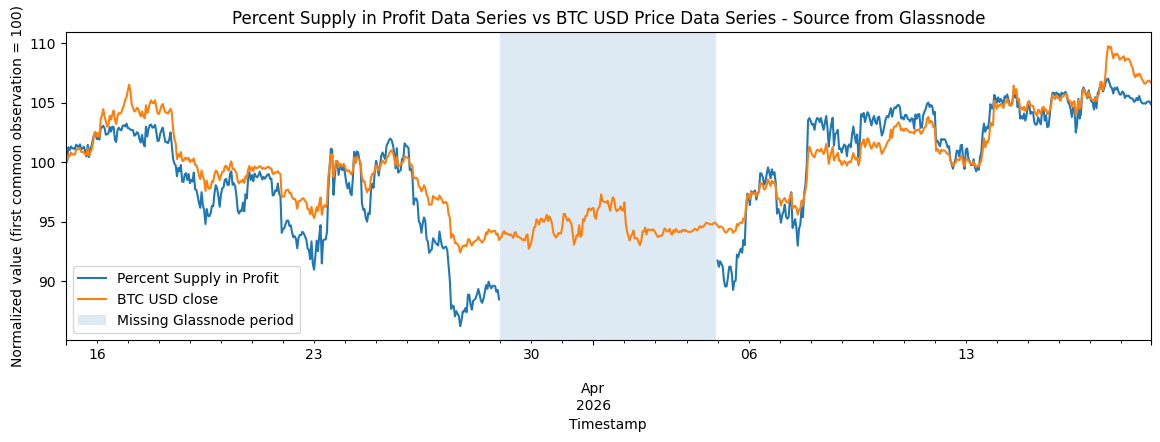

In [ ]:
# Comparison window around the missing timestamps
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode for comparison
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine and normalize the two series
comparison = pd.concat([df_glassnode["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common = comparison.dropna()
normalized = comparison.divide(common.iloc[0]).multiply(100)

# Plot
ax = normalized.plot(figsize=(14, 4), title="Percent Supply in Profit Data Series vs BTC USD Price Data Series - Source from Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Missing Glassnode period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit", "BTC USD close", "Missing Glassnode period"])
plt.show()

The Percent Supply in Profit series and BTC price both fluctuate materially around the missing interval, there are no stable trend to justfiy just a direct mirroring. Alternative rebuild methods are required.

**Endpoint calculation methodology and proposed treatment**

Glassnode’s `supply/profit_relative` metric is calculated as the amount of BTC supply currently in profit divided by circulating supply. Further investigation identified the root cause of the seven-day outage as the unavailability of the hourly `supply/profit_sum` numerator. This established that the missing hourly observations could not be reconstructed directly from the available endpoint components.

The same `supply/profit_relative` metric remained fully populated at 24-hour resolution during the affected week. The daily series is therefore used to reconstruct the missing interval at daily resolution before it is expanded to the hourly index. This preserves the broad movement of the metric but  sacrificing intraday variation during the reconstructed period.

In [ ]:
# Reconstruct Percent Supply in Profit using the complete 24-hour version
pct_supply_col = "pct_supply_profit"
pct_supply_missing_mask = df_glassnode[pct_supply_col].isna()
pct_supply_original = df_glassnode[pct_supply_col].copy()

params = {"a": "BTC", "i": "24h", "s": int(df_glassnode.index.min().timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/supply/profit_relative", params=params)
response.raise_for_status()

pct_supply_daily = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": pct_supply_col})
pct_supply_daily["timestamp"] = pd.to_datetime(pct_supply_daily["timestamp"], unit="s", utc=True)
pct_supply_daily = pct_supply_daily.set_index("timestamp")[[pct_supply_col]].sort_index()
pct_supply_daily = pct_supply_daily.loc[~pct_supply_daily.index.duplicated(keep="first")]
pct_supply_daily = pct_supply_daily.loc[df_glassnode.index.min().floor("D"):df_glassnode.index.max().ceil("D")]

# Expand the daily series to the hourly index
pct_supply_daily_1h = pct_supply_daily.reindex(df_glassnode.index).ffill()

# Replace only the missing hourly observations
pct_supply_profit_1h_clean = pct_supply_original.to_frame()
pct_supply_profit_1h_clean.loc[pct_supply_missing_mask, pct_supply_col] = pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col]
pct_supply_profit_1h_clean["daily_patch_flag"] = pct_supply_missing_mask.astype(int)

pct_supply_profit_1h_clean.to_csv("pct_supply_profit_1h_clean.csv", index_label="timestamp")

print(f"Native hourly missing bars: {pct_supply_missing_mask.sum()}")
print(f"Hourly bars patched: {pct_supply_profit_1h_clean['daily_patch_flag'].sum()}")
print(f"Missing values after reconstruction: {pct_supply_profit_1h_clean[pct_supply_col].isna().sum()}")
print("Saved reconstructed series to: pct_supply_profit_1h_clean.csv")

Native hourly missing bars: 168
Hourly bars patched: 168
Missing values after reconstruction: 0
Saved reconstructed series to: pct_supply_profit_1h_clean.csv


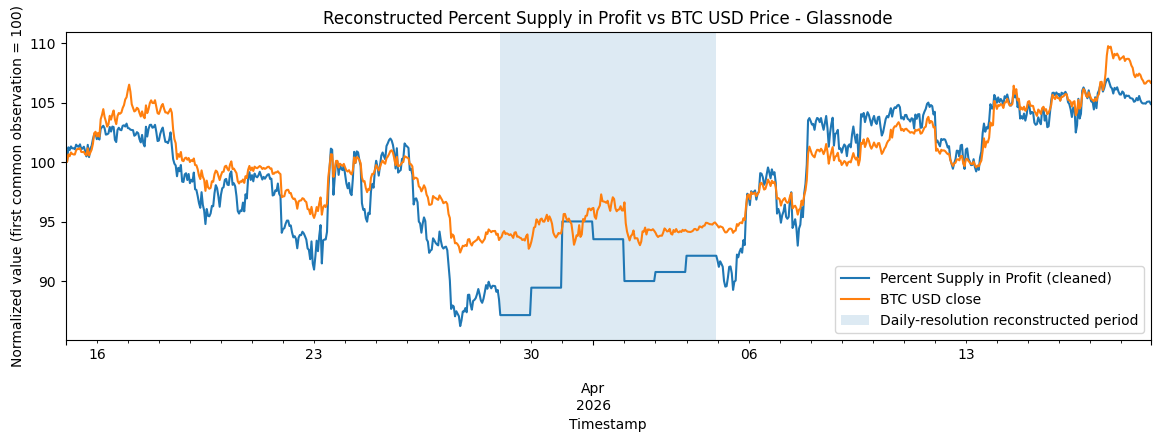

In [ ]:
# Plot the reconstructed Percent Supply in Profit series against BTC price
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine the cleaned series with BTC price and normalize both to 100
comparison_clean = pd.concat([pct_supply_profit_1h_clean["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common_start = comparison_clean.dropna().iloc[0]
normalized_clean = comparison_clean.divide(common_start).multiply(100)

# Plot and retain the shaded reconstructed interval
ax = normalized_clean.plot(figsize=(14, 4), title="Reconstructed Percent Supply in Profit vs BTC USD Price - Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Daily-resolution reconstructed period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit (cleaned)", "BTC USD close", "Daily-resolution reconstructed period"])
plt.show()

**iv) Merging all Glassnode Endpoints in a Point-In-Time Aligned Data File**


In [ ]:
# Load the cleaned native-timestamp Glassnode files
glassnode_raw = pd.read_csv("raw_glassnode.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
pct_supply_clean = pd.read_csv("pct_supply_profit_1h_clean.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
inv_loss_pit = pd.read_csv("inv_loss_daily_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

# Standardize all indices to UTC
glassnode_raw.index = pd.to_datetime(glassnode_raw.index, utc=True)
pct_supply_clean.index = pd.to_datetime(pct_supply_clean.index, utc=True)
inv_loss_pit.index = pd.to_datetime(inv_loss_pit.index, utc=True)

# Remove separately treated endpoints from the raw Glassnode file
glassnode_raw = glassnode_raw.drop(columns=["pct_supply_profit", "inv_loss_seller"], errors="ignore")

# Retain only the reconstructed Percent Supply in Profit values
pct_supply_clean = pct_supply_clean[["pct_supply_profit"]]

# Validate indices before combining
assert glassnode_raw.index.equals(pct_supply_clean.index), "Glassnode and Percent Supply in Profit indices do not match."
assert glassnode_raw.index.equals(inv_loss_pit.index), "Glassnode and inverse-loss indices do not match."
assert not glassnode_raw.index.duplicated().any(), "Duplicate timestamps found in raw Glassnode data."
assert not pct_supply_clean.index.duplicated().any(), "Duplicate timestamps found in Percent Supply in Profit data."
assert not inv_loss_pit.index.duplicated().any(), "Duplicate timestamps found in inverse-loss data."

# Merge the cleaned Percent Supply in Profit series into the native hourly Glassnode dataset
glassnode_1h_clean = glassnode_raw.join(pct_supply_clean, how="left")

# Apply the two-hour PIT lag to all completed 1-hour Glassnode endpoints
glassnode_1h_pit_aligned = glassnode_1h_clean.shift(2)

# Merge the separately two-day-lagged and hourly-expanded inverse-loss endpoint
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(inv_loss_pit[["inv_loss_seller"]], how="left")

# Final validation
assert glassnode_1h_pit_aligned.index.is_monotonic_increasing, "Final Glassnode index is not sorted."
assert not glassnode_1h_pit_aligned.index.duplicated().any(), "Duplicate timestamps found in final Glassnode data."
assert "pct_supply_profit" in glassnode_1h_pit_aligned.columns, "Percent Supply in Profit is missing."
assert "inv_loss_seller" in glassnode_1h_pit_aligned.columns, "Inverse Loss Seller is missing."
assert glassnode_1h_pit_aligned.columns.duplicated().sum() == 0, "Duplicate column names found."

# Save the final PIT-aligned Glassnode dataset
glassnode_1h_pit_aligned.to_csv("glassnode_1h_pit_aligned.csv", index_label="timestamp")

print(f"Final shape: {glassnode_1h_pit_aligned.shape}")
print(f"Date range: {glassnode_1h_pit_aligned.index.min()} to {glassnode_1h_pit_aligned.index.max()}")
print(f"Duplicate timestamps: {glassnode_1h_pit_aligned.index.duplicated().sum()}")
print(f"Duplicate columns: {glassnode_1h_pit_aligned.columns.duplicated().sum()}")
print("Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv")

Final shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicate columns: 0
Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv


### **b) US Dollar Index, S&P500 Index, VIX, 10 Year US Treasury Yield**

Yahoo Finance is used to extract a compact set of broader financial-market indicators that may influence Bitcoin through risk appetite, liquidity conditions, interest rates and US dollar strength.

| Internal name | Yahoo Finance series | Market interpretation |
|---|---|---|
| `dxy` | US Dollar Index | Broad USD strength |
| `spx` | S&P 500 Index | Equity-market risk appetite |
| `vix` | CBOE Volatility Index | Equity-market stress and implied volatility |
| `us10y` | US 10-Year Treasury Yield | Long-term interest-rate conditions |

The series are extracted from 1 January 2019 where available to provide sufficient history for later rolling-feature warm-up.

**i) Data Extraction**

In [ ]:
# extract cross asset data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

cross_asset_tickers = {
    "DX-Y.NYB": "dxy",
    "^GSPC": "spx",
    "^VIX": "vix",
    "^TNX": "us10y"}

df_cross_asset = (yf.download(list(cross_asset_tickers),
     start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False)["Close"]
    .rename(columns=cross_asset_tickers)
    .sort_index())

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_csv("raw_cross_asset.csv", index_label="timestamp")
df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


**ii) Data Quality Check**

In [ ]:
# Cross-asset data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset.index.duplicated().sum()}")

cross_asset_check_cols = ["dxy", "spx", "vix", "us10y"]
cross_asset_nan_summary = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    cross_asset_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

cross_asset_nan_summary = pd.DataFrame(cross_asset_nan_summary).set_index("series")
print(f"Total missing values across checked series: {int(cross_asset_nan_summary['missing_count'].sum())}")
print(f"Series with internal NaN values: {int(cross_asset_nan_summary['has_internal_nan'].sum())}")

cross_asset_nan_summary

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked series: 9
Series with internal NaN values: 4


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
dxy,1,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,1,True
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2,True
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True


iii) Data Cleaning


Examining the NaN profile, determine if simple ffill is appropriate given small gaps in the data


In [ ]:
# Isolate every internal NaN timestamp for each investigated cross-asset series
cross_asset_internal_nan_dates = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]
    missing_dates = active_series.index[active_series.isna()]

    for missing_date in missing_dates:
        cross_asset_internal_nan_dates.append({
            "series": col,
            "missing_timestamp": missing_date})

cross_asset_internal_nan_dates = pd.DataFrame(cross_asset_internal_nan_dates)
if not cross_asset_internal_nan_dates.empty:
    cross_asset_internal_nan_dates = cross_asset_internal_nan_dates.sort_values(["series", "missing_timestamp"]).reset_index(drop=True)

cross_asset_internal_nan_dates

,series,missing_timestamp
0,dxy,2026-05-25 00:00:00+00:00
1,spx,2025-01-09 00:00:00+00:00
2,spx,2025-05-26 00:00:00+00:00
3,spx,2026-05-25 00:00:00+00:00
4,us10y,2025-01-09 00:00:00+00:00
5,us10y,2025-05-26 00:00:00+00:00
6,us10y,2026-05-25 00:00:00+00:00
7,vix,2025-01-09 00:00:00+00:00
8,vix,2025-05-26 00:00:00+00:00


Missing data are all evolved around 2 specific dates where stock market closure. Simple forward fill applied to missing data.

In [ ]:
# Forward-fill internal missing values in the native daily cross-asset series
df_cross_asset = df_cross_asset.ffill()
print(f"Missing values after forward-fill: {df_cross_asset.isna().sum().sum()}")

Missing values after forward-fill: 0


**iv) Creating Point-In-Time Aligned Data File**

In [ ]:
# Apply the T+1-calendar-day PIT lag and expand the daily series to an hourly spine
df_cross_asset_pit_daily = df_cross_asset.copy()
df_cross_asset_pit_daily.index = df_cross_asset_pit_daily.index + pd.Timedelta(days=1)

cross_asset_hourly_index = pd.date_range(
    start=df_cross_asset_pit_daily.index.min(),
    end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"),
    freq="1h")

df_cross_asset_1h_pit = df_cross_asset_pit_daily.reindex(cross_asset_hourly_index).ffill()
df_cross_asset_1h_pit.index.name = "timestamp"

print(f"Shape: {df_cross_asset_1h_pit.shape}")
print(f"Date range: {df_cross_asset_1h_pit.index.min()} to {df_cross_asset_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_cross_asset_1h_pit.isna().sum().sum())}")

df_cross_asset_1h_pit.to_csv("cross_asset_1h_pit_aligned.csv", index_label="timestamp")
df_cross_asset_1h_pit.head()

Shape: (65664, 4)
Date range: 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


Ticker,dxy,spx,us10y,vix
timestamp,,,,
2019-01-03 00:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 01:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 02:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 03:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 04:00:00+00:00,96.82,2510.030029,2.661,23.219999


### **c) Centralised-Exchange (CEX) Data**

Centralised exchanges, including Binance, OKX and Coinbase, provide the core traded-market information used in this study, including prices, trading activity, perpetual premium and funding rates that may influence BTCUSDT perpetual-futures direction. These data are publicly available from the respective exchanges and their archives.

| Source | Data extracted | Primary role |
|---|---|---|
| Binance USD-margined futures | BTCUSDT and ETHUSDT hourly OHLCV, quote volume, trade counts and taker-buy volume | Prediction target, price, momentum, volume, order flow and cross-crypto conditions |
| Binance derivatives endpoints | BTCUSDT perpetual premium-index OHLC and funding rate | Perpetual basis, funding and positioning conditions |
| Coinbase Exchange | BTC-USD hourly spot close | Cross-exchange spot-price reference |
| OKX | BTC-USDT perpetual hourly close | Cross-exchange perpetual-price reference |

The market series are extracted from 1 January 2019 where available and retained at their native frequency before timestamp, coverage and missing-value checks are performed.

**i) Binance K-line data**

**Data Extraction**

In [ ]:
# Binance USD-M perpetual-futures kline extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")
kline_columns = ["open_time", "open", "high", "low", "close", "volume", "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]
binance_kline_data = {}

for endpoint in binance_kline_endpoints:
    monthly_frames = []
    months = pd.period_range(start=endpoint["start_month"], end="2026-06", freq="M")

    for month in months:
        month = str(month)
        url = f"https://data.binance.vision/data/futures/um/monthly/klines/{endpoint['symbol']}/{endpoint['interval']}/{endpoint['symbol']}-{endpoint['interval']}-{month}.zip"
        response = requests.get(url, timeout=30)

        if response.status_code == 404:
            print(f"No archive found: {endpoint['symbol']} {month}")
            continue

        response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            with archive.open(archive.namelist()[0]) as file:
                monthly_frames.append(pd.read_csv(file, header=None, names=kline_columns))

    if not monthly_frames:
        raise ValueError(f"No kline data returned for {endpoint['symbol']}")

    asset_data = pd.concat(monthly_frames, ignore_index=True)
    open_time_numeric = pd.to_numeric(asset_data["open_time"], errors="coerce")
    open_time_ms = open_time_numeric.where(open_time_numeric < 1e14, open_time_numeric / 1000)
    asset_data["timestamp"] = pd.to_datetime(open_time_ms, unit="ms", utc=True, errors="coerce")

    invalid_timestamp_rows = int(asset_data["timestamp"].isna().sum())
    asset_data = asset_data.dropna(subset=["timestamp"])
    asset_data = asset_data.loc[asset_data["timestamp"] < analysis_end]
    asset_data = asset_data.drop(columns=["open_time", "close_time", "ignore"])

    duplicate_rows = int(asset_data.duplicated().sum())
    asset_data = asset_data.drop_duplicates()
    asset_data = asset_data.set_index("timestamp").sort_index()

    duplicated_timestamp_rows = int(asset_data.index.duplicated(keep=False).sum())
    asset_data = asset_data.loc[~asset_data.index.duplicated(keep=False)]
    asset_data = asset_data.apply(pd.to_numeric, errors="coerce")
    asset_data.columns = [f"{endpoint['name']}_{col}" for col in asset_data.columns]

    print(f"{endpoint['symbol']} invalid timestamp rows removed: {invalid_timestamp_rows}")
    print(f"{endpoint['symbol']} exact duplicate rows removed: {duplicate_rows}")
    print(f"{endpoint['symbol']} duplicated timestamp rows removed: {duplicated_timestamp_rows}")

    binance_kline_data[endpoint["name"]] = asset_data

df_binance_klines = pd.concat([binance_kline_data["btc"], binance_kline_data["eth"]], axis=1).sort_index()
df_binance_klines.to_csv("raw_binance_klines.csv", index_label="timestamp")
df_binance_klines.head()

No archive found: BTCUSDT 2019-09
No archive found: BTCUSDT 2019-10
No archive found: BTCUSDT 2019-11
No archive found: BTCUSDT 2019-12
BTCUSDT invalid timestamp rows removed: 54
BTCUSDT exact duplicate rows removed: 0
BTCUSDT duplicated timestamp rows removed: 0
No archive found: ETHUSDT 2019-11
No archive found: ETHUSDT 2019-12
ETHUSDT invalid timestamp rows removed: 54
ETHUSDT exact duplicate rows removed: 0
ETHUSDT duplicated timestamp rows removed: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume
timestamp,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,129.12,128.62,128.82,14947.691,1.925644e+06,1249,7707.625,9.928838e+05
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,130.61,128.76,130.57,34755.256,4.514484e+06,3116,19928.267,2.588555e+06
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,130.97,130.30,130.80,21864.946,2.857378e+06,1807,10299.172,1.345962e+06
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,130.82,129.88,130.09,16823.171,2.190835e+06,1448,7580.536,9.869013e+05
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,130.63,130.09,130.15,11357.239,1.480319e+06,1065,5204.925,6.783015e+05


**Data Quality Check**


In [ ]:
# Binance kline data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"Duplicate timestamps: {df_binance_klines.index.duplicated().sum()}")

binance_kline_check_cols = df_binance_klines.columns.tolist()
binance_kline_nan_summary = []

for col in binance_kline_check_cols:
    series = df_binance_klines[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_kline_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

binance_kline_nan_summary = pd.DataFrame(binance_kline_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(binance_kline_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_kline_nan_summary['has_internal_nan'].sum())}")

binance_kline_nan_summary

Shape: (56952, 18)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_num_trades,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


No data cleaning work required.

**ii) Binance perpetual premium-index data**


Binance premium-index data could not be retrieved reliably from the public archive. An alternative public API was available, but access from Google Colab was blocked by an HTTP 451 geographic/IP restriction. The extraction was therefore implemented as a standalone reproducible Python module and run once from an unrestricted local network. The resulting raw CSV was versioned and frozen for the submitted analysis, while the notebook retains the extraction code and validates the saved file’s schema, coverage, timestamp continuity and integrity before use.

In [ ]:
# Load the Binance BTC perpetual premium-index series
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"
os.chdir(raw_data_dir)

df_binance_premium = pd.read_csv("raw_binance_perp_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium.index = pd.to_datetime(df_binance_premium.index, utc=True)

df_binance_premium = df_binance_premium.loc[(df_binance_premium.index >= pd.Timestamp("2020-01-01 00:00:00", tz="UTC")) & (df_binance_premium.index < analysis_end)]
premium_cols = ["btc_perp_premium_open", "btc_perp_premium_high", "btc_perp_premium_low", "btc_perp_premium_close"]

df_binance_premium = df_binance_premium[premium_cols].apply(pd.to_numeric, errors="coerce")
df_binance_premium.head()

,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close
timestamp,,,,
2020-01-01 00:00:00+00:00,-0.000777,-0.000443,-0.001206,-0.000809
2020-01-01 01:00:00+00:00,-0.000818,-0.000100,-0.001015,-0.000801
2020-01-01 02:00:00+00:00,-0.000445,-0.000445,-0.001063,-0.000554
2020-01-01 03:00:00+00:00,-0.000412,-0.000295,-0.001005,-0.000627
2020-01-01 04:00:00+00:00,-0.000523,-0.000296,-0.000887,-0.000517


**Data Quality Check**

In [ ]:
# Binance premium-index data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"Duplicate timestamps: {df_binance_premium.index.duplicated().sum()}")

binance_premium_check_cols = df_binance_premium.columns.tolist()
binance_premium_nan_summary = []

for col in binance_premium_check_cols:
    series = df_binance_premium[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_premium_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

binance_premium_nan_summary = pd.DataFrame(binance_premium_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_premium_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_premium_nan_summary['has_internal_nan'].sum())}")

binance_premium_nan_summary

Shape: (56951, 4)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_perp_premium_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False


In [ ]:
# Check for missing hourly timestamps in the Binance premium-index series
premium_expected_index = pd.date_range(start=df_binance_premium.index.min(), end=df_binance_premium.index.max(), freq="h")
premium_missing_timestamps = premium_expected_index.difference(df_binance_premium.index)

print(f"Missing hourly timestamps: {len(premium_missing_timestamps)}")
premium_missing_timestamps

Missing hourly timestamps: 1


DatetimeIndex(['2020-12-01 23:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')

**Data Cleaning**

In [ ]:
# Forward-fill the single missing Binance premium-index hour
premium_full_index = pd.date_range(start=df_binance_premium.index.min(), end=analysis_end - pd.Timedelta(hours=1), freq="h")

df_binance_premium = df_binance_premium.reindex(premium_full_index)
df_binance_premium.index.name = "timestamp"

missing_before = int(df_binance_premium.isna().all(axis=1).sum())
df_binance_premium = df_binance_premium.ffill(limit=1)
missing_after = int(df_binance_premium.isna().all(axis=1).sum())

print(f"Missing premium rows before forward-fill: {missing_before}")
print(f"Missing premium rows after forward-fill: {missing_after}")

Missing premium rows before forward-fill: 1
Missing premium rows after forward-fill: 0


In [ ]:
# save file to csv
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

**iii) Binance Funding Rate Endpoint**

**Data Extraction**

In [ ]:
# Binance BTC funding-rate extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_funding_endpoint = {"name": "btc_funding", "symbol": "BTCUSDT", "start_month": "2019-09"}
funding_monthly_frames = []
funding_months = pd.period_range(start=binance_funding_endpoint["start_month"], end="2026-06", freq="M")

for month in funding_months:
    month = str(month)
    url = f"https://data.binance.vision/data/futures/um/monthly/fundingRate/{binance_funding_endpoint['symbol']}/{binance_funding_endpoint['symbol']}-fundingRate-{month}.zip"
    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: {binance_funding_endpoint['symbol']} funding {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        with archive.open(archive.namelist()[0]) as file:
            funding_monthly_frames.append(pd.read_csv(file))

if not funding_monthly_frames: raise ValueError("No Binance BTC funding-rate data returned")

df_binance_funding = pd.concat(funding_monthly_frames, ignore_index=True)
df_binance_funding.columns = [str(col).strip() for col in df_binance_funding.columns]
df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_binance_funding["timestamp"].isna().sum())
df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])
df_binance_funding = df_binance_funding.loc[df_binance_funding["timestamp"] < analysis_end]
df_binance_funding = df_binance_funding.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_binance_funding.index.duplicated(keep=False).sum())
df_binance_funding = df_binance_funding.loc[~df_binance_funding.index.duplicated(keep=False)]

df_binance_funding = df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"})
df_binance_funding["btc_funding"] = pd.to_numeric(df_binance_funding["btc_funding"], errors="coerce")

print(f"BTC funding invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"BTC funding duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_binance_funding.to_csv("raw_binance_funding.csv", index_label="timestamp")
df_binance_funding.head()

No archive found: BTCUSDT funding 2019-09
No archive found: BTCUSDT funding 2019-10
No archive found: BTCUSDT funding 2019-11
No archive found: BTCUSDT funding 2019-12
BTC funding invalid timestamp rows removed: 0
BTC funding duplicated timestamp rows removed: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


**Data Quality Check**

In [ ]:
# Binance funding-rate data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding.index.duplicated().sum()}")

binance_funding_check_cols = df_binance_funding.columns.tolist()
binance_funding_nan_summary = []

for col in binance_funding_check_cols:
    series = df_binance_funding[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_funding_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

binance_funding_nan_summary = pd.DataFrame(binance_funding_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(binance_funding_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_funding_nan_summary['has_internal_nan'].sum())}")

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**Data Cleaning**

While there are no missing values in the data series, there are some odd index display which requires data cleaning



In [ ]:
# Find funding timestamps that are not exactly aligned to the hour
funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [ ]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [ ]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC, check for mis-aligned timestamps
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


**Creating Point-In-Time Aligned Data File**

BTC funding rate settles every 8 hours, as such we need to transform this series into a point-in-time aligned data towards the one hour resolution level.



In [ ]:
# Expand the T+0 Binance funding-rate series from its native 8-hour cadence to an hourly spine

funding_hourly_index = pd.date_range(start=df_binance_funding.index.min(), end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"), freq="1h")

df_binance_funding_1h_pit = df_binance_funding.reindex(funding_hourly_index).ffill()
df_binance_funding_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_funding_1h_pit.shape}")
print(f"Date range: {df_binance_funding_1h_pit.index.min()} to {df_binance_funding_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_binance_funding_1h_pit.isna().sum().sum())}")

df_binance_funding_1h_pit.to_csv("binance_funding_1h_pit_aligned.csv", index_label="timestamp")

Shape: (56952, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


**Merge all binance endpoint into a single csv file**

In [ ]:
# Load the completed Binance source files for the final source-level merge
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_binance_klines_merge = pd.read_csv("raw_binance_klines.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium_merge = pd.read_csv("raw_binance_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_funding_merge = pd.read_csv("binance_funding_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

for df in [df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge]:
    df.index = pd.to_datetime(df.index, utc=True)

df_binance_1h_pit = pd.concat([df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge], axis=1).sort_index()
df_binance_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_1h_pit.shape}")
print(f"Date range: {df_binance_1h_pit.index.min()} to {df_binance_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_1h_pit.index.duplicated().sum()}")
print(f"Total missing values: {int(df_binance_1h_pit.isna().sum().sum())}")

df_binance_1h_pit.to_csv("binance_1h_pit_aligned.csv", index_label="timestamp")
df_binance_1h_pit.head()

Shape: (56952, 23)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,...,14947.691,1.925644e+06,1249,7707.625,9.928838e+05,-0.000777,-0.000443,-0.001206,-0.000809,-0.000124
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,...,34755.256,4.514484e+06,3116,19928.267,2.588555e+06,-0.000818,-0.000100,-0.001015,-0.000801,-0.000124
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,...,21864.946,2.857378e+06,1807,10299.172,1.345962e+06,-0.000445,-0.000445,-0.001063,-0.000554,-0.000124
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,...,16823.171,2.190835e+06,1448,7580.536,9.869013e+05,-0.000412,-0.000295,-0.001005,-0.000627,-0.000124
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,...,11357.239,1.480319e+06,1065,5204.925,6.783015e+05,-0.000523,-0.000296,-0.000887,-0.000517,-0.000124


**iv) Coinbase BTC USD spot price** </br>

**Data extraction**

In [ ]:
# Coinbase BTC-USD hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

coinbase_endpoint = {
    "name": "coinbase_btc_close",
    "url": "https://api.exchange.coinbase.com/products/BTC-USD/candles",
    "granularity": 3600,
    "start": "2019-01-01",
    "end": "2026-07-01"}

coinbase_rows = []
start_time = pd.Timestamp(coinbase_endpoint["start"], tz="UTC")
end_time = pd.Timestamp(coinbase_endpoint["end"], tz="UTC")

while start_time < end_time:
    window_end = min(start_time + pd.Timedelta(hours=300), end_time)
    params = {"granularity": coinbase_endpoint["granularity"], "start": start_time.isoformat(), "end": window_end.isoformat()}
    response = requests.get(coinbase_endpoint["url"], params=params, headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()
    data = response.json()

    if not isinstance(data, list): raise ValueError(f"Coinbase returned an unexpected response: {data}")
    coinbase_rows.extend(data)
    start_time = window_end
    time.sleep(0.1)

df_coinbase = pd.DataFrame(coinbase_rows, columns=["timestamp", "low", "high", "open", "close", "volume"])
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_coinbase["timestamp"].isna().sum())
df_coinbase = df_coinbase.dropna(subset=["timestamp"])
df_coinbase = df_coinbase.loc[df_coinbase["timestamp"] < end_time]
df_coinbase = df_coinbase.set_index("timestamp").sort_index()

exact_duplicate_rows = int(df_coinbase.duplicated().sum())
df_coinbase = df_coinbase.drop_duplicates()

duplicate_timestamp_rows = int(df_coinbase.index.duplicated(keep=False).sum())
df_coinbase = df_coinbase.loc[~df_coinbase.index.duplicated(keep=False)]

df_coinbase = df_coinbase[["close"]].rename(columns={"close": coinbase_endpoint["name"]})
df_coinbase["coinbase_btc_close"] = pd.to_numeric(df_coinbase["coinbase_btc_close"], errors="coerce")
df_coinbase.index.name = "timestamp"

print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_coinbase.to_csv("coinbase_1h_pit_aligned.csv", index_label="timestamp")
df_coinbase.head()

Invalid timestamp rows removed: 0
Exact duplicate rows removed: 219
Duplicated timestamp rows removed: 0


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


**Data Quality Check**


In [ ]:
# Coinbase data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"Duplicate timestamps: {df_coinbase.index.duplicated().sum()}")

coinbase_check_cols = df_coinbase.columns.tolist()
coinbase_nan_summary = []

for col in coinbase_check_cols:
    series = df_coinbase[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    coinbase_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

coinbase_nan_summary = pd.DataFrame(coinbase_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(coinbase_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(coinbase_nan_summary['has_internal_nan'].sum())}")

Shape: (65693, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**v) OKX BTC-USDT Perpetual Hourly Data**

**Data Extraction**

In [ ]:
# OKX BTC-USDT perpetual hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

okx_endpoint = {"name": "okx_btc_close", "instrument": "BTC-USDT-SWAP", "bar": "1H", "url": "https://www.okx.com/api/v5/market/history-candles", "limit": 300}
okx_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
okx_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

okx_rows = []
after = None

while True:
    params = {"instId": okx_endpoint["instrument"], "bar": okx_endpoint["bar"], "limit": okx_endpoint["limit"]}

    if after is not None: params["after"] = after
    response = requests.get(okx_endpoint["url"], params=params, timeout=30)
    response.raise_for_status()
    body = response.json()

    if body.get("code") != "0": raise ValueError(f"OKX returned code {body.get('code')}: {body.get('msg')}")
    data = body.get("data", [])

    if not data: break
    okx_rows.extend(data)
    oldest_timestamp_ms = min(int(row[0]) for row in data)
    oldest_timestamp = pd.to_datetime(oldest_timestamp_ms, unit="ms", utc=True)

    if oldest_timestamp <= okx_start_time: break

    if after is not None and oldest_timestamp_ms >= int(after):
        print("OKX pagination stopped because the cursor did not move backward.")
        break

    after = oldest_timestamp_ms
    time.sleep(0.1)

if not okx_rows: raise ValueError("No OKX BTC hourly candle data returned")

okx_columns = ["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"]
df_okx = pd.DataFrame(okx_rows, columns=okx_columns)

exact_duplicate_rows = int(df_okx.duplicated().sum())
df_okx = df_okx.drop_duplicates()

df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_okx["timestamp"].isna().sum())
df_okx = df_okx.dropna(subset=["timestamp"])

unconfirmed_rows = int((df_okx["confirm"].astype(str) != "1").sum())
df_okx = df_okx.loc[df_okx["confirm"].astype(str) == "1"]
df_okx = df_okx.loc[(df_okx["timestamp"] >= okx_start_time) & (df_okx["timestamp"] <= okx_end_time)]
df_okx = df_okx.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_okx.index.duplicated(keep=False).sum())
df_okx = df_okx.loc[~df_okx.index.duplicated(keep=False)]

df_okx = df_okx[["close"]].rename(columns={"close": okx_endpoint["name"]})
df_okx["okx_btc_close"] = pd.to_numeric(df_okx["okx_btc_close"], errors="coerce")
df_okx.index.name = "timestamp"

print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Unconfirmed rows removed: {unconfirmed_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_okx.to_csv("okx_1h_pit_aligned.csv", index_label="timestamp")
df_okx.head()

Exact duplicate rows removed: 0
Invalid timestamp rows removed: 0
Unconfirmed rows removed: 1
Duplicated timestamp rows removed: 0


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


**Data Quality Check**

In [ ]:
# OKX data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"Duplicate timestamps: {df_okx.index.duplicated().sum()}")

okx_check_cols = df_okx.columns.tolist()
okx_nan_summary = []

for col in okx_check_cols:
    series = df_okx[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    okx_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

okx_nan_summary = pd.DataFrame(okx_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(okx_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(okx_nan_summary['has_internal_nan'].sum())}")

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**vi) Deribit endpoints**

Deribit is a major cryptocurrency derivatives exchange and provides the contract-level futures data used to examine Bitcoin term structure. The extraction covers the BTC perpetual contract and a changing set of dated quarterly futures, including hourly prices, volume, notional activity and expiry information. These data are retained as a panel because several contracts coexist at each timestamp and the active contract set changes through time.

**Data Extraction**

In [ ]:
# Deribit BTC perpetual and quarterly futures extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

deribit_endpoint = {"name": "deribit_btc_futures", "url": "https://www.deribit.com/api/v2/public/get_tradingview_chart_data", "resolution": "60"}
deribit_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
deribit_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

def last_friday(year, month):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

    while month_end.dayofweek != 4:
        month_end -= pd.Timedelta(days=1)

    return month_end

deribit_instruments = [{
    "instrument_name": "BTC-PERPETUAL",
    "instrument_family": "perpetual",
    "settlement_period": "perpetual",
    "expiration_timestamp_ms": pd.NA,
    "expiration_timestamp": pd.NaT}]

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:
        expiry_date = last_friday(year, month)
        expiry_timestamp = pd.Timestamp(year=year, month=month, day=expiry_date.day, hour=8, tz="UTC")
        instrument_name = f"BTC-{expiry_timestamp.day}{expiry_timestamp.strftime('%b').upper()}{expiry_timestamp.strftime('%y')}"

        deribit_instruments.append({
            "instrument_name": instrument_name,
            "instrument_family": "quarterly",
            "settlement_period": "month",
            "expiration_timestamp_ms": int(expiry_timestamp.timestamp() * 1000),
            "expiration_timestamp": expiry_timestamp})

df_deribit_instruments = pd.DataFrame(deribit_instruments)

print(f"Deribit candidate instruments: {len(df_deribit_instruments)}")
display(df_deribit_instruments.head())

deribit_frames = []
deribit_unavailable_instruments = []

for instrument in deribit_instruments:
    instrument_name = instrument["instrument_name"]
    expiration_timestamp = instrument["expiration_timestamp"]
    instrument_end_time = min(deribit_end_time, expiration_timestamp) if pd.notna(expiration_timestamp) else deribit_end_time

    if instrument_end_time < deribit_start_time:
        continue

    window_start = deribit_start_time
    instrument_returned_data = False
    instrument_request_failed = False

    while window_start < instrument_end_time:
        window_end = min(window_start + pd.Timedelta(days=30), instrument_end_time)

        params = {
            "instrument_name": instrument_name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": deribit_endpoint["resolution"]}

        response = requests.get(deribit_endpoint["url"], params=params, timeout=30)

        if response.status_code == 400:
            instrument_request_failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            instrument_request_failed = True
            break

        result = body.get("result", {})
        ticks = result.get("ticks", [])

        if result.get("status") == "ok" and ticks:
            candle_count = len(ticks)

            candle_frame = pd.DataFrame({
                "timestamp_ms": ticks,
                "open": result.get("open", [None] * candle_count),
                "high": result.get("high", [None] * candle_count),
                "low": result.get("low", [None] * candle_count),
                "close": result.get("close", [None] * candle_count),
                "volume": result.get("volume", [None] * candle_count),
                "cost": result.get("cost", [None] * candle_count)})

            candle_frame["instrument_name"] = instrument_name
            candle_frame["instrument_family"] = instrument["instrument_family"]
            candle_frame["settlement_period"] = instrument["settlement_period"]
            candle_frame["expiration_timestamp_ms"] = instrument["expiration_timestamp_ms"]
            candle_frame["expiration_timestamp"] = instrument["expiration_timestamp"]

            deribit_frames.append(candle_frame)
            instrument_returned_data = True

        window_start = window_end
        time.sleep(0.1)

    if instrument_request_failed or not instrument_returned_data:
        deribit_unavailable_instruments.append(instrument_name)

if not deribit_frames:
    raise ValueError("No Deribit BTC futures candle data returned")

print(f"Deribit instruments returning data: {len(deribit_instruments) - len(deribit_unavailable_instruments)}")
print(f"Deribit candidate instruments without returned data: {len(deribit_unavailable_instruments)}")

if deribit_unavailable_instruments:
    print(deribit_unavailable_instruments)

df_deribit_futures = pd.concat(deribit_frames, ignore_index=True)

df_deribit_futures["timestamp"] = pd.to_datetime(pd.to_numeric(df_deribit_futures["timestamp_ms"], errors="coerce"), unit="ms", utc=True, errors="coerce")
df_deribit_futures["expiration_timestamp"] = pd.to_datetime(df_deribit_futures["expiration_timestamp"], utc=True, errors="coerce")

deribit_numeric_cols = ["open", "high", "low", "close", "volume", "cost"]
df_deribit_futures[deribit_numeric_cols] = df_deribit_futures[deribit_numeric_cols].apply(pd.to_numeric, errors="coerce")

df_deribit_futures = df_deribit_futures.loc[(df_deribit_futures["timestamp"] >= deribit_start_time) & (df_deribit_futures["timestamp"] <= deribit_end_time)]
df_deribit_futures = df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

df_deribit_futures.to_csv("raw_deribit_btc_futures.csv", index=False)
df_deribit_futures.head()

Deribit candidate instruments: 37


,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp
0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT
1,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00
2,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00
3,BTC-27SEP19,quarterly,month,1569571200000,2019-09-27 08:00:00+00:00
4,BTC-27DEC19,quarterly,month,1577433600000,2019-12-27 08:00:00+00:00


Deribit instruments returning data: 35
Deribit candidate instruments without returned data: 2
['BTC-24SEP27', 'BTC-31DEC27']


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


**Data Quality Check**

In [ ]:
# Deribit data quality checks: panel structure, duplicates, invalid timestamps, post-expiry rows and missing values
print(f"Shape: {df_deribit_futures.shape}")
print(f"Date range: {df_deribit_futures['timestamp'].min()} to {df_deribit_futures['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures['instrument_name'].nunique()}")

exact_duplicate_rows = int(df_deribit_futures.duplicated().sum())
invalid_timestamp_rows = int(df_deribit_futures["timestamp"].isna().sum())

duplicate_contract_timestamp_rows = int(
    df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False).sum())

post_expiry_mask = (
    df_deribit_futures["expiration_timestamp"].notna()
    & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"]))

post_expiry_rows = int(post_expiry_mask.sum())

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Invalid timestamp rows: {invalid_timestamp_rows}")
print(f"Duplicated instrument-timestamp rows: {duplicate_contract_timestamp_rows}")
print(f"Post-expiry rows: {post_expiry_rows}")

deribit_check_cols = ["open", "high", "low", "close", "volume", "cost"]
deribit_nan_summary = []

for col in deribit_check_cols:
    series = df_deribit_futures[col]
    first_valid = df_deribit_futures.loc[series.notna(), "timestamp"].min()
    last_valid = df_deribit_futures.loc[series.notna(), "timestamp"].max()

    deribit_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "has_missing_values": bool(series.isna().any())})

deribit_nan_summary = pd.DataFrame(deribit_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(deribit_nan_summary['missing_count'].sum())}")
print(f"Fields with missing values: {int(deribit_nan_summary['has_missing_values'].sum())}")

Shape: (298630, 13)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Instruments: 35
Exact duplicate rows: 415
Invalid timestamp rows: 0
Duplicated instrument-timestamp rows: 830
Post-expiry rows: 0
Total missing values across checked fields: 0
Fields with missing values: 0


In [ ]:
# Check missing hourly timestamps within each Deribit contract's active observed period
deribit_missing_summary = []
deribit_missing_timestamps = []

for instrument_name, instrument_data in df_deribit_futures.groupby("instrument_name"):
    instrument_data = instrument_data.sort_values("timestamp")
    first_timestamp = instrument_data["timestamp"].min()
    last_timestamp = instrument_data["timestamp"].max()
    expected_index = pd.date_range(start=first_timestamp, end=last_timestamp, freq="1h")
    observed_index = pd.DatetimeIndex(instrument_data["timestamp"])
    missing_index = expected_index.difference(observed_index)

    deribit_missing_summary.append({
        "instrument_name": instrument_name,
        "first_timestamp": first_timestamp,
        "last_timestamp": last_timestamp,
        "observed_rows": len(instrument_data),
        "expected_rows": len(expected_index),
        "missing_hour_count": len(missing_index),
        "has_missing_hours": bool(len(missing_index))})

    for missing_timestamp in missing_index:
        deribit_missing_timestamps.append({
            "instrument_name": instrument_name,
            "missing_timestamp": missing_timestamp})

deribit_missing_summary = pd.DataFrame(deribit_missing_summary).set_index("instrument_name").sort_index()
deribit_missing_timestamps = pd.DataFrame(deribit_missing_timestamps)

print(f"Contracts with missing hours: {int(deribit_missing_summary['has_missing_hours'].sum())}")
print(f"Total missing contract-hours: {int(deribit_missing_summary['missing_hour_count'].sum())}")

Contracts with missing hours: 0
Total missing contract-hours: 0


**Data Cleaning**

Removing duplicated rows from the Deribit contract panels

In [ ]:
# Remove exact duplicate rows from the Deribit contract panel
rows_before = len(df_deribit_futures)
df_deribit_futures = df_deribit_futures.drop_duplicates().sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
rows_after = len(df_deribit_futures)

print(f"Exact duplicate rows removed: {rows_before - rows_after}")
print(f"Remaining duplicated instrument-timestamp rows: {df_deribit_futures.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Cleaned shape: {df_deribit_futures.shape}")
df_deribit_futures.to_csv("deribit_btc_futures_clean.csv", index=False)

Exact duplicate rows removed: 0
Remaining duplicated instrument-timestamp rows: 0
Cleaned shape: (298215, 13)


**Creating Point-In-Time Aligned Data File**


In [ ]:
# Apply the T+1-hour PIT lag to the cleaned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = df_deribit_futures.copy()
df_deribit_futures_pit["timestamp"] = df_deribit_futures_pit["timestamp"] + pd.Timedelta(hours=1)
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Missing values in market fields: {int(df_deribit_futures_pit[['open', 'high', 'low', 'close', 'volume', 'cost']].isna().sum().sum())}")

df_deribit_futures_pit.to_csv("deribit_btc_futures_pit_aligned.csv", index=False)
df_deribit_futures_pit.head()

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Duplicated instrument-timestamp rows: 0
Missing values in market fields: 0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 01:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 02:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 02:00:00+00:00


## **(III) Raw Data Merge & Data Set Partitioning**


The completed point-in-time-aligned source files are combined into a common hourly modelling dataset. The Deribit contract panel is retained separately because multiple futures contracts coexist at each timestamp and will later be converted into fixed-dimensional features.

The merged dataset is audited for timestamp integrity, duplicate columns and internal missing values before the modelling period, prediction targets and chronological train-test partitions are defined.

### **a) Load Cleaned Raw Data**

**i) Loading Deribit data - cleaned and point-in-time aligned**

In [4]:
# Load the PIT-aligned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = pd.read_csv("deribit_btc_futures_pit_aligned.csv", parse_dates=["timestamp", "expiration_timestamp"])
df_deribit_futures_pit["timestamp"] = pd.to_datetime(df_deribit_futures_pit["timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit["expiration_timestamp"] = pd.to_datetime(df_deribit_futures_pit["expiration_timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Invalid timestamps: {df_deribit_futures_pit['timestamp'].isna().sum()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(['timestamp', 'instrument_name']).sum()}")

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Invalid timestamps: 0
Duplicated instrument-timestamp rows: 0


**ii) Loading Glassnode, yfinance, CEX data - cleaned and point-in-time aligned**

In [5]:
# Load the completed PIT-aligned hourly source files
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

hourly_source_files = {
    "binance": "binance_1h_pit_aligned.csv",
    "coinbase": "coinbase_1h_pit_aligned.csv",
    "okx": "okx_1h_pit_aligned.csv",
    "glassnode": "glassnode_1h_pit_aligned.csv",
    "cross_asset": "cross_asset_1h_pit_aligned.csv"}

hourly_sources = {}

for source_name, filename in hourly_source_files.items():
    source_df = pd.read_csv(filename, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
    source_df.index = pd.to_datetime(source_df.index, utc=True)
    source_df.index.name = "timestamp"
    hourly_sources[source_name] = source_df

    print(f"{source_name}: {source_df.shape} | {source_df.index.min()} to {source_df.index.max()} | duplicates: {source_df.index.duplicated().sum()}")

binance: (56952, 23) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
coinbase: (65693, 1) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
cross_asset: (65664, 4) | 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0


### **b) Merge Hourly Data Sources**

The fixed-dimensional hourly source files are merged on their common UTC timestamp index. The Deribit contract panel remains separate.

In [6]:
# Merge all finalized PIT-aligned one-row-per-hour source files
df_merged_1h_pit = pd.concat([
    hourly_sources["binance"],
    hourly_sources["coinbase"],
    hourly_sources["okx"],
    hourly_sources["glassnode"],
    hourly_sources["cross_asset"]], axis=1, join="outer").sort_index()

df_merged_1h_pit.index.name = "timestamp"
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **c) Post-Merge Data Audit**

In [7]:
# Check merged PIT-aligned column names, timestamp structure and missing-value ranges
print(f"Shape: {df_merged_1h_pit.shape}")
print(f"Date range: {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_merged_1h_pit.index.duplicated().sum()}")

duplicated_column_names = df_merged_1h_pit.columns[df_merged_1h_pit.columns.duplicated(keep=False)]
print(f"Duplicated merged column names: {duplicated_column_names.tolist()}")

merged_nan_summary = []

for col_position, column_name in enumerate(df_merged_1h_pit.columns):
    series = df_merged_1h_pit.iloc[:, col_position]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    merged_nan_summary.append({
        "column_position": col_position,
        "series": column_name,
        "missing_count": int(series.isna().sum()),
        "missing_pct": float(series.isna().mean() * 100),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

merged_nan_summary = pd.DataFrame(merged_nan_summary).set_index("column_position")
merged_nan_summary = merged_nan_summary.sort_values(["internal_nan_count", "missing_count"], ascending=False)

print(f"Columns with internal NaN values: {int(merged_nan_summary['has_internal_nan'].sum())}")
print(f"Total internal NaN values: {int(merged_nan_summary['internal_nan_count'].sum())}")

with pd.option_context("display.max_rows", None):
    display(merged_nan_summary)

Shape: (65712, 48)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicated merged column names: []
Columns with internal NaN values: 1
Total internal NaN values: 19


,series,missing_count,missing_pct,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
column_position,,,,,,,,
23,coinbase_btc_close,19,0.028914,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,19,True
0,btc_open,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
1,btc_high,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
2,btc_low,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
3,btc_close,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
4,btc_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
5,btc_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
6,btc_num_trades,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
7,btc_taker_buy_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


The merged dataset is checked for duplicate timestamps, duplicate column names, coverage differences and internal missing values introduced by alignment to the common hourly index.

### **d) Post-Merge Data Quality Control**

Coinbase contained no null values within the observations returned by the API, but alignment to the complete hourly master index revealed 19 absent timestamps which requires further investigation.

In [8]:
# Isolate Coinbase rows with missing hourly close values
coinbase_nan_rows = df_merged_1h_pit.loc[df_merged_1h_pit["coinbase_btc_close"].isna(), ["coinbase_btc_close"]]
print(f"Coinbase missing rows: {len(coinbase_nan_rows)}")
coinbase_nan_rows

Coinbase missing rows: 19


,coinbase_btc_close
timestamp,
2019-04-11 13:00:00+00:00,NaN
2019-06-20 15:00:00+00:00,NaN
2019-10-31 20:00:00+00:00,NaN
2020-01-30 17:00:00+00:00,NaN
2020-09-04 23:00:00+00:00,NaN
2020-10-20 20:00:00+00:00,NaN
2023-03-04 18:00:00+00:00,NaN
2023-03-04 19:00:00+00:00,NaN
2023-03-04 20:00:00+00:00,NaN


These gaps were isolated and short, with a maximum duration of five hours. The missing observations were therefore treated using a bounded forward-fill of at most five hours. This is a causal treatment because each missing value is replaced only with the most recently observed price, avoiding the use of future information. The limit prevents stale prices from being propagated through any materially longer outage.

In [9]:
# Forward-fill internal Coinbase hourly gaps
coinbase_missing_before = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())
df_merged_1h_pit["coinbase_btc_close"] = df_merged_1h_pit["coinbase_btc_close"].ffill(limit=5)
coinbase_missing_after = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())

print(f"Coinbase missing values before forward-fill: {coinbase_missing_before}")
print(f"Coinbase missing values after forward-fill: {coinbase_missing_after}")

Coinbase missing values before forward-fill: 19
Coinbase missing values after forward-fill: 0


**Save all the merged, cleaned point in time aligned file**

In [10]:
df_merged_1h_pit.to_csv("df_merged_1h_pit_aligned.csv", index_label="timestamp")
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **e) Train/Test Split and Data Partition**

The final modelling period begins on 1 January 2020, when coverage across the principal market, derivatives and on-chain datasets becomes sufficiently complete. The period extends to 30 June 2026 and spans several materially different Bitcoin regimes, including the COVID-19 shock, the 2020 and 2024 halving cycles, the 2020–2021 expansion, the 2022 deleveraging cycle, the Terra–Luna and FTX collapses, the subsequent recovery and the spot-ETF era.

Forward log returns are created for the six candidate horizons before the data are divided chronologically into training and test samples. A 24-hour purge, equal to the longest candidate forecast horizon, is placed between the two partitions to prevent forward-return labels near the boundary from overlapping the test period.

**i) Set the Modelling Period from 1 January 2020**

In [11]:
# Load the finalized PIT-aligned hourly dataset and define the modelling period
merged_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data/df_merged_1h_pit_aligned.csv"
df_merged_1h_pit = pd.read_csv(merged_filepath, parse_dates=["timestamp"])
df_merged_1h_pit["timestamp"] = pd.to_datetime(df_merged_1h_pit["timestamp"], utc=True)

model_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
model_end_exclusive = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

df_model = df_merged_1h_pit.loc[(df_merged_1h_pit["timestamp"] >= model_start) & (df_merged_1h_pit["timestamp"] < model_end_exclusive)].copy()
df_model = df_model.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df_model.shape}")
print(f"Model period: {df_model['timestamp'].min()} to {df_model['timestamp'].max()}")
print(f"Duplicate timestamps: {df_model['timestamp'].duplicated().sum()}")
df_model.head()

Shape: (56952, 49)
Model period: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0


,timestamp,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
0,2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688.0,996.198,7.149371e+06,...,56.370404,35663.0,914402.460343,67836.430362,0.566500,584681.071171,96.389999,3230.780029,1.919,13.78
1,2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635.0,2340.878,1.686029e+07,...,56.359585,19676.0,913497.024339,68074.168011,0.563163,584681.071171,96.389999,3230.780029,1.919,13.78
2,2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120.0,1774.145,1.281847e+07,...,56.701741,31702.0,912980.597888,68116.832643,0.559747,584681.071171,96.389999,3230.780029,1.919,13.78
3,2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143.0,1245.065,8.996219e+06,...,56.566660,27746.0,912959.046096,68030.985756,0.569033,584681.071171,96.389999,3230.780029,1.919,13.78
4,2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966.0,586.864,4.236084e+06,...,56.484484,33691.0,911383.975577,67992.998860,0.579686,584681.071171,96.389999,3230.780029,1.919,13.78


**ii) Creating Forward Log Return Targets Across Horizons**

Forward log returns over 1, 4, 6, 8, 12 and 24 hours are created as candidate short-horizon targets. The final modelling horizon is not fixed in advance and will be selected using findings from the training-sample EDA.

In [12]:
# Create forward log return targets from the finalized PIT-aligned modelling dataset
target_horizons = [1, 4, 6, 8, 12, 24]
df_targets = df_model[["timestamp", "btc_close"]].copy()

for horizon in target_horizons:
    df_targets[f"fwd_logret_{horizon}h"] = np.log(df_targets["btc_close"].shift(-horizon) / df_targets["btc_close"])

target_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv"
df_targets.to_csv(target_filepath, index=False)

print(f"Shape: {df_targets.shape}")
print(f"Date range: {df_targets['timestamp'].min()} to {df_targets['timestamp'].max()}")
print(f"Saved to: {target_filepath}")
df_targets.head()

Shape: (56952, 8)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv


,timestamp,btc_close,fwd_logret_1h,fwd_logret_4h,fwd_logret_6h,fwd_logret_8h,fwd_logret_12h,fwd_logret_24h
0,2020-01-01 00:00:00+00:00,7171.55,0.005380,0.005882,0.006872,0.003298,0.006833,0.005110
1,2020-01-01 01:00:00+00:00,7210.24,0.003841,0.001396,-0.000691,-0.003583,0.000735,-0.002988
2,2020-01-01 02:00:00+00:00,7237.99,-0.002260,-0.002350,-0.005924,-0.005645,-0.002932,-0.009918
3,2020-01-01 03:00:00+00:00,7221.65,-0.001079,-0.002272,-0.005164,-0.004024,0.001085,-0.013152
4,2020-01-01 04:00:00+00:00,7213.86,0.000894,-0.002584,-0.002305,0.000950,0.003881,-0.010381


**iii) Create the Chronological 80/20 Train-Test Split**

The modelling dataset is divided chronologically into 80% training data and 20% test data. The test partition is kept untouched until feature engineering, feature selection, model tuning and ensemble design have been completed using the training sample.

A 24-hour purge is applied at the end of the training partition, equal to the longest candidate forecast horizon, to prevent target overlap across the train-test boundary.

In [13]:
# Chronological 80/20 train-test split
split_row = int(len(df_model) * 0.80)

X_train = df_model.iloc[:split_row].copy()
X_test = df_model.iloc[split_row:].copy()

targets_train = df_targets.iloc[:split_row].copy()
targets_test = df_targets.iloc[split_row:].copy()

print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training period: 2020-01-01 00:00:00+00:00 to 2025-03-13 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows: 45,561
Test rows: 11,391


In [14]:
# Apply a 24-hour purge between the training and test sets, then save
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

purge_hours = max(target_horizons)

X_train_purged = X_train.iloc[:-purge_hours].copy()
targets_train_purged = targets_train.iloc[:-purge_hours].copy()

X_train_purged.to_csv("X_train_1h.csv", index=False)
X_test.to_csv("X_test_1h.csv", index=False)

targets_train_purged.to_csv("targets_train_1h.csv", index=False)
targets_test.to_csv("targets_test_1h.csv", index=False)

print(f"Purge period: {purge_hours} hours")
print(f"Training period: {X_train_purged['timestamp'].min()} to {X_train_purged['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows after purge: {len(X_train_purged):,}")
print(f"Test rows: {len(X_test):,}")

Purge period: 24 hours
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows after purge: 45,537
Test rows: 11,391


In [15]:
# Partition and save the PIT-aligned Deribit panel using the purged train-test boundaries
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

train_start = X_train_purged["timestamp"].min()
train_end = X_train_purged["timestamp"].max()
test_start = X_test["timestamp"].min()
test_end = X_test["timestamp"].max()

deribit_train_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(train_start, train_end)].copy()

deribit_test_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(test_start, test_end)].copy()

deribit_train_panel.to_csv("deribit_train_panel.csv", index=False)
deribit_test_panel.to_csv("deribit_test_panel.csv", index=False)

print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit test period: {deribit_test_panel['timestamp'].min()} to {deribit_test_panel['timestamp'].max()}")
print(f"Deribit training rows: {len(deribit_train_panel):,}")
print(f"Deribit test rows: {len(deribit_test_panel):,}")
print(f"Boundary gap: {test_start - train_end}")

Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit training rows: 214,352
Deribit test rows: 56,961
Boundary gap: 1 days 01:00:00


## **(IV) EDA**

The EDA is conducted exclusively on the purged training partition, leaving the test set untouched until the model and ensemble specification are locked.

The analysis examines distributional shape, sparsity, class balance, temporal behaviour and cross-variable dependence to identify variables requiring transformation, robust scaling, event-based treatment or redundancy control. The fixed-dimensional hourly dataset is examined first, followed separately by the changing Deribit futures panel.

### **Part I — Hourly Modelling Dataset EDA**

This part analyses the fixed-dimensional hourly matrix, where each row represents one timestamp and each column represents a stable candidate predictor.

**a) Training Data Structure**

In [16]:
# Load the purged training partitions used for all EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

X_train = pd.read_csv("X_train_1h.csv", parse_dates=["timestamp"])
targets_train = pd.read_csv("targets_train_1h.csv", parse_dates=["timestamp"])

X_train["timestamp"] = pd.to_datetime(X_train["timestamp"], utc=True)
targets_train["timestamp"] = pd.to_datetime(targets_train["timestamp"], utc=True)

assert X_train["timestamp"].equals(targets_train["timestamp"])
assert X_train["timestamp"].is_monotonic_increasing
assert X_train["timestamp"].duplicated().sum() == 0

print(f"Training predictors: {X_train.shape}")
print(f"Training targets: {targets_train.shape}")
print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")

Training predictors: (45537, 49)
Training targets: (45537, 8)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


**b) Descriptive Statistics**

In [17]:
# Descriptive statistics for raw predictor variables
pd.options.display.float_format = "{:,.4f}".format

X_train_numeric = X_train.drop(columns="timestamp")
X_train_desc = X_train_numeric.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
X_train_desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
btc_open,"45,537.0000","38,487.6378","23,616.5541","4,062.9500","6,640.9128","8,899.9980","20,022.6000","34,218.2400","55,389.9700","92,985.5200","101,744.3240","108,331.9000"
btc_high,"45,537.0000","38,662.4950","23,715.3290","4,598.0000","6,688.8912","8,939.9980","20,120.7000","34,430.0000","55,817.0000","93,516.0000","102,117.6880","110,000.0000"
btc_low,"45,537.0000","38,306.1456","23,515.2872","3,621.8100","6,598.4128","8,859.6920","19,930.0000","33,978.6000","55,007.1800","92,400.9600","101,436.0760","107,800.3000"
btc_close,"45,537.0000","38,489.2921","23,617.0016","4,062.8900","6,640.9148","8,900.0000","20,023.7000","34,218.2500","55,397.0400","92,985.5400","101,743.7200","108,332.0000"
btc_volume,"45,537.0000","15,174.0481","16,558.5944",0.0000,"1,761.4335","2,898.1668","5,904.8750","10,126.4860","18,181.0060","43,855.1222","81,862.7683","355,275.4470"
btc_quote_volume,"45,537.0000","535,770,211.5394","614,024,423.5451",0.0000,"24,183,656.4050","46,148,264.1758","177,840,034.1190","359,923,526.0200","665,366,875.9554","1,625,954,349.3330","2,946,744,255.6432","14,348,725,952.1598"
btc_num_trades,"45,537.0000","133,241.8644","129,822.7948",0.0000,"6,954.8800","16,108.8000","54,808.0000","97,497.0000","167,721.0000","372,120.4000","629,940.8800","2,304,598.0000"
btc_taker_buy_volume,"45,537.0000","7,563.0882","8,291.6264",0.0000,832.6760,"1,406.1158","2,922.3340","5,036.4980","9,065.5770","21,786.7390","41,187.6116","183,487.6200"
btc_taker_buy_quote_volume,"45,537.0000","266,521,219.0370","305,782,533.4011",0.0000,"11,824,172.2174","22,952,179.9136","87,352,530.2132","179,098,869.3767","331,941,701.0438","808,534,315.8046","1,469,894,498.3335","7,216,176,344.6724"
eth_open,"45,537.0000","2,013.8690","1,142.6666",95.7300,134.3800,201.9640,"1,274.4000","1,895.4100","2,929.5600","3,866.1160","4,404.4536","4,852.0000"


The 1st and 99th percentiles provide a more representative view of the distribution tails than the sample extrema and help identify variables requiring robust scaling or nonlinear transformation.

**c) Additional Distribution Diagnostics for Raw Predictors**

Skewness, excess kurtosis and zero-value concentration are examined to identify sparse or heavy-tailed variables requiring robust transformation or event-based treatment.

In [18]:
# Additional diagnostics for raw predictor variables
X_train_diag = pd.DataFrame(index=X_train_numeric.columns)

X_train_diag["missing_count"] = X_train_numeric.isna().sum()
X_train_diag["coverage_pct"] = X_train_numeric.notna().mean() * 100
X_train_diag["unique_count"] = X_train_numeric.nunique()
X_train_diag["zero_pct"] = X_train_numeric.eq(0).sum().div(X_train_numeric.notna().sum()).mul(100)
X_train_diag["skewness"] = X_train_numeric.skew()
X_train_diag["excess_kurtosis"] = X_train_numeric.kurt()

# Show predictors with material distributional irregularities
distribution_flags = X_train_diag.loc[
    (X_train_diag["skewness"].abs() > 5)
    | (X_train_diag["excess_kurtosis"] > 50)
    | (X_train_diag["zero_pct"] > 1)].sort_values("excess_kurtosis", ascending=False)

distribution_flags

,missing_count,coverage_pct,unique_count,zero_pct,skewness,excess_kurtosis
liq_long,0,100.0000,31679,12.8928,68.5445,"7,474.3432"
liq_short,0,100.0000,31629,10.8527,35.8477,"2,398.3956"
btc_perp_premium_low,0,100.0000,40262,0.9399,-21.1048,977.4281
btc_perp_premium_high,0,100.0000,40372,1.5109,15.5536,622.0119
real_loss_sth,0,100.0000,45378,0.3514,13.3686,295.0119
btc_perp_premium_close,0,100.0000,38611,0.7466,0.9144,169.7372
sth_xfer_to_exch,0,100.0000,45394,0.3162,7.8996,160.5961
xfer_vol_exch_net,0,100.0000,45394,0.3162,1.0033,158.2826
btc_perp_premium_open,0,100.0000,38567,0.8213,-0.2797,105.7545


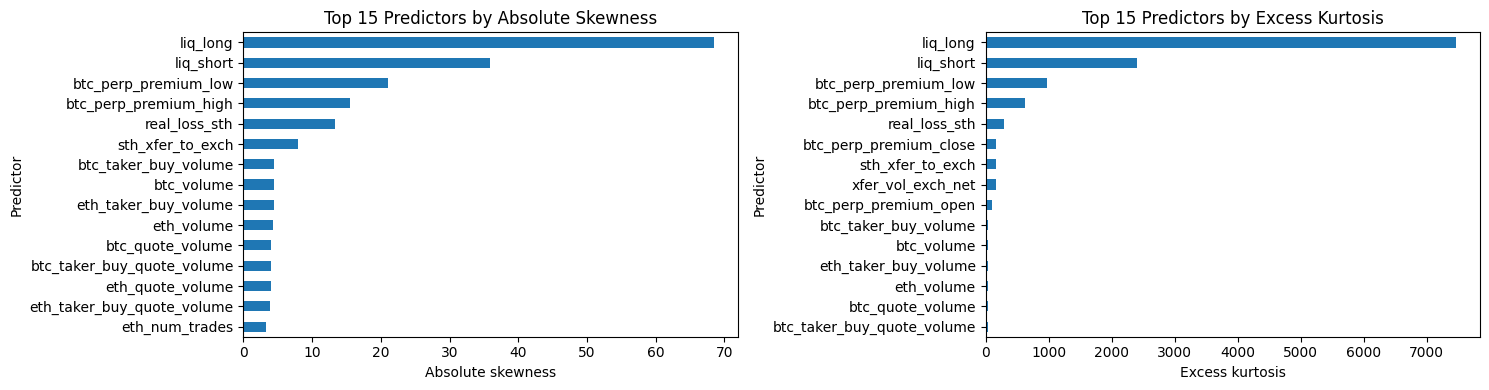

In [19]:
# Predictors with the most extreme skewness and kurtosis
n_show = 15
skew_plot = X_train_diag["skewness"].abs().nlargest(n_show).sort_values()
kurt_plot = X_train_diag["excess_kurtosis"].nlargest(n_show).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

skew_plot.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"Top {n_show} Predictors by Absolute Skewness")
axes[0].set_xlabel("Absolute skewness")
axes[0].set_ylabel("Predictor")

kurt_plot.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Top {n_show} Predictors by Excess Kurtosis")
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_ylabel("Predictor")

plt.tight_layout()
plt.show()

Liquidation variables are the most skewed, heavy-tailed and zero-inflated, while selected premium-index and on-chain variables also display pronounced tail behaviour. These series will be transformed nonlinearly or represented through event and intensity features during feature engineering.

**d) Zero-Inflated and Event-Driven Variables**

Zero-value concentration is examined because some predictors are inactive for long periods and only become non-zero during specific market events. In such cases, the occurrence of an event may carry different information from its magnitude, which may justify separate indicator and intensity features.

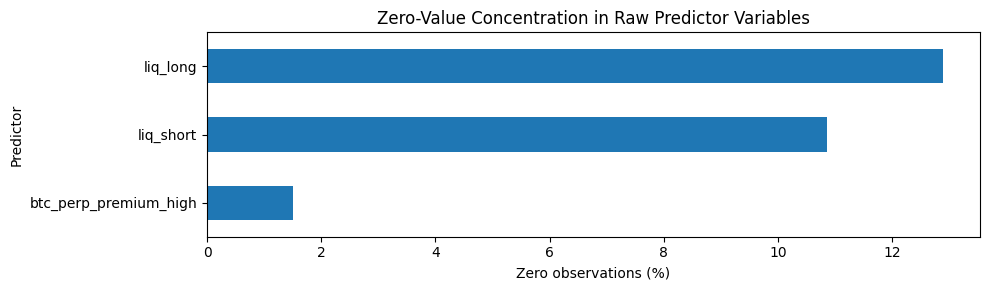

In [20]:
# Predictors with a material concentration of zero values
zero_threshold = 1.0
zero_plot = X_train_diag.loc[X_train_diag["zero_pct"] >= zero_threshold, "zero_pct"].sort_values()

if zero_plot.empty:
    print(f"No raw predictors have zero values in at least {zero_threshold:.0f}% of observed rows.")
else:
    plt.figure(figsize=(10, max(3, len(zero_plot) * 0.35)))
    zero_plot.plot(kind="barh")
    plt.title("Zero-Value Concentration in Raw Predictor Variables")
    plt.xlabel("Zero observations (%)")
    plt.ylabel("Predictor")
    plt.tight_layout()
    plt.show()

Liquidation variables are clearly zero-inflated and episodic, with non-zero observations concentrated around periods of market stress. Feature engineering should therefore consider both a binary liquidation-event indicator and a transformed measure of liquidation magnitude. The smaller zero concentration in the premium-index high is less material.

**e) Target Variable Analysis Across Candidate Horizons**

The prediction horizon is treated as part of the research problem. Forward log returns over 1, 4, 6, 8, 12 and 24 hours are compared on the training sample using distribution, tail behaviour and class balance. Final selection will also consider feature–target signal strength.

In [21]:
# Candidate target distributions and class balance
target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

target_data = targets_train[target_cols]
target_summary = target_data.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

target_summary["negative_count"] = target_data.le(0).sum()
target_summary["positive_count"] = target_data.gt(0).sum()
target_summary["positive_pct"] = target_data.gt(0).sum().div(target_data.notna().sum()).mul(100)
target_summary["negative_pct"] = target_data.le(0).sum().div(target_data.notna().sum()).mul(100)

target_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,negative_count,positive_count,positive_pct,negative_pct
fwd_logret_1h,"45,537.0000",0.0001,0.0070,-0.2071,-0.0207,-0.0095,-0.0024,0.0001,0.0026,0.0097,0.0200,0.1508,22351,23186,50.9168,49.0832
fwd_logret_4h,"45,537.0000",0.0002,0.0138,-0.3593,-0.0409,-0.0201,-0.0047,0.0002,0.0052,0.0205,0.0401,0.1867,22190,23347,51.2704,48.7296
fwd_logret_6h,"45,537.0000",0.0003,0.0167,-0.3956,-0.0490,-0.0247,-0.0058,0.0003,0.0067,0.0253,0.0479,0.2797,22143,23394,51.3736,48.6264
fwd_logret_8h,"45,537.0000",0.0004,0.0192,-0.4083,-0.0564,-0.0284,-0.0068,0.0004,0.0079,0.0296,0.0557,0.3178,22035,23502,51.6108,48.3892
fwd_logret_12h,"45,537.0000",0.0006,0.0234,-0.3880,-0.0687,-0.0350,-0.0087,0.0005,0.0102,0.0367,0.0672,0.3204,21972,23565,51.7491,48.2509
fwd_logret_24h,"45,537.0000",0.0013,0.0337,-0.6416,-0.0968,-0.0499,-0.0132,0.0011,0.0163,0.0533,0.0936,0.2993,21581,23956,52.6078,47.3922


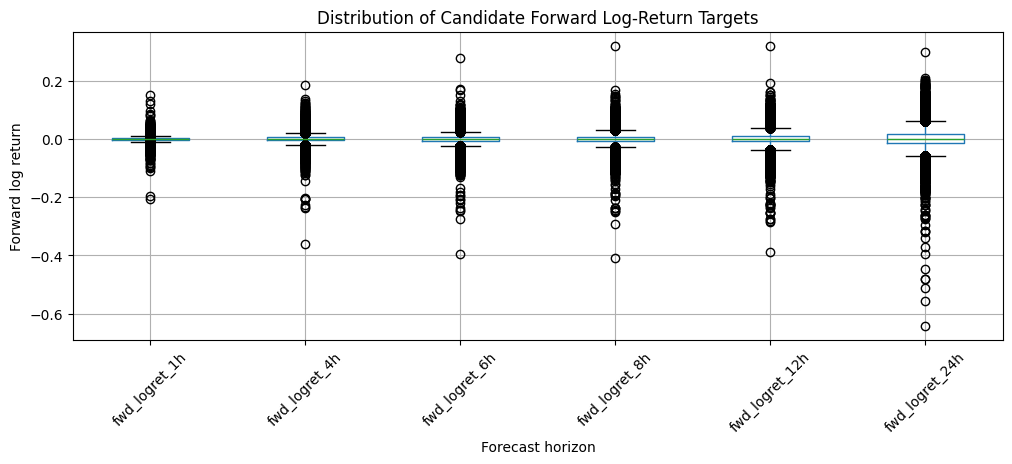

In [22]:
# Boxplots of candidate forward log-return targets
ax = target_data.boxplot(figsize=(12, 4), showfliers=True)

ax.set_title("Distribution of Candidate Forward Log-Return Targets")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forward log return")

plt.xticks(rotation=45)
plt.show()

Candidate returns remain centred near zero, while dispersion and tail magnitude increase with the horizon. Longer horizons capture larger cumulative moves, whereas shorter horizons are more concentrated around zero and potentially noisier. Distributional behaviour alone does not determine predictability, so final selection also considers feature–target signal strength and stability.

**f) Temporal Behaviour and Regime Variation**

Full-sample statistics may conceal changing market conditions. Selected time series are therefore examined for volatility clustering, episodic dislocations and relationships requiring rolling, standardised or regime-sensitive features.

i) BTC Rolling 24-Hour Log Return and Realised Volatility

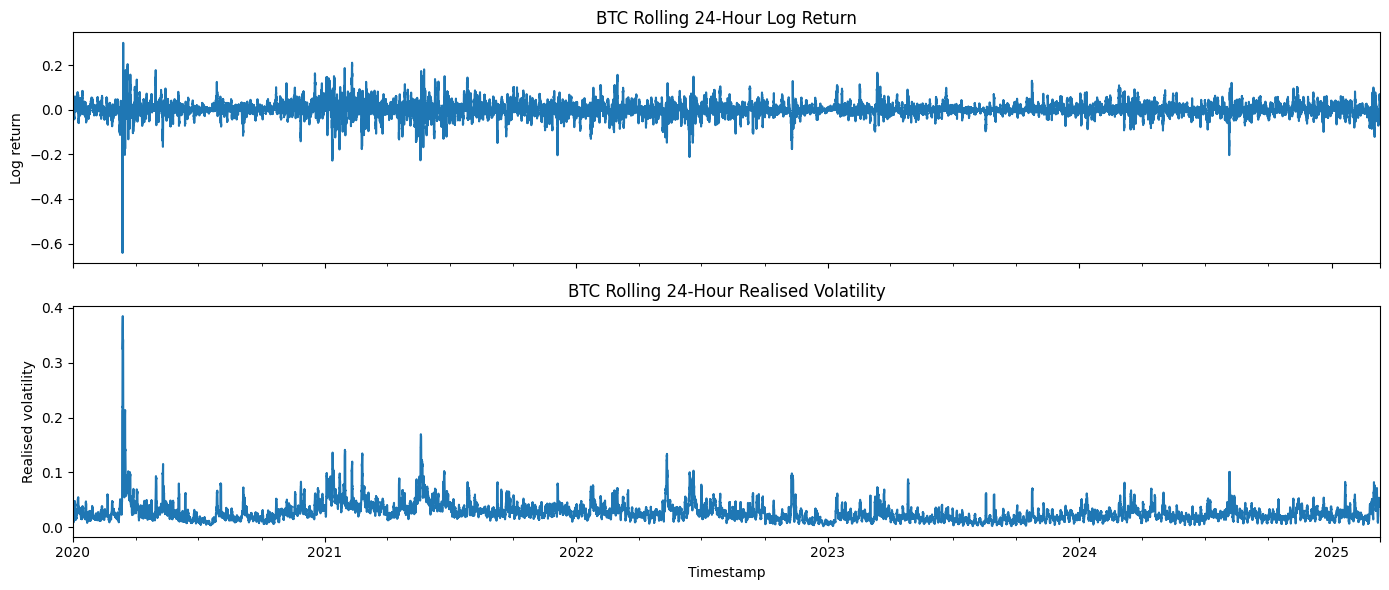

In [23]:
# BTC rolling 24-hour return and realised volatility
temporal_df = X_train.set_index("timestamp").copy()

temporal_df["btc_logret_1h"] = np.log(temporal_df["btc_close"] / temporal_df["btc_close"].shift(1))
temporal_df["btc_logret_24h"] = temporal_df["btc_logret_1h"].rolling(24).sum()
temporal_df["btc_realised_vol_24h"] = np.sqrt(temporal_df["btc_logret_1h"].pow(2).rolling(24).sum())
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

temporal_df["btc_logret_24h"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("BTC Rolling 24-Hour Log Return")
axes[0].set_ylabel("Log return")

temporal_df["btc_realised_vol_24h"].plot(ax=axes[1])
axes[1].set_title("BTC Rolling 24-Hour Realised Volatility")
axes[1].set_ylabel("Realised volatility")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The series show clear volatility clustering, with wider positive and negative return ranges during high-volatility periods. Realised volatility is therefore treated primarily as a market-state variable rather than a directional signal.

ii) BTC Perpetual Premium and Funding at 8-Hour Settlement Intervals

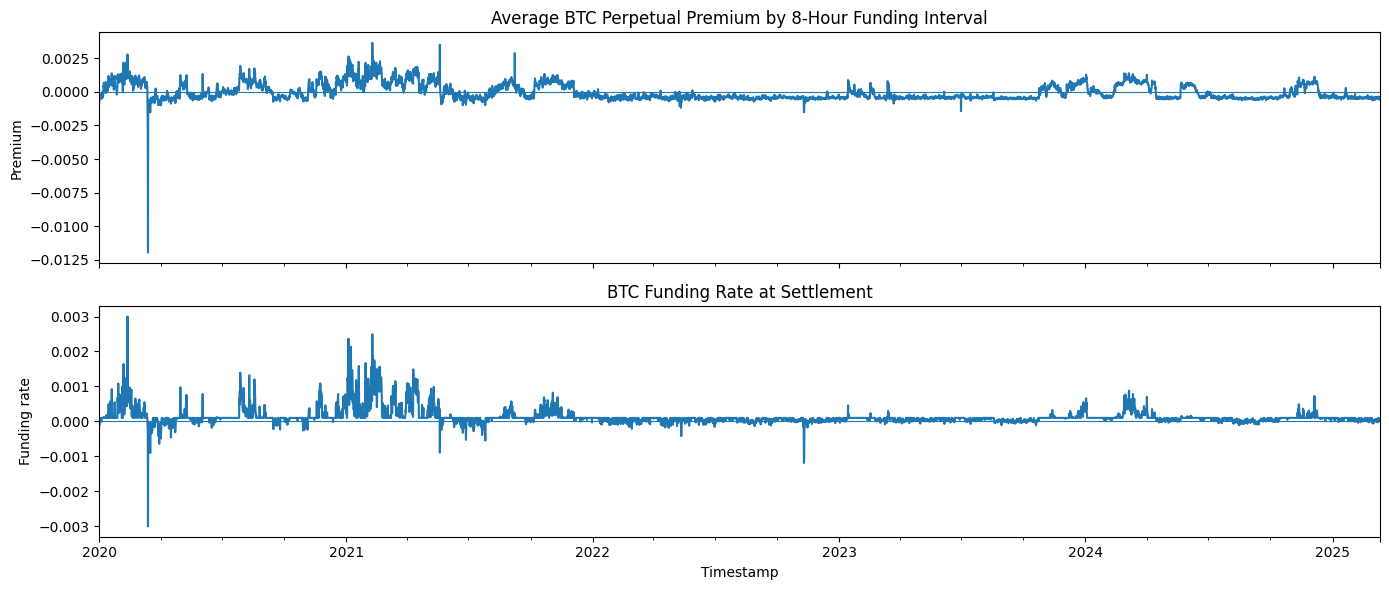

In [24]:
# BTC perpetual premium and funding at 8-hour settlement intervals
premium_funding_8h = temporal_df[["btc_perp_premium_close", "btc_funding"]].resample("8h", origin="start_day", closed="right", label="right").agg({
    "btc_perp_premium_close": "mean",
    "btc_funding": "last"})

premium_funding_8h = premium_funding_8h.dropna(subset=["btc_funding"])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

premium_funding_8h["btc_perp_premium_close"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Average BTC Perpetual Premium by 8-Hour Funding Interval")
axes[0].set_ylabel("Premium")

premium_funding_8h["btc_funding"].plot(ax=axes[1])
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("BTC Funding Rate at Settlement")
axes[1].set_ylabel("Funding rate")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

Premium and funding generally move together, with the largest joint movements occurring during crowded or stressed conditions. Their levels, changes and divergence are retained for feature engineering.

iii) Rolling Standardised Open Interest and Leverage Ratio

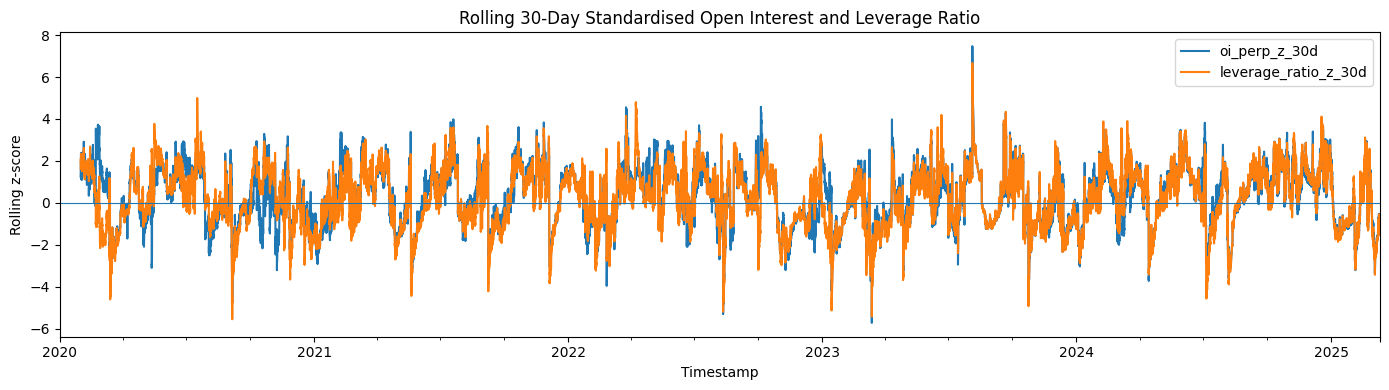

In [25]:
# Rolling 30-day standardisation of open interest and leverage ratio
rolling_window = 24 * 30

oi_mean = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).mean()
oi_std = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).std()

lev_mean = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).mean()
lev_std = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).std()

temporal_df["oi_perp_z_30d"] = (temporal_df["oi_perp"] - oi_mean) / oi_std.replace(0, np.nan)
temporal_df["leverage_ratio_z_30d"] = (temporal_df["leverage_ratio"] - lev_mean) / lev_std.replace(0, np.nan)

ax = temporal_df[["oi_perp_z_30d", "leverage_ratio_z_30d"]].plot(figsize=(14, 4))

ax.axhline(0, linewidth=0.8)
ax.set_title("Rolling 30-Day Standardised Open Interest and Leverage Ratio")
ax.set_ylabel("Rolling z-score")
ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

Open interest and leverage often move together, but temporary divergences show that participation growth does not always imply a proportional change in leverage intensity. Both are retained for separate feature construction and later redundancy testing.

Only selected raw levels are plotted; the remaining predictors are examined after transformation into changes, returns, logarithms, rolling standardisations or relative spreads.

### **Part II — Deribit Futures Panel EDA**

The Deribit panel contains multiple contracts with different expiries, and the active instrument set changes through time. Individual contract series cannot therefore be merged directly by instrument name.

The panel is analysed separately and later converted into fixed-dimensional, roll-aware and point-in-time features describing maturity, liquidity, basis and term structure.

a) **Contract Maturity and Roll Behaviour**

This subsection examines active-contract counts, time to expiry and front-contract rolls, treating the perpetual separately because it has no fixed maturity.

i) Load Deribit Data Panel

In [26]:
# Load Deribit training panel for EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"; os.chdir(data_dir)

deribit_train_panel = pd.read_csv("deribit_train_panel.csv", parse_dates=["timestamp", "expiration_timestamp"])
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True, errors="coerce")
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

deribit_train_panel["is_perpetual"] = deribit_train_panel["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit_train_panel["observation_timestamp"] = deribit_train_panel["timestamp"] - pd.Timedelta(hours=1)
deribit_train_panel["days_to_expiry"] = (deribit_train_panel["expiration_timestamp"] - deribit_train_panel["observation_timestamp"]).dt.total_seconds() / 86400

dated_mask = ~deribit_train_panel["is_perpetual"]

assert deribit_train_panel["timestamp"].notna().all()
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any()
assert deribit_train_panel.loc[dated_mask, "expiration_timestamp"].notna().all()
assert deribit_train_panel.loc[dated_mask, "days_to_expiry"].ge(0).all()

print("Deribit training shape:", deribit_train_panel.shape)
print("Training period:", deribit_train_panel["timestamp"].min(), "to", deribit_train_panel["timestamp"].max())
print("Instruments:", deribit_train_panel["instrument_name"].nunique())
print("Perpetual rows:", deribit_train_panel["is_perpetual"].sum())
print("Dated futures rows:", dated_mask.sum())
print("Minimum dated time to expiry:", deribit_train_panel.loc[dated_mask, "days_to_expiry"].min())

deribit_train_panel.head()

Deribit training shape: (214352, 16)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Instruments: 25
Perpetual rows: 45537
Dated futures rows: 168815
Minimum dated time to expiry: 0.0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp,is_perpetual,observation_timestamp,days_to_expiry
0,1577833200000,"7,440.5000","7,447.5000","7,426.5000","7,433.0000",9.9284,"73,830.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,177.3750
1,1577833200000,"7,292.0000","7,292.0000","7,274.0000","7,280.0000",26.5040,"193,000.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,86.3750
2,1577833200000,"7,178.5000","7,186.0000","7,164.0000","7,169.5000",301.1300,"2,161,100.0000",BTC-PERPETUAL,perpetual,perpetual,NaN,NaT,2020-01-01 00:00:00+00:00,True,2019-12-31 23:00:00+00:00,NaN
3,1577836800000,"7,433.0000","7,433.0000","7,414.0000","7,418.5000",9.6024,"71,270.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,177.3333
4,1577836800000,"7,277.0000","7,277.0000","7,265.5000","7,265.5000",17.7270,"128,870.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,86.3333


ii) Summarize active contracts and maturity coverage by timestamp

In [27]:
# Summarise active contracts and maturity coverage by timestamp
deribit_maturity_summary = deribit_train_panel.groupby("timestamp").agg(
    active_contracts=("instrument_name", "nunique"),
    active_perpetuals=("is_perpetual", "sum"),
    active_dated_futures=("is_perpetual", lambda x: (~x).sum()),
    min_days_to_expiry=("days_to_expiry", "min"),
    max_days_to_expiry=("days_to_expiry", "max"))

deribit_maturity_summary.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).round(2)

,active_contracts,active_perpetuals,active_dated_futures,min_days_to_expiry,max_days_to_expiry
count,"45,537.0000","45,537.0000","45,537.0000","45,537.0000","45,537.0000"
mean,4.7100,1.0000,3.7100,45.9000,292.9900
std,0.5600,0.0000,0.5600,26.2600,55.3400
min,3.0000,1.0000,2.0000,0.0000,116.0400
1%,3.0000,1.0000,2.0000,0.9200,135.0100
25%,5.0000,1.0000,4.0000,23.3300,273.5400
50%,5.0000,1.0000,4.0000,45.9200,304.9600
75%,5.0000,1.0000,4.0000,68.5000,334.5800
99%,5.0000,1.0000,4.0000,90.7100,366.2800
max,6.0000,1.0000,5.0000,97.9600,371.0000


A typical timestamp contains one perpetual contract and four dated futures. The nearest dated contract has a median time to expiry of approximately 46 days, while the longest available maturity is typically around 305 days. The panel therefore covers the front of the futures curve to roughly one year and supports the construction of roll-aware term-structure features.

iii) Identify the Front Dated Future and Contract Roll Dates

In [28]:
# Identify the front dated future and contract roll dates
deribit_dated = deribit_train_panel.loc[~deribit_train_panel["is_perpetual"]].copy()
deribit_dated = deribit_dated.sort_values(["timestamp", "days_to_expiry", "instrument_name"])

deribit_front = deribit_dated.groupby("timestamp", as_index=False).first()
deribit_front = deribit_front[["timestamp", "instrument_name", "days_to_expiry", "close", "volume", "cost"]]

deribit_front["previous_instrument"] = deribit_front["instrument_name"].shift()
deribit_front["is_roll"] = deribit_front["instrument_name"].ne(deribit_front["previous_instrument"])
deribit_front.loc[deribit_front.index[0], "is_roll"] = False

deribit_rolls = deribit_front.loc[
    deribit_front["is_roll"],
    ["timestamp", "previous_instrument", "instrument_name", "days_to_expiry"]].reset_index(drop=True)

roll_spacing_days = deribit_rolls["timestamp"].diff().dt.total_seconds().div(86400)

print("Front-contract observations:", len(deribit_front))
print("Front-contract changes:", len(deribit_rolls))
print("Median days between rolls:", roll_spacing_days.median())

deribit_rolls

Front-contract observations: 45537
Front-contract changes: 20
Median days between rolls: 91.0


,timestamp,previous_instrument,instrument_name,days_to_expiry
0,2020-03-27 10:00:00+00:00,BTC-27MAR20,BTC-26JUN20,90.9583
1,2020-06-26 10:00:00+00:00,BTC-26JUN20,BTC-25SEP20,90.9583
2,2020-09-25 10:00:00+00:00,BTC-25SEP20,BTC-25DEC20,90.9583
3,2020-12-25 10:00:00+00:00,BTC-25DEC20,BTC-26MAR21,90.9583
4,2021-03-26 10:00:00+00:00,BTC-26MAR21,BTC-25JUN21,90.9583
5,2021-06-25 10:00:00+00:00,BTC-25JUN21,BTC-24SEP21,90.9583
6,2021-09-24 10:00:00+00:00,BTC-24SEP21,BTC-31DEC21,97.9583
7,2021-12-31 10:00:00+00:00,BTC-31DEC21,BTC-25MAR22,83.9583
8,2022-03-25 10:00:00+00:00,BTC-25MAR22,BTC-24JUN22,90.9583
9,2022-06-24 10:00:00+00:00,BTC-24JUN22,BTC-30SEP22,97.9583


The changing front contract confirms that a continuous front-futures series must be constructed explicitly rather than linked by fixed instrument name.

**b) Liquidity and Data Reliability**

Trading activity is examined across perpetual and dated futures to assess inactive observations, contract-type differences and liquidity decay with maturity.

i) Compares structural liquidity characteristics for perpetual and dated futures

In [29]:
# Summarise trading activity and inactive observations
deribit_train_panel["contract_type"] = np.where(deribit_train_panel["is_perpetual"], "Perpetual", "Dated futures")
deribit_train_panel["zero_volume"] = deribit_train_panel["volume"].eq(0)
deribit_train_panel["zero_cost"] = deribit_train_panel["cost"].eq(0)
deribit_train_panel["negative_volume"] = deribit_train_panel["volume"].lt(0)
deribit_train_panel["negative_cost"] = deribit_train_panel["cost"].lt(0)
deribit_train_panel["flat_candle"] = deribit_train_panel[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_liquidity_summary = deribit_train_panel.groupby("contract_type").agg(
    observations=("instrument_name", "size"),
    instruments=("instrument_name", "nunique"),
    missing_volume=("volume", lambda x: x.isna().sum()),
    missing_cost=("cost", lambda x: x.isna().sum()),
    negative_volume=("negative_volume", "sum"),
    negative_cost=("negative_cost", "sum"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_liquidity_summary[pct_cols] = deribit_liquidity_summary[pct_cols].mul(100)

deribit_liquidity_summary.round(2)

,observations,instruments,missing_volume,missing_cost,negative_volume,negative_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct,median_volume,median_cost,mean_cost
contract_type,,,,,,,,,,,,
Dated futures,168815,24,0,0,0,0,3.6800,3.6800,6.3400,4.8800,"180,940.0000","803,456.0500"
Perpetual,45537,1,0,0,0,0,0.0100,0.0100,0.0200,370.0700,"11,787,750.0000","21,431,112.8100"


There are no missing or negative volume and cost observations. The perpetual contract is highly active, with few zero-activity or flat-candle observations. Dated futures are less liquid but remain usable for term-structure analysis, subject to liquidity screening or weighting during feature construction.

ii) Compare dated-futures liquidity across maturity buckets

In [30]:
# Compare dated-futures liquidity across maturity buckets
maturity_bins = [0, 30, 90, 180, np.inf]
maturity_labels = ["0–30 days", "31–90 days", "91–180 days", "181+ days"]

deribit_dated["maturity_bucket"] = pd.cut(
    deribit_dated["days_to_expiry"],
    bins=maturity_bins,
    labels=maturity_labels,
    include_lowest=True)

deribit_dated["zero_volume"] = deribit_dated["volume"].eq(0)
deribit_dated["zero_cost"] = deribit_dated["cost"].eq(0)
deribit_dated["flat_candle"] = deribit_dated[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_maturity_liquidity = deribit_dated.groupby("maturity_bucket", observed=True).agg(
    observations=("instrument_name", "size"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_maturity_liquidity[pct_cols] = deribit_maturity_liquidity[pct_cols].mul(100)

deribit_maturity_liquidity.round(2)

,observations,median_volume,median_cost,mean_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct
maturity_bucket,,,,,,,
0–30 days,14756,30.8100,"977,285.0000","2,159,923.8200",0.2000,0.2000,0.2400
31–90 days,30153,21.1600,"683,780.0000","1,664,919.4800",0.1000,0.1000,0.2500
91–180 days,44889,8.5400,"287,240.0000","765,148.8900",0.5100,0.5100,1.1900
181+ days,79017,1.0600,"41,730.0000","243,169.3500",7.4900,7.4900,12.7400


Liquidity declines with maturity, particularly beyond 180 days. Far-dated contracts should therefore be excluded, down-weighted or used only within liquidity-aware term-structure features.

**c) Futures Basis and Term-Structure Behaviour**

Dated-futures prices are compared with BTC spot to calculate percentage basis. The nearest two contracts are then used to examine the slope and shape of the front futures curve.

i) Construct the Front Futures Curve Slope

In [31]:
# Rebuild dated-futures basis and construct the front futures curve slope
btc_spot = X_train[["timestamp", "btc_close"]].copy()
btc_spot["timestamp"] = pd.to_datetime(btc_spot["timestamp"], utc=True)
btc_spot = btc_spot.rename(columns={"timestamp": "observation_timestamp"})

deribit_basis = deribit_dated.merge(btc_spot, on="observation_timestamp", how="left", validate="many_to_one")
deribit_basis = deribit_basis.dropna(subset=["btc_close"]).copy()
deribit_basis["basis_pct"] = 100 * (deribit_basis["close"] / deribit_basis["btc_close"] - 1)

curve_cols = ["timestamp", "instrument_name", "days_to_expiry", "basis_pct"]
curve_ranked = deribit_basis[curve_cols].sort_values(["timestamp", "days_to_expiry", "instrument_name"]).copy()
curve_ranked["maturity_rank"] = curve_ranked.groupby("timestamp").cumcount() + 1
curve_ranked = curve_ranked.loc[curve_ranked["maturity_rank"].le(2)].copy()

front_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(1), curve_cols].copy()
second_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(2), curve_cols].copy()

front_contract = front_contract.rename(columns={"instrument_name": "front_instrument", "days_to_expiry": "front_days", "basis_pct": "front_basis_pct"})
second_contract = second_contract.rename(columns={"instrument_name": "second_instrument", "days_to_expiry": "second_days", "basis_pct": "second_basis_pct"})

front_curve = front_contract.merge(second_contract, on="timestamp", how="inner", validate="one_to_one")
front_curve["curve_slope_pct"] = front_curve["second_basis_pct"] - front_curve["front_basis_pct"]
front_curve["curve_state"] = np.where(front_curve["curve_slope_pct"].ge(0), "Upward sloping", "Inverted")

front_curve_summary = pd.Series({
    "observations": len(front_curve),
    "median_front_basis_pct": front_curve["front_basis_pct"].median(),
    "median_second_basis_pct": front_curve["second_basis_pct"].median(),
    "median_curve_slope_pct": front_curve["curve_slope_pct"].median(),
    "upward_sloping_pct": 100 * front_curve["curve_state"].eq("Upward sloping").mean(),
    "inverted_pct": 100 * front_curve["curve_state"].eq("Inverted").mean()})

front_curve_summary.to_frame("value").T.round(2)

,observations,median_front_basis_pct,median_second_basis_pct,median_curve_slope_pct,upward_sloping_pct,inverted_pct
value,"45,536.0000",0.7700,2.7900,1.8500,96.3800,3.6200


The front futures curve is upward sloping in 96.4% of observations and inverted in only 3.6%. Curve inversion is therefore an uncommon condition and is retained as a candidate stress indicator.

**d) Implications for Deribit Feature Engineering**

Deribit contracts will be converted into fixed, roll-aware and point-in-time features rather than used by instrument name. Construction will prioritise the perpetual and nearer-dated contracts, while far-dated observations are excluded or liquidity-weighted. Candidate measures include front basis, curve slope and inversion, slope changes, days to expiry and trading activity.

**Part III — Insights from the EDA Process**

The EDA identified substantial differences in scale, tail behaviour, sparsity and temporal stability across the raw predictors. Feature engineering will therefore use returns, changes, rolling standardisation, relative spreads, nonlinear transformations and event indicators, while the Deribit panel will be converted separately into fixed roll-aware features.

## **(V) Feature Engineering & Prediction Horizon Selection**

### **Part I — Feature Engineering**

Feature engineering converts the cleaned source series into economically interpretable predictors using the findings from the EDA. Raw levels are transformed where appropriate into returns, changes, slopes, rolling standardisations, relative spreads and event indicators so that direction, magnitude, velocity and changing market conditions are represented more clearly.

The features are designed to capture BTC trend and volatility, derivatives positioning, cross-exchange conditions, futures term structure, on-chain behaviour and broader financial-market conditions. Deribit contracts are converted separately into fixed, roll-aware features before being aligned with the hourly modelling matrix.

All features are constructed using current and historical information only. The complete candidate matrix is then audited before the six forward-return horizons are compared using training data.

In [58]:
# Load training inputs for feature engineering
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train = pd.read_csv(DATA_PATH / "X_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
targets_train = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
deribit_train_panel = pd.read_csv(DATA_PATH / "deribit_train_panel.csv")

X_train.index = pd.to_datetime(X_train.index, utc=True)
targets_train.index = pd.to_datetime(targets_train.index, utc=True)

deribit_train_panel = deribit_train_panel.drop(columns=deribit_train_panel.filter(regex=r"^Unnamed:").columns)
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True)
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

X_train_engineered = pd.DataFrame(index=X_train.index)

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

print(f"Training data: {X_train.shape} | {X_train.index.min()} to {X_train.index.max()}")
print(f"Targets: {targets_train.shape} | {len(target_cols)} candidate horizons")
print(f"Deribit panel: {deribit_train_panel.shape} | {deribit_train_panel['instrument_name'].nunique()} instruments")
print(f"Initial engineered matrix: {X_train_engineered.shape}")

Training data: (45537, 48) | 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Targets: (45537, 7) | 6 candidate horizons
Deribit panel: (214352, 13) | 25 instruments
Initial engineered matrix: (45537, 0)


### **a) BTC Price, Trend and Momentum**

Trend and momentum are measured using log returns, rolling log-price slopes and changes in trend speed across 4, 8 and 24-hour windows. Trend-quality statistics are calculated only over 8 and 24 hours, while acceleration compares consecutive non-overlapping return periods.

In [59]:
# a) BTC Price, Trend and Momentum

btc_close = pd.to_numeric(X_train["btc_close"], errors="coerce")
btc_log_price = np.log(btc_close)
btc_trend_features = pd.DataFrame(index=X_train.index)

# Log returns
btc_trend_features["btc_ret_1h"] = btc_log_price.diff(1)
btc_trend_features["btc_ret_4h"] = btc_log_price.diff(4)
btc_trend_features["btc_ret_24h"] = btc_log_price.diff(24)

# Rolling log-price regression
def rolling_logprice_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)
    sum_y = log_price.rolling(window).sum()
    sum_y2 = log_price.pow(2).rolling(window).sum()
    sum_xy = log_price.rolling(window).apply(lambda y: np.dot(y, x), raw=True)
    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt((residual_ss / (window - 2)) / sxx)
    slope_tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)
    return slope, slope_tstat, r2

slope_4h, _, _ = rolling_logprice_regression(btc_log_price, 4)
slope_8h, slope_tstat_8h, trend_r2_8h = rolling_logprice_regression(btc_log_price, 8)
slope_24h, slope_tstat_24h, trend_r2_24h = rolling_logprice_regression(btc_log_price, 24)

# Trend direction and quality
btc_trend_features["btc_logprice_slope_4h"] = slope_4h
btc_trend_features["btc_logprice_slope_8h"] = slope_8h
btc_trend_features["btc_logprice_slope_24h"] = slope_24h
btc_trend_features["btc_slope_tstat_8h"] = slope_tstat_8h
btc_trend_features["btc_slope_tstat_24h"] = slope_tstat_24h
btc_trend_features["btc_trend_r2_8h"] = trend_r2_8h
btc_trend_features["btc_trend_r2_24h"] = trend_r2_24h

# Fast-versus-slow trend
btc_trend_features["btc_slope_spread_4h_24h"] = slope_4h - slope_24h
btc_trend_features["btc_slope_spread_8h_24h"] = slope_8h - slope_24h

# Return acceleration
btc_ret_8h = btc_log_price.diff(8)
btc_trend_features["btc_return_acceleration_4h"] = btc_trend_features["btc_ret_4h"] - btc_trend_features["btc_ret_4h"].shift(4)
btc_trend_features["btc_return_acceleration_8h"] = btc_ret_8h - btc_ret_8h.shift(8)

btc_trend_features = btc_trend_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(btc_trend_features)

print(f"Features added: {btc_trend_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_trend_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": btc_trend_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_trend_features.isna().sum()}))

Features added: 14
Engineered matrix: (45537, 14)
Longest warm-up: 24 rows


,first_valid,warmup_rows
btc_ret_1h,2020-01-01 01:00:00+00:00,1
btc_ret_4h,2020-01-01 04:00:00+00:00,4
btc_ret_24h,2020-01-02 00:00:00+00:00,24
btc_logprice_slope_4h,2020-01-01 03:00:00+00:00,3
btc_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
btc_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_slope_tstat_8h,2020-01-01 07:00:00+00:00,7
btc_slope_tstat_24h,2020-01-01 23:00:00+00:00,23
btc_trend_r2_8h,2020-01-01 07:00:00+00:00,7
btc_trend_r2_24h,2020-01-01 23:00:00+00:00,23


### **b) BTC Volatility, Asymmetry and Regimes**

These features are designed to describe the magnitude, direction and persistence of BTC risk rather than price direction alone. Realised volatility measures recent return variation, downside-variance shares distinguish negative from total volatility, and drawdown features capture the depth of recent price weakness.

Bitcoin volatility has been studied using both conventional forecasting frameworks and hybrid GARCH–machine-learning specifications, motivating the inclusion of realised, conditional and regime-dependent volatility measures in the candidate feature set (Bergsli et al., 2022; Zahid, Iqbal and Koutmos, 2022).

For hourly log returns ${r_t}$, realised volatility over a rolling window of $w$ observations is represented by

$$
RV_{t,w}
=
\sqrt{\sum_{i=0}^{w-1} r_{t-i}^{\,2}}.
$$

The corresponding downside-variance share measures the proportion of recent variation generated by negative returns:

$$
DVS_{t,w}
=
\frac{
\sum_{i=0}^{w-1} r_{t-i}^{\,2}\mathbf{1}(r_{t-i}<0)
}{
\sum_{i=0}^{w-1} r_{t-i}^{\,2}
}.
$$

Volatility-of-volatility measures how unstable the realised-volatility process itself has become. It is constructed as the rolling dispersion of realised volatility:

$$
VoV_{t,w}
=
\operatorname{Std}
\left(
RV_{t-w+1},\ldots,RV_t
\right).
$$

A high value therefore indicates that the market is not merely volatile, but that the level of volatility is changing rapidly through time.

The Hurst exponent is included as a rolling measure of persistence. It is based on the scaling relationship

$$
\mathbb{E}\left[|X_{t+\tau}-X_t|\right]
\propto
\tau^H.
$$

Values of \(H>0.5\) are associated with persistent behaviour, values of \(H<0.5\) with anti-persistence or mean reversion, and values near \(0.5\) with behaviour closer to an uncorrelated random process. In this project, the Hurst estimate is treated as a local regime descriptor rather than as evidence that BTC follows a fixed long-memory process.

Conditional volatility is also estimated using an EGARCH model, which allows volatility to respond asymmetrically to positive and negative shocks:

$$
\log \sigma_t^2
=
\omega
+
\beta \log \sigma_{t-1}^2
+
\alpha
\left(
|z_{t-1}|-\mathbb{E}|z_{t-1}|
\right)
+
\gamma z_{t-1},
$$

where the standardised shock is defined as

$$
z_{t-1}
=
\frac{\varepsilon_{t-1}}{\sigma_{t-1}}.
$$

The logarithmic specification ensures that the conditional variance remains positive, while the parameter $\gamma$ captures asymmetric responses to positive and negative shocks.

Together, volatility-of-volatility, the Hurst exponent and the EGARCH regime measure are intended to identify changing market conditions: unstable volatility, persistent or mean-reverting price behaviour and periods of unusually high or low conditional risk. These variables are used as state descriptors and interaction inputs rather than as standalone trading signals.

In [60]:
# b) BTC Volatility, Asymmetry and Regimes

btc_volatility_features = pd.DataFrame(index=X_train.index)

btc_ret_1h = btc_trend_features["btc_ret_1h"]
btc_squared_return = btc_ret_1h.pow(2)
btc_downside_squared_return = btc_ret_1h.clip(upper=0).pow(2)

# Realised volatility
for window in [4, 8, 24]:
    rolling_variance = btc_squared_return.rolling(window).sum()
    btc_volatility_features[f"btc_rv_{window}h"] = np.sqrt(rolling_variance)

# Downside variance share
for window in [8, 24]:
    downside_variance = btc_downside_squared_return.rolling(window).sum()
    total_variance = btc_squared_return.rolling(window).sum().replace(0, np.nan)
    btc_volatility_features[f"btc_downside_variance_share_{window}h"] = (downside_variance / total_variance).clip(0, 1)

# Volatility instability and drawdown
btc_volatility_features["btc_vol_of_vol_24h"] = btc_volatility_features["btc_rv_4h"].rolling(24).std()
btc_volatility_features["btc_drawdown_8h"] = btc_close / btc_close.rolling(8).max() - 1
btc_volatility_features["btc_drawdown_24h"] = btc_close / btc_close.rolling(24).max() - 1

drawdown_8h_limit = btc_volatility_features["btc_drawdown_8h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_24h_limit = btc_volatility_features["btc_drawdown_24h"].rolling(720, min_periods=168).quantile(0.05).shift(1)

drawdown_ready = drawdown_8h_limit.notna() & drawdown_24h_limit.notna()
drawdown_extreme = (btc_volatility_features["btc_drawdown_8h"] < drawdown_8h_limit) | (btc_volatility_features["btc_drawdown_24h"] < drawdown_24h_limit)

btc_volatility_features["btc_drawdown_extreme_flag"] = drawdown_extreme.astype(float).where(drawdown_ready)

# Rolling Hurst exponent
hurst_window = 168
hurst_update_frequency = 24
hurst_scales = np.array([1, 2, 4, 8, 12, 24])

def estimate_hurst(return_window):
    scale_values = []
    variance_values = []

    for scale in hurst_scales:
        usable_length = len(return_window) // scale * scale
        aggregated_returns = return_window[-usable_length:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated_returns, ddof=1)

        if np.isfinite(variance) and variance > 0:
            scale_values.append(np.log(scale))
            variance_values.append(np.log(variance))

    return np.polyfit(scale_values, variance_values, 1)[0] / 2 if len(scale_values) >= 3 else np.nan

btc_hurst = pd.Series(np.nan, index=X_train.index)

for position in range(hurst_window, len(X_train), hurst_update_frequency):
    return_window = btc_ret_1h.iloc[position - hurst_window + 1:position + 1]

    if return_window.notna().all():
        btc_hurst.iloc[position] = estimate_hurst(return_window.to_numpy())

btc_volatility_features["btc_hurst_168h"] = btc_hurst.ffill()

# Causal EGARCH volatility
egarch_window = 4320
egarch_refit_frequency = 24
egarch_returns = btc_ret_1h * 100
egarch_conditional_vol = pd.Series(np.nan, index=X_train.index)

for position in range(egarch_window, len(X_train), egarch_refit_frequency):
    estimation_start = position - egarch_window + 1
    segment_end = min(position + egarch_refit_frequency, len(X_train))

    estimation_sample = egarch_returns.iloc[estimation_start:position + 1].dropna()
    filtering_sample = egarch_returns.iloc[estimation_start:segment_end].dropna()

    if len(estimation_sample) != egarch_window:
        continue

    model = arch_model(estimation_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    fitted_model = model.fit(disp="off", show_warning=False)

    filtering_model = arch_model(filtering_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    filtered_model = filtering_model.fix(fitted_model.params)

    segment_index = X_train.index[position:segment_end]
    egarch_conditional_vol.loc[segment_index] = filtered_model.conditional_volatility.reindex(segment_index) / 100

egarch_mean = egarch_conditional_vol.rolling(720).mean().shift(1)
egarch_std = egarch_conditional_vol.rolling(720).std().shift(1)

btc_volatility_features["btc_egarch_conditional_vol"] = egarch_conditional_vol
btc_volatility_features["btc_egarch_vol_regime"] = (egarch_conditional_vol - egarch_mean) / egarch_std.replace(0, np.nan)

btc_volatility_features = btc_volatility_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(btc_volatility_features)

print(f"Features added: {btc_volatility_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_volatility_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": btc_volatility_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_volatility_features.isna().sum()}))

Features added: 12
Engineered matrix: (45537, 26)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_rv_4h,2020-01-01 04:00:00+00:00,4
btc_rv_8h,2020-01-01 08:00:00+00:00,8
btc_rv_24h,2020-01-02 00:00:00+00:00,24
btc_downside_variance_share_8h,2020-01-01 08:00:00+00:00,8
btc_downside_variance_share_24h,2020-01-02 00:00:00+00:00,24
btc_vol_of_vol_24h,2020-01-02 03:00:00+00:00,27
btc_drawdown_8h,2020-01-01 07:00:00+00:00,7
btc_drawdown_24h,2020-01-01 23:00:00+00:00,23
btc_drawdown_extreme_flag,2020-01-08 23:00:00+00:00,191
btc_hurst_168h,2020-01-08 00:00:00+00:00,168


### **c) Premium, Funding and CEX Microstructure**

These features are created to capture short-horizon conditions in the perpetual-futures and spot markets. Premium and funding describe the cost and direction of leveraged positioning, while their changes, standardised levels and divergence may indicate crowded or stressed conditions.

Binance volume and taker flow measure trading intensity and buying pressure, while the Coinbase–Binance price spread captures temporary cross-exchange dislocations.

In [61]:
# c) Premium, Funding and CEX Microstructure
cex_microstructure_features = pd.DataFrame(index=X_train.index)

premium = pd.to_numeric(X_train["btc_perp_premium_close"], errors="coerce")
funding = pd.to_numeric(X_train["btc_funding"], errors="coerce").ffill()
btc_volume = pd.to_numeric(X_train["btc_volume"], errors="coerce")
btc_taker_buy_volume = pd.to_numeric(X_train["btc_taker_buy_volume"], errors="coerce")
coinbase_close = pd.to_numeric(X_train["coinbase_btc_close"], errors="coerce")

# Premium
premium_mean = premium.rolling(168).mean()
premium_std = premium.rolling(168).std()
premium_zscore = (premium - premium_mean) / premium_std.replace(0, np.nan)

cex_microstructure_features["premium_level"] = premium
cex_microstructure_features["premium_change_4h"] = premium.diff(4)
cex_microstructure_features["premium_zscore_168h"] = premium_zscore

# Funding
funding_mean = funding.rolling(168).mean()
funding_std = funding.rolling(168).std()
funding_zscore = (funding - funding_mean) / funding_std.where(funding_std > 0)
funding_zscore = funding_zscore.mask(funding_std.eq(0), 0)

cex_microstructure_features["funding_rate"] = funding
cex_microstructure_features["funding_change_8h"] = funding.diff(8)
cex_microstructure_features["funding_zscore_168h"] = funding_zscore
cex_microstructure_features["hours_since_funding"] = X_train.index.hour % 8

# Premium-funding dislocation
premium_funding_divergence = premium_zscore - funding_zscore
premium_funding_disagreement = (premium * funding < 0).astype(float).where(premium.notna() & funding.notna())

cex_microstructure_features["premium_funding_divergence"] = premium_funding_divergence
cex_microstructure_features["premium_funding_abs_divergence"] = premium_funding_divergence.abs()
cex_microstructure_features["premium_funding_disagreement"] = premium_funding_disagreement

divergence_limit = premium_funding_divergence.abs().rolling(720, min_periods=168).quantile(0.95).shift(1)
cex_microstructure_features["premium_funding_extreme_flag"] = (premium_funding_divergence.abs() > divergence_limit).astype(float).where(divergence_limit.notna())

# Binance volume and taker flow
btc_log_volume = np.log1p(btc_volume.clip(lower=0))
btc_taker_buy_share = (btc_taker_buy_volume / btc_volume.replace(0, np.nan)).fillna(0.5).clip(0, 1)

cex_microstructure_features["binance_volume_log_change_4h"] = btc_log_volume.diff(4)
cex_microstructure_features["binance_taker_buy_share"] = btc_taker_buy_share
cex_microstructure_features["binance_taker_buy_share_change_4h"] = btc_taker_buy_share.diff(4)

# Coinbase-Binance price spread
coinbase_binance_spread = coinbase_close / btc_close - 1
spread_mean = coinbase_binance_spread.rolling(168).mean()
spread_std = coinbase_binance_spread.rolling(168).std()
spread_zscore = (coinbase_binance_spread - spread_mean) / spread_std.replace(0, np.nan)

cex_microstructure_features["coinbase_binance_price_spread"] = coinbase_binance_spread
cex_microstructure_features["coinbase_binance_spread_zscore_168h"] = spread_zscore

cex_microstructure_features = cex_microstructure_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(cex_microstructure_features)

print(f"Features added: {cex_microstructure_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {cex_microstructure_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": cex_microstructure_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": cex_microstructure_features.isna().sum()}))

Features added: 16
Engineered matrix: (45537, 42)
Longest warm-up: 335 rows


,first_valid,warmup_rows
premium_level,2020-01-01 00:00:00+00:00,0
premium_change_4h,2020-01-01 04:00:00+00:00,4
premium_zscore_168h,2020-01-07 23:00:00+00:00,167
funding_rate,2020-01-01 00:00:00+00:00,0
funding_change_8h,2020-01-01 08:00:00+00:00,8
funding_zscore_168h,2020-01-07 23:00:00+00:00,167
hours_since_funding,2020-01-01 00:00:00+00:00,0
premium_funding_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_abs_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_disagreement,2020-01-01 00:00:00+00:00,0


### **d) ETH and Cross-Crypto Features**


ETH is included as a cross-crypto market reference because its price behaviour often reflects broader digital-asset conditions beyond BTC alone. The features capture ETH trend over 8 and 24-hour windows and compare short-term BTC and ETH slopes to identify relative strength or divergence between the two assets.

In [62]:
# d) ETH and Cross-Crypto Features
eth_close = pd.to_numeric(X_train["eth_close"], errors="coerce")
eth_log_price = np.log(eth_close)

eth_features = pd.DataFrame(index=X_train.index)

eth_slope_8h, _, _ = rolling_logprice_regression(eth_log_price, 8)
eth_slope_24h, _, _ = rolling_logprice_regression(eth_log_price, 24)

eth_features["eth_logprice_slope_8h"] = eth_slope_8h
eth_features["eth_logprice_slope_24h"] = eth_slope_24h
eth_features["btc_eth_slope_spread_8h"] = btc_trend_features["btc_logprice_slope_8h"] - eth_slope_8h

eth_features = eth_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(eth_features)

print(f"Features added: {eth_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {eth_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": eth_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": eth_features.isna().sum()}))

Features added: 3
Engineered matrix: (45537, 45)
Longest warm-up: 23 rows


,first_valid,warmup_rows
eth_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
eth_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_eth_slope_spread_8h,2020-01-01 07:00:00+00:00,7


### **e) Open Interest, Leverage and Liquidations**

These features are created to capture changes in derivatives positioning and market stress. Open interest measures the amount of outstanding futures exposure, while the leverage ratio indicates how aggressively that exposure is funded.

Rates of change, slopes and rolling z-scores are used to distinguish normal positioning from unusually crowded conditions. Long and short liquidations are transformed separately to capture episodic deleveraging pressure on each side of the market.

In [63]:
# e) Open Interest, Leverage and Liquidations
positioning_features = pd.DataFrame(index=X_train.index)

open_interest = pd.to_numeric(X_train["oi_perp"], errors="coerce")
leverage_ratio = pd.to_numeric(X_train["leverage_ratio"], errors="coerce")
long_liquidations = pd.to_numeric(X_train["liq_long"], errors="coerce")
short_liquidations = pd.to_numeric(X_train["liq_short"], errors="coerce")

open_interest_log = np.log(open_interest.where(open_interest > 0))
leverage_log = np.log(leverage_ratio.where(leverage_ratio > 0))

# Open interest
oi_mean = open_interest_log.rolling(168).mean()
oi_std = open_interest_log.rolling(168).std()
oi_zscore = (open_interest_log - oi_mean) / oi_std.replace(0, np.nan)
oi_slope_8h, _, _ = rolling_logprice_regression(open_interest_log, 8)

positioning_features["oi_log_roc_4h"] = open_interest_log.diff(4)
positioning_features["oi_log_roc_24h"] = open_interest_log.diff(24)
positioning_features["oi_slope_8h"] = oi_slope_8h
positioning_features["oi_zscore_168h"] = oi_zscore

# Leverage
leverage_mean = leverage_log.rolling(168).mean()
leverage_std = leverage_log.rolling(168).std()
leverage_zscore = (leverage_log - leverage_mean) / leverage_std.replace(0, np.nan)
leverage_slope_8h, _, _ = rolling_logprice_regression(leverage_log, 8)

positioning_features["leverage_log_roc_4h"] = leverage_log.diff(4)
positioning_features["leverage_log_roc_24h"] = leverage_log.diff(24)
positioning_features["leverage_slope_8h"] = leverage_slope_8h
positioning_features["leverage_zscore_168h"] = leverage_zscore

# Positioning divergence
positioning_features["oi_leverage_divergence"] = oi_zscore - leverage_zscore

# Liquidation pressure
long_liquidations = long_liquidations.fillna(0)
short_liquidations = short_liquidations.fillna(0)

positioning_features["long_liquidation_pressure"] = np.log1p(long_liquidations.clip(lower=0))
positioning_features["short_liquidation_pressure"] = np.log1p(short_liquidations.clip(lower=0))

positioning_features = positioning_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(positioning_features)

print(f"Features added: {positioning_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {positioning_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": positioning_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": positioning_features.isna().sum()}))

Features added: 11
Engineered matrix: (45537, 56)
Longest warm-up: 167 rows


,first_valid,warmup_rows
oi_log_roc_4h,2020-01-01 04:00:00+00:00,4
oi_log_roc_24h,2020-01-02 00:00:00+00:00,24
oi_slope_8h,2020-01-01 07:00:00+00:00,7
oi_zscore_168h,2020-01-07 23:00:00+00:00,167
leverage_log_roc_4h,2020-01-01 04:00:00+00:00,4
leverage_log_roc_24h,2020-01-02 00:00:00+00:00,24
leverage_slope_8h,2020-01-01 07:00:00+00:00,7
leverage_zscore_168h,2020-01-07 23:00:00+00:00,167
oi_leverage_divergence,2020-01-07 23:00:00+00:00,167
long_liquidation_pressure,2020-01-01 00:00:00+00:00,0


### **f) Deribit Term Structure and Liquidity**

This section converts the changing Deribit futures panel into fixed hourly features. These features capture front-contract basis, curve slope, inversion, contract rolls, time to expiry and the distribution of trading activity across perpetual and dated futures. Based on the EDA findings, liquidity-weighted measures prioritise contracts within 180 days of expiry.

In [64]:
# f) Deribit Term Structure and Liquidity
deribit = deribit_train_panel.copy()

deribit["timestamp"] = pd.to_datetime(deribit["timestamp"], utc=True)
deribit["expiration_timestamp"] = pd.to_datetime(deribit["expiration_timestamp"], utc=True, errors="coerce")
deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)

deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
deribit["volume"] = pd.to_numeric(deribit["volume"], errors="coerce").fillna(0).clip(lower=0)
deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)

deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400
deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

# Rank dated futures by maturity
perpetual = deribit[deribit["is_perpetual"]].copy()
dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])
dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
perpetual = perpetual.drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)

deribit_features = pd.DataFrame(index=X_train.index)

# Front futures curve
deribit_features["deribit_front_basis_pct"] = front["basis_pct"]
deribit_features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]
deribit_features["deribit_curve_slope_change_4h"] = deribit_features["deribit_curve_slope_pct"].diff(4)
deribit_features["deribit_curve_slope_change_24h"] = deribit_features["deribit_curve_slope_pct"].diff(24)
deribit_features["deribit_curve_inversion_flag"] = (deribit_features["deribit_curve_slope_pct"] < 0).astype(float)
deribit_features["deribit_front_days_to_expiry"] = front["days_to_expiry"]

front_contract = front["instrument_name"]
deribit_features["deribit_front_roll_flag"] = front_contract.ne(front_contract.shift()).astype(float)
deribit_features.loc[front_contract.first_valid_index(), "deribit_front_roll_flag"] = 0

# Contract activity
hourly_volume = deribit.groupby("timestamp")["volume"].sum().reindex(X_train.index).fillna(0)
hourly_notional = deribit.groupby("timestamp")["cost"].sum().reindex(X_train.index).fillna(0)

perpetual_volume = perpetual["volume"].fillna(0)
front_volume = front["volume"].fillna(0)
perpetual_notional = perpetual["cost"].fillna(0)
front_notional = front["cost"].fillna(0)

deribit_features["deribit_perpetual_volume_share"] = (perpetual_volume / hourly_volume.replace(0, np.nan)).fillna(0).clip(0, 1)
deribit_features["deribit_front_volume_share"] = (front_volume / hourly_volume.replace(0, np.nan)).fillna(0).clip(0, 1)
deribit_features["deribit_front_perpetual_activity_ratio"] = np.log1p(front_notional) - np.log1p(perpetual_notional)
deribit_features["deribit_total_log_notional"] = np.log1p(hourly_notional)

# Liquidity-weighted basis for contracts within 180 days
liquid_dated = dated[dated["days_to_expiry"].le(180)].copy()
liquid_dated["weighted_basis"] = liquid_dated["basis_pct"] * liquid_dated["cost"]

weighted_basis = liquid_dated.groupby("timestamp")["weighted_basis"].sum()
dated_notional = liquid_dated.groupby("timestamp")["cost"].sum()
liquidity_weighted_basis = weighted_basis / dated_notional.replace(0, np.nan)

deribit_features["deribit_liquidity_weighted_basis"] = liquidity_weighted_basis.reindex(X_train.index).ffill()

# Joint Binance-Deribit activity
binance_log_volume = np.log1p(pd.to_numeric(X_train["btc_volume"], errors="coerce").clip(lower=0))
binance_mean = binance_log_volume.rolling(168).mean()
binance_std = binance_log_volume.rolling(168).std()
binance_activity_z = (binance_log_volume - binance_mean) / binance_std.replace(0, np.nan)

deribit_notional = deribit_features["deribit_total_log_notional"]
deribit_mean = deribit_notional.rolling(168).mean()
deribit_std = deribit_notional.rolling(168).std()
deribit_activity_z = (deribit_notional - deribit_mean) / deribit_std.replace(0, np.nan)

market_activity_score = pd.concat([binance_activity_z, deribit_activity_z], axis=1).max(axis=1)
activity_limit = market_activity_score.rolling(720, min_periods=168).quantile(0.95).shift(1)

deribit_features["market_activity_spike_flag"] = (market_activity_score > activity_limit).astype(float).where(activity_limit.notna())

deribit_features = deribit_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(deribit_features)

print(f"Features added: {deribit_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {deribit_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": deribit_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": deribit_features.isna().sum()}))

Features added: 13
Engineered matrix: (45537, 69)
Longest warm-up: 335 rows


,first_valid,warmup_rows
deribit_front_basis_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_change_4h,2020-01-01 05:00:00+00:00,5
deribit_curve_slope_change_24h,2020-01-02 01:00:00+00:00,25
deribit_curve_inversion_flag,2020-01-01 00:00:00+00:00,0
deribit_front_days_to_expiry,2020-01-01 00:00:00+00:00,0
deribit_front_roll_flag,2020-01-01 00:00:00+00:00,0
deribit_perpetual_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_perpetual_activity_ratio,2020-01-01 00:00:00+00:00,0


### **g) On-Chain Valuation and Holder Behaviour**

These features capture BTC valuation conditions, differences between short- and long-term holders, the share of supply in profit, exchange positioning and loss-selling activity. Rolling changes, slopes, z-scores and signed-log transformations are appled to allow the series comparable and able to distinguish normal market conditions from unusual investor-stress events.

In [65]:
# g) On-Chain Valuation and Holder Behaviour
exchange_col = "exchange_net_position_change"
if exchange_col not in X_train.columns:
    exchange_col = "exch_net_pos_chg"

onchain_features = pd.DataFrame(index=X_train.index)

mvrv = pd.to_numeric(X_train["mvrv_z"], errors="coerce").ffill()
sth_mvrv = pd.to_numeric(X_train["sth_mvrv"], errors="coerce").ffill()
lth_mvrv = pd.to_numeric(X_train["lth_mvrv"], errors="coerce").ffill()
supply_profit = pd.to_numeric(X_train["pct_supply_profit"], errors="coerce").ffill()
exchange_position = pd.to_numeric(X_train[exchange_col], errors="coerce").fillna(0)
loss_seller = pd.to_numeric(X_train["inv_loss_seller"], errors="coerce").ffill()

# MVRV valuation
mvrv_slope_24h, _, _ = rolling_logprice_regression(mvrv, 24)
mvrv_mean = mvrv.rolling(168).mean()
mvrv_std = mvrv.rolling(168).std()
mvrv_zscore = (mvrv - mvrv_mean) / mvrv_std.replace(0, np.nan)

onchain_features["mvrv_slope_24h"] = mvrv_slope_24h
onchain_features["mvrv_zscore_168h"] = mvrv_zscore

# Short-term versus long-term holder valuation
sth_lth_spread = sth_mvrv - lth_mvrv

onchain_features["sth_lth_mvrv_spread"] = sth_lth_spread
onchain_features["sth_lth_mvrv_spread_change_24h"] = sth_lth_spread.diff(24)

# Supply in profit
supply_profit_mean = supply_profit.rolling(168).mean()
supply_profit_std = supply_profit.rolling(168).std()
supply_profit_zscore = (supply_profit - supply_profit_mean) / supply_profit_std.replace(0, np.nan)

onchain_features["pct_supply_profit_zscore_168h"] = supply_profit_zscore
onchain_features["pct_supply_profit_change_24h"] = supply_profit.diff(24)

# Exchange positioning
exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())
exchange_mean = exchange_signed_log.rolling(168).mean()
exchange_std = exchange_signed_log.rolling(168).std()
exchange_zscore = (exchange_signed_log - exchange_mean) / exchange_std.replace(0, np.nan)

onchain_features["exchange_net_position_signed_log"] = exchange_signed_log
onchain_features["exchange_net_position_zscore_168h"] = exchange_zscore

# Loss-seller event intensity
loss_seller_log = np.log1p(loss_seller.clip(lower=0))
loss_seller_limit = loss_seller_log.rolling(2160, min_periods=720).quantile(0.90).shift(1)

onchain_features["loss_seller_event_intensity"] = loss_seller_log.where(loss_seller_log > loss_seller_limit, 0)
onchain_features["loss_seller_event_intensity"] = onchain_features["loss_seller_event_intensity"].where(loss_seller_limit.notna())

onchain_features = onchain_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(onchain_features)

print(f"Features added: {onchain_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {onchain_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": onchain_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": onchain_features.isna().sum()}))

Features added: 9
Engineered matrix: (45537, 78)
Longest warm-up: 720 rows


,first_valid,warmup_rows
mvrv_slope_24h,2020-01-01 23:00:00+00:00,23
mvrv_zscore_168h,2020-01-07 23:00:00+00:00,167
sth_lth_mvrv_spread,2020-01-01 00:00:00+00:00,0
sth_lth_mvrv_spread_change_24h,2020-01-02 00:00:00+00:00,24
pct_supply_profit_zscore_168h,2020-01-07 23:00:00+00:00,167
pct_supply_profit_change_24h,2020-01-02 00:00:00+00:00,24
exchange_net_position_signed_log,2020-01-01 00:00:00+00:00,0
exchange_net_position_zscore_168h,2020-01-07 23:00:00+00:00,167
loss_seller_event_intensity,2020-01-31 00:00:00+00:00,720


### **h) Cross-Asset and Macro**

These features capture broader financial market conditions which may influence BTC price direction. They outline risk appetite, US dollar strength, interest rates and market stress. Daily changes are used for short-term cross-asset effects, while rolling z-scores describe whether Treasury yields and equity volatility are unusually high or low relative to recent history.

A composite risk-on measure combines equity strength with weaker dollar and volatility conditions, while the BTC–S&P 500 return spread captures relative performance between crypto and traditional risk assets.

In [66]:
# h) Cross-Asset and Macro
macro_features = pd.DataFrame(index=X_train.index)

spx = pd.to_numeric(X_train["spx"], errors="coerce").ffill()
dxy = pd.to_numeric(X_train["dxy"], errors="coerce").ffill()
us10y = pd.to_numeric(X_train["us10y"], errors="coerce").ffill()
vix = pd.to_numeric(X_train["vix"], errors="coerce").ffill()

# Daily changes
spx_ret_1d = np.log(spx).diff(24)
dxy_ret_1d = np.log(dxy).diff(24)
us10y_change_bps_1d = us10y.diff(24) * 10
vix_change_1d = vix.diff(24)

macro_features["spx_ret_1d"] = spx_ret_1d
macro_features["dxy_ret_1d"] = dxy_ret_1d
macro_features["us10y_change_bps_1d"] = us10y_change_bps_1d
macro_features["vix_change_1d"] = vix_change_1d

# 60-day regimes
macro_window = 1440

us10y_mean = us10y.rolling(macro_window).mean()
us10y_std = us10y.rolling(macro_window).std()
vix_mean = vix.rolling(macro_window).mean()
vix_std = vix.rolling(macro_window).std()

macro_features["us10y_zscore_60d"] = (us10y - us10y_mean) / us10y_std.replace(0, np.nan)
macro_features["vix_zscore_60d"] = (vix - vix_mean) / vix_std.replace(0, np.nan)

# Risk-on composite
spx_ret_mean = spx_ret_1d.rolling(macro_window).mean()
spx_ret_std = spx_ret_1d.rolling(macro_window).std()
dxy_ret_mean = dxy_ret_1d.rolling(macro_window).mean()
dxy_ret_std = dxy_ret_1d.rolling(macro_window).std()
vix_change_mean = vix_change_1d.rolling(macro_window).mean()
vix_change_std = vix_change_1d.rolling(macro_window).std()

spx_ret_z = (spx_ret_1d - spx_ret_mean) / spx_ret_std.replace(0, np.nan)
dxy_ret_z = (dxy_ret_1d - dxy_ret_mean) / dxy_ret_std.replace(0, np.nan)
vix_change_z = (vix_change_1d - vix_change_mean) / vix_change_std.replace(0, np.nan)

macro_features["risk_on_composite"] = (spx_ret_z - dxy_ret_z - vix_change_z) / 3
macro_features["btc_spx_return_spread"] = btc_trend_features["btc_ret_24h"] - spx_ret_1d

macro_features = macro_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(macro_features)

print(f"Features added: {macro_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {macro_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": macro_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": macro_features.isna().sum()}))

Features added: 8
Engineered matrix: (45537, 86)
Longest warm-up: 1,463 rows


,first_valid,warmup_rows
spx_ret_1d,2020-01-02 00:00:00+00:00,24
dxy_ret_1d,2020-01-02 00:00:00+00:00,24
us10y_change_bps_1d,2020-01-02 00:00:00+00:00,24
vix_change_1d,2020-01-02 00:00:00+00:00,24
us10y_zscore_60d,2020-02-29 23:00:00+00:00,1439
vix_zscore_60d,2020-02-29 23:00:00+00:00,1439
risk_on_composite,2020-03-01 23:00:00+00:00,1463
btc_spx_return_spread,2020-01-02 00:00:00+00:00,24


### **i) Calendar and Fixed UTC Activity**

These features capture recurring intraday and weekly patterns in BTC trading. Sine and cosine terms represent the continuous 24-hour cycle, while indicator variables identify weekends, funding times and broad periods of US and Europe–US market activity.

The activity windows are deliberately treated as fixed UTC proxies rather than formal exchange sessions:
- US activity: 13:00–21:59 UTC
- Europe–US overlap: 13:00–16:59 UTC
- funding hours: 00:00, 08:00 and 16:00 UTC


In [67]:
# i) Calendar and Fixed UTC Activity
calendar_features = pd.DataFrame(index=X_train.index)

utc_hour = X_train.index.hour
utc_weekday = X_train.index.dayofweek

# Cyclical time features
calendar_features["cal_hour_sin"] = np.sin(2 * np.pi * utc_hour / 24)
calendar_features["cal_hour_cos"] = np.cos(2 * np.pi * utc_hour / 24)
calendar_features["cal_weekend"] = (utc_weekday >= 5).astype(int)

# Fixed UTC activity windows
calendar_features["cal_us_activity_window"] = ((utc_hour >= 13) & (utc_hour < 22)).astype(int)
calendar_features["cal_eu_us_overlap_window"] = ((utc_hour >= 13) & (utc_hour < 17)).astype(int)
calendar_features["cal_funding_window"] = np.isin(utc_hour, [0, 8, 16]).astype(int)

X_train_engineered = X_train_engineered.join(calendar_features)

print(f"Features added: {calendar_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {calendar_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": calendar_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": calendar_features.isna().sum()}))

Features added: 6
Engineered matrix: (45537, 92)
Longest warm-up: 0 rows


,first_valid,warmup_rows
cal_hour_sin,2020-01-01 00:00:00+00:00,0
cal_hour_cos,2020-01-01 00:00:00+00:00,0
cal_weekend,2020-01-01 00:00:00+00:00,0
cal_us_activity_window,2020-01-01 00:00:00+00:00,0
cal_eu_us_overlap_window,2020-01-01 00:00:00+00:00,0
cal_funding_window,2020-01-01 00:00:00+00:00,0


### **j) Regime Interaction Features**

These features allow the effect of short-term BTC trend to vary across different market regimes. Trend measures are interacted with the Hurst exponent and EGARCH volatility regime so the model can distinguish similar price moves occurring under different levels of persistence and conditional risk.

In [68]:
# j) Regime Interaction Features
regime_interaction_features = pd.DataFrame(index=X_train.index)

btc_slope_4h = btc_trend_features["btc_logprice_slope_4h"]
btc_slope_tstat_8h = btc_trend_features["btc_slope_tstat_8h"]
btc_hurst = btc_volatility_features["btc_hurst_168h"]
btc_egarch_regime = btc_volatility_features["btc_egarch_vol_regime"]

regime_interaction_features["btc_slope_4h_x_hurst_centered"] = btc_slope_4h * (btc_hurst - 0.5)
regime_interaction_features["btc_slope_4h_x_egarch_regime"] = btc_slope_4h * btc_egarch_regime
regime_interaction_features["btc_slope_tstat_8h_x_egarch_regime"] = btc_slope_tstat_8h * btc_egarch_regime

regime_interaction_features = regime_interaction_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(regime_interaction_features)

print(f"Features added: {regime_interaction_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {regime_interaction_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": regime_interaction_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": regime_interaction_features.isna().sum()}))

Features added: 3
Engineered matrix: (45537, 95)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_slope_4h_x_hurst_centered,2020-01-08 00:00:00+00:00,168
btc_slope_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040
btc_slope_tstat_8h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040


### **k) Final Matrix Audit**

The feature matrix is trimmed to the first timestamp at which all engineered features are available. A final audit then confirms the usable sample period, feature count, missing values and alignment with the target data before the modelling files are saved.

In [69]:
# k) Final Feature Matrix Audit and Backup

X_train_engineered = X_train_engineered.replace([np.inf, -np.inf], np.nan)

common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered_v2 = X_train_engineered.loc[common_start:].copy()
targets_train_v2 = targets_train.reindex(X_train_engineered_v2.index)

engineered_path = DATA_PATH / "X_train_engineered_v2.csv"
targets_path = DATA_PATH / "targets_train_engineered_v2.csv"
backup_path = DATA_PATH / "X_train_engineered_v2_backup.csv"
backup_targets_path = DATA_PATH / "targets_train_engineered_v2_backup.csv"

X_train_engineered_v2.to_csv(engineered_path, index_label="timestamp")
targets_train_v2.to_csv(targets_path, index_label="timestamp")
X_train_engineered_v2.to_csv(backup_path, index_label="timestamp")
targets_train_v2.to_csv(backup_targets_path, index_label="timestamp")

print(f"Full engineered matrix: {X_train_engineered.shape}")
print(f"Modelling-ready matrix: {X_train_engineered_v2.shape}")
print(f"Common modelling start: {common_start}")
print(f"Rows removed for warm-up: {len(X_train_engineered) - len(X_train_engineered_v2):,}")
print(f"Missing feature values: {X_train_engineered_v2.isna().sum().sum():,}")
print(f"Feature-target alignment: {X_train_engineered_v2.index.equals(targets_train_v2.index)}")
print(f"Saved: {engineered_path}")

Full engineered matrix: (45537, 95)
Modelling-ready matrix: (40497, 95)
Common modelling start: 2020-07-29 00:00:00+00:00
Rows removed for warm-up: 5,040
Missing feature values: 0
Feature-target alignment: True
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2.csv


### **Part II — Target-Horizon Evaluation and Selection**

The six candidate forward-return horizons are compared using the engineered training features. Horizon selection considers the strength and stability of feature–target relationships before the final classification target is defined.

#### **a) Compare Candidate Return Horizons**

In [70]:
# a) Load and align engineered features and candidate targets
X_ic = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
y_ic = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()

X_ic.index = pd.to_datetime(X_ic.index, utc=True)
y_ic.index = pd.to_datetime(y_ic.index, utc=True)

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
y_ic = y_ic.reindex(X_ic.index)[target_cols]

print(f"Features: {X_ic.shape}")
print(f"Targets: {y_ic.shape}")
print(f"Period: {X_ic.index.min()} to {X_ic.index.max()}")
print(f"Aligned: {X_ic.index.equals(y_ic.index)}")
print(f"Missing values: X={X_ic.isna().sum().sum():,}, y={y_ic.isna().sum().sum():,}")

Features: (40497, 95)
Targets: (40497, 6)
Period: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Aligned: True
Missing values: X=0, y=0


#### **b) Compare Signal Strength Across Horizons**

Spearman information coefficient (IC) is used to measure the monotonic relationship between each engineered feature and each forward-return target. Monthly IC values are used because each month contains a sufficiently large number of hourly observations while still providing enough subperiods to assess temporal stability. IC/IR is calculated as the mean monthly IC divided by its monthly standard deviation.

The horizons are then compared using overall IC, monthly IC/IR and sign consistency, with greater emphasis placed on the strongest features within each horizon.

In [71]:
# b) Compare signal strength across horizons
ic_rows = []
monthly_ic_rows = []
month_labels = X_ic.index.tz_localize(None).to_period("M")

for target in target_cols:
    overall_ic = X_ic.corrwith(y_ic[target], method="spearman")

    for feature, value in overall_ic.items():
        ic_rows.append({"target": target, "feature": feature, "overall_ic": value})

    for month in month_labels.unique():
        month_mask = month_labels == month
        month_y = y_ic.loc[month_mask, target].dropna()

        if len(month_y) < 100:
            continue

        month_X = X_ic.loc[month_y.index]
        varying_features = month_X.columns[month_X.nunique() > 1]
        month_ic = month_X[varying_features].corrwith(month_y, method="spearman")

        for feature, value in month_ic.items():
            monthly_ic_rows.append({"target": target, "month": str(month), "feature": feature, "monthly_ic": value})

ic_results = pd.DataFrame(ic_rows)
monthly_ic = pd.DataFrame(monthly_ic_rows)

monthly_summary = monthly_ic.groupby(["target", "feature"])["monthly_ic"].agg(
    monthly_ic_mean="mean",
    monthly_ic_std="std",
    months="count").reset_index()

ic_ir_results = ic_results.merge(monthly_summary, on=["target", "feature"], how="left")
ic_ir_results["ic_ir"] = ic_ir_results["monthly_ic_mean"] / ic_ir_results["monthly_ic_std"].replace(0, np.nan)
ic_ir_results["abs_overall_ic"] = ic_ir_results["overall_ic"].abs()
ic_ir_results["abs_ic_ir"] = ic_ir_results["ic_ir"].abs()

monthly_ic = monthly_ic.merge(ic_results, on=["target", "feature"], how="left")
monthly_ic["sign_consistent"] = np.sign(monthly_ic["monthly_ic"]) == np.sign(monthly_ic["overall_ic"])

sign_consistency = monthly_ic.groupby(["target", "feature"])["sign_consistent"].mean().mul(100)
sign_consistency = sign_consistency.reset_index(name="sign_consistency_pct")

ic_ir_results = ic_ir_results.merge(sign_consistency, on=["target", "feature"], how="left")

horizon_summary = ic_ir_results.groupby("target").agg(
    median_abs_ic=("abs_overall_ic", "median"),
    median_abs_ic_ir=("abs_ic_ir", "median"),
    top10_median_abs_ic=("abs_overall_ic", lambda x: x.nlargest(10).median()),
    top10_median_abs_ic_ir=("abs_ic_ir", lambda x: x.nlargest(10).median()),
    median_sign_consistency=("sign_consistency_pct", "median")).reset_index()

horizon_summary = horizon_summary.sort_values("top10_median_abs_ic_ir", ascending=False)

display(horizon_summary.style.background_gradient(
        subset=["median_abs_ic", "median_abs_ic_ir", "top10_median_abs_ic", "top10_median_abs_ic_ir"],
        cmap="Blues").format({
          "median_abs_ic": "{:.4f}",
          "median_abs_ic_ir": "{:.4f}",
          "top10_median_abs_ic": "{:.4f}",
          "top10_median_abs_ic_ir": "{:.4f}",
          "median_sign_consistency": "{:.1f}%"}))

,target,median_abs_ic,median_abs_ic_ir,top10_median_abs_ic,top10_median_abs_ic_ir,median_sign_consistency
1,fwd_logret_1h,0.0096,0.3103,0.0554,2.0490,60.7%
3,fwd_logret_4h,0.0136,0.2976,0.0459,1.2743,62.5%
4,fwd_logret_6h,0.0128,0.2659,0.0432,0.9420,58.9%
5,fwd_logret_8h,0.0139,0.2494,0.0432,0.9038,57.1%
0,fwd_logret_12h,0.0135,0.2330,0.0473,0.8049,57.1%
2,fwd_logret_24h,0.0185,0.2408,0.0523,0.7702,57.1%


Higher values indicate stronger or more stable feature–target relationships. `median_abs_ic` and `median_abs_ic_ir` summarise the typical feature, while the top-10 measures focus on the strongest candidate signals available at each horizon. Sign consistency shows how often monthly IC retains the same direction as the full-sample IC.

The 1-hour horizon has the strongest top-feature IC/IR, but the 4-hour horizon retains comparable stability with a higher typical IC across the full feature set. Signal strength generally weakens beyond four hours, although the 24-hour horizon shows the highest median absolute IC because longer-horizon returns have greater dispersion.

In [72]:
# Save IC and IC/IR results
ic_ir_results.to_csv(DATA_PATH / "feature_ic_ir_by_target_horizon.csv", index=False)
monthly_ic.to_csv(DATA_PATH / "feature_monthly_ic_by_target_horizon.csv", index=False)
horizon_summary.to_csv(DATA_PATH / "feature_horizon_summary.csv", index=False)
print("Saved IC, monthly IC and horizon-summary results.")

Saved IC, monthly IC and horizon-summary results.


#### **c) Select the Final Prediction Horizon**

Although the 1-hour horizon has the strongest IC/IR among the best predictors, it is also more exposed to market noise, turnover and transaction costs. Its strongest signals are concentrated mainly in closely related short-term price and trend features.

The 4-hour horizon retains much of this signal strength while providing a more practical trading interval and allowing information from derivatives, on-chain and broader market variables more time to be reflected in price. Longer horizons show weaker top-feature stability. The 4-hour forward log return is therefore selected as the final modelling target.

#### **d) Examine the Four-Hour Target Distribution and Class Balance**

The selected 4-hour target is examined before defining the final classification sample. The return distribution shows how observations are concentrated around zero, while class balance indicates whether positive and negative outcomes are sufficiently represented for binary classification.

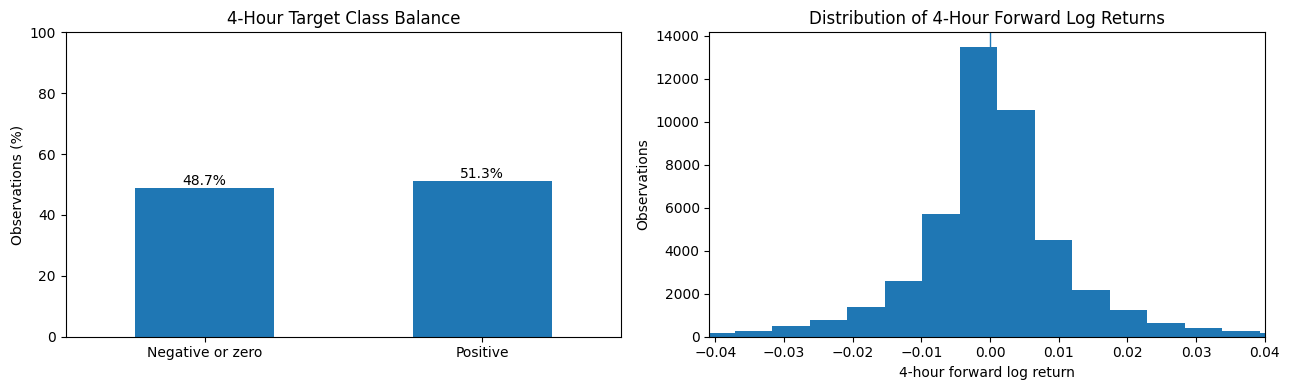

Observations: 45,537
Median return: 0.000199
Positive class: 51.27%


In [73]:
# d) Examine the 4-hour target distribution and class balance

fwd_ret_4h = targets_train["fwd_logret_4h"].reindex(X_train_engineered.index).dropna()
y_sign_4h = (fwd_ret_4h > 0).astype(int)

class_balance = y_sign_4h.value_counts(normalize=True).sort_index().mul(100)
class_balance.index = ["Negative or zero", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_balance.plot(kind="bar", ax=axes[0])
axes[0].set_title("4-Hour Target Class Balance")
axes[0].set_ylabel("Observations (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

for position, value in enumerate(class_balance):
    axes[0].text(position, value + 1, f"{value:.1f}%", ha="center")

axes[1].hist(fwd_ret_4h, bins=100)
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Distribution of 4-Hour Forward Log Returns")
axes[1].set_xlabel("4-hour forward log return")
axes[1].set_ylabel("Observations")
axes[1].set_xlim(fwd_ret_4h.quantile(0.01), fwd_ret_4h.quantile(0.99))

plt.tight_layout()
plt.show()

print(f"Observations: {len(fwd_ret_4h):,}")
print(f"Median return: {fwd_ret_4h.median():.6f}")
print(f"Positive class: {y_sign_4h.mean() * 100:.2f}%")

The 4-hour target is relatively balanced, suggesting that class imbalance is unlikely to be a major issue during model training. However, the return distribution contains a substantial concentration of observations close to zero, which may represent noise or economically negligible price movements.

The next step therefore examines whether a symmetric dead zone should be applied so that near-zero returns do not blur the distinction between meaningful positive and negative outcomes.

In [74]:
# Compare symmetric dead-zone thresholds for the selected 4-hour target
thresholds = [0.0000, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0030, 0.0040, 0.0050]
threshold_rows = []

for threshold in thresholds:
    keep = fwd_ret_4h.abs() > threshold
    y_threshold = (fwd_ret_4h[keep] > 0).astype(int)

    threshold_rows.append({
        "threshold_pct": threshold * 100,
        "rows_removed": (~keep).sum(),
        "rows_removed_pct": (~keep).mean() * 100,
        "rows_remaining": keep.sum(),
        "negative_count": (y_threshold == 0).sum(),
        "positive_count": (y_threshold == 1).sum(),
        "positive_pct": y_threshold.mean() * 100})

threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary.style.format({
    "threshold_pct": "{:.2f}%",
    "rows_removed_pct": "{:.2f}%",
    "positive_pct": "{:.2f}%"}))

,threshold_pct,rows_removed,rows_removed_pct,rows_remaining,negative_count,positive_count,positive_pct
0,0.00%,9,0.02%,45528,22181,23347,51.28%
1,0.05%,2899,6.37%,42638,20710,21928,51.43%
2,0.10%,5812,12.76%,39725,19262,20463,51.51%
3,0.15%,8601,18.89%,36936,17869,19067,51.62%
4,0.20%,11157,24.50%,34380,16614,17766,51.68%
5,0.25%,13487,29.62%,32050,15470,16580,51.73%
6,0.30%,15688,34.45%,29849,14382,15467,51.82%
7,0.40%,19667,43.19%,25870,12456,13414,51.85%
8,0.50%,22893,50.27%,22644,10913,11731,51.81%


A symmetric dead zone of ±0.05% is selected to remove the most ambiguous near-zero returns without materially reducing the sample available for model training and cross-validation. It excludes 6.37% of observations, retains 42,638 samples and preserves a balanced target with 51.43% positive observations.

#### **e) Final Target Definition**

Let $F_t$ denote the hourly closing price of the Binance USD-margined BTCUSDT perpetual-futures contract. The selected target is the 4-hour forward log return:

$$
r_{t,t+4}^{\mathrm{perp}}
=
\log\left(\frac{F_{t+4}}{F_t}\right).
$$

A symmetric dead zone of $\tau=0.0005$, equivalent to $\pm0.05\%$, is applied. The binary target is:

$$
y_t=
\begin{cases}
1, & r_{t,t+4}^{\mathrm{perp}}>0.0005,\\
0, & r_{t,t+4}^{\mathrm{perp}}<-0.0005.
\end{cases}
$$

Observations satisfying

$$
\left|r_{t,t+4}^{\mathrm{perp}}\right|\leq0.0005
$$

are excluded.

The dead zone removes 2,899 observations, or 6.37%, while retaining 42,638 observations and a balanced target with 51.43% positive outcomes. The continuous `fwd_logret_4h` series is retained, while the binary label is created during model preparation.

In [75]:
# Save 4-hour target files for modelling
for split in ["train", "test"]:
    source_path = DATA_PATH / f"targets_{split}_1h.csv"
    output_path = DATA_PATH / f"targets_{split}_4h.csv"

    target_df = pd.read_csv(source_path)
    target_df[["timestamp", "fwd_logret_4h"]].to_csv(output_path, index=False)

    print(f"Saved: {output_path.name} | {target_df.shape[0]:,} rows")

Saved: targets_train_4h.csv | 45,537 rows
Saved: targets_test_4h.csv | 11,391 rows


## **(VI) Feature Selection**

Feature selection reduces the engineered predictor set to a smaller group of informative and non-redundant variables using training data only. Highly correlated or mechanically duplicated features are removed first, followed by a multicollinearity review using VIF.

Boruta then identifies features with useful nonlinear information, while SHAP and Elastic Net provide alternative importance and stability rankings. Candidate subsets are compared under the same chronological validation framework, and the strongest compact feature set is retained for model training.

In [76]:
# Load the final engineered training matrix
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")
X_train_engineered = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_train_engineered.index = pd.to_datetime(X_train_engineered.index, utc=True)

print(f"Engineered training matrix: {X_train_engineered.shape}")
print(f"Period: {X_train_engineered.index.min()} to {X_train_engineered.index.max()}")

Engineered training matrix: (40497, 95)
Period: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


### **a) Simple feature to feature Pearson Correlation Heatmap**

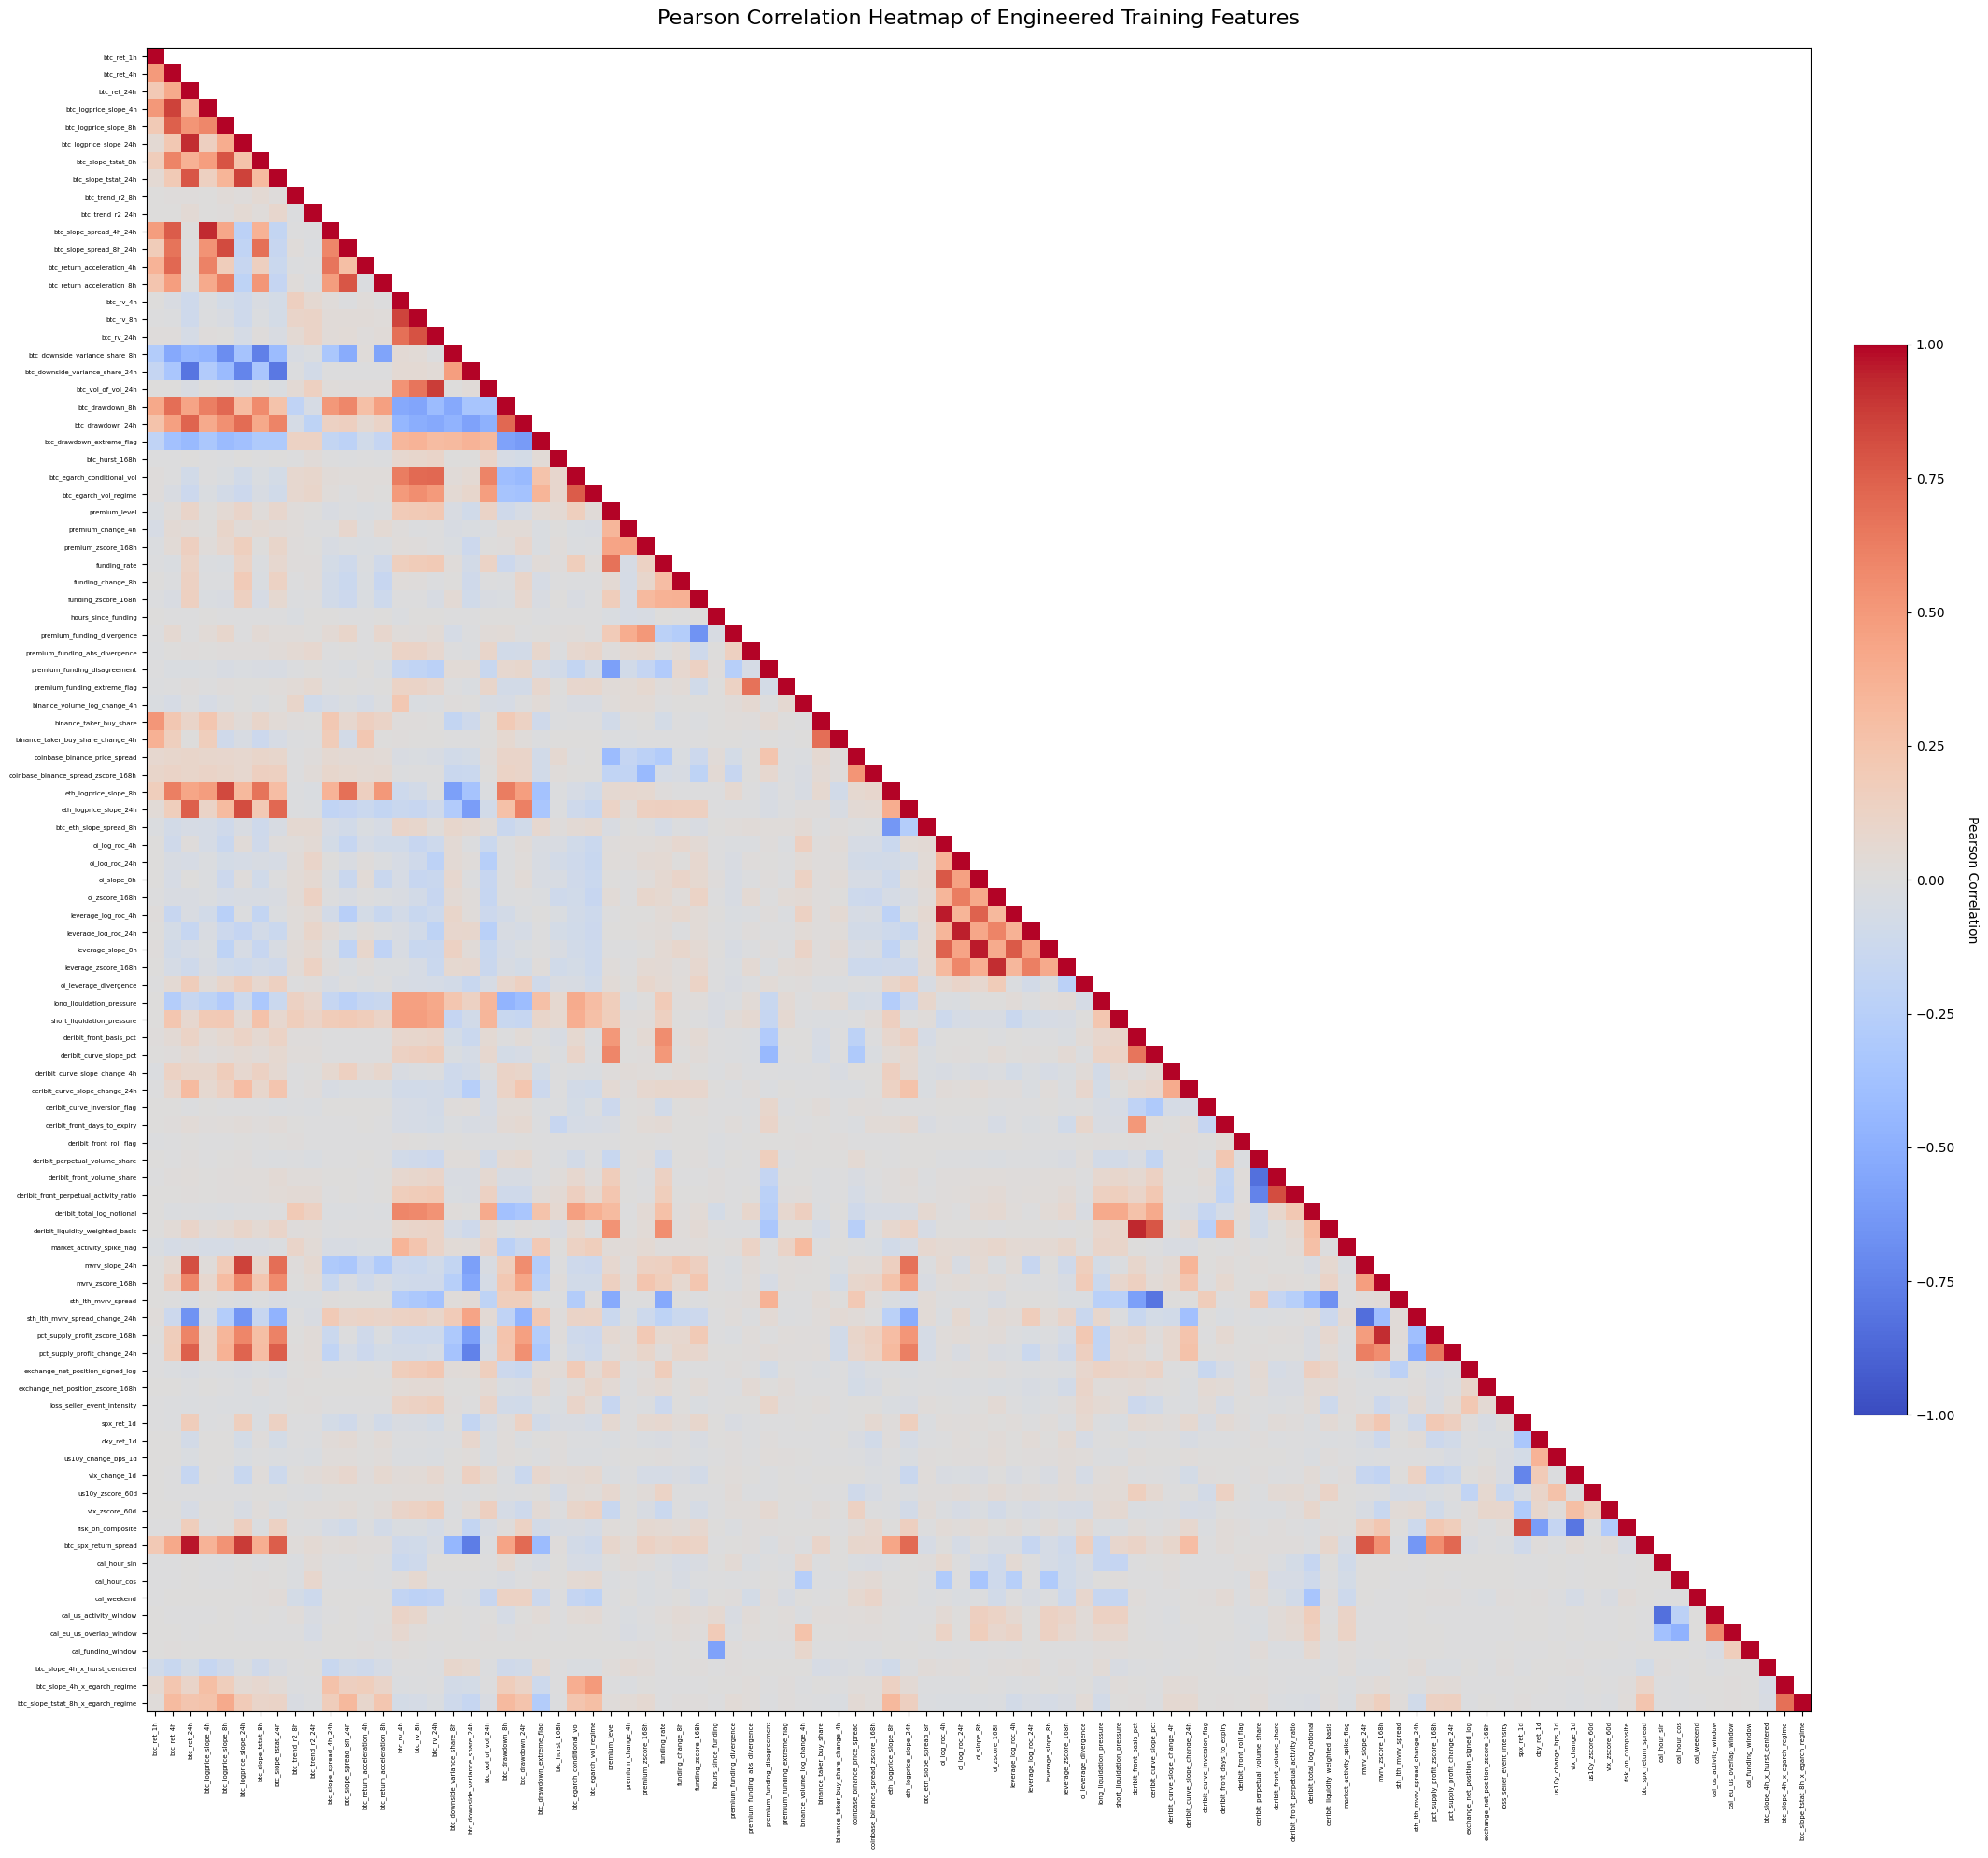

In [77]:
# Plot the complete feature-to-feature Pearson correlation heatmap
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
feature_corr_plot = np.ma.masked_where(upper_mask, feature_corr.to_numpy())

fig, ax = plt.subplots(figsize=(24, 20))
heatmap = ax.imshow(feature_corr_plot, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.index)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=5)
ax.set_yticklabels(feature_corr.index, fontsize=5)
ax.set_title("Pearson Correlation Heatmap of Engineered Training Features", fontsize=16, pad=18)

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

The heatmap shows that strong correlations are concentrated within related feature groups, particularly BTC trend, volatility, on-chain and term-structure measures. Most cross-family relationships remain weak to moderate, indicating that the feature set retains substantial complementary information.

**Correlation Review and Structural Pruning**

The correlation matrix is used to identify strongly related feature pairs. Features are not removed mechanically from every highly correlated pair; pruning is limited to variables that are structurally redundant or largely replicate information already retained elsewhere.

In [78]:
# a) Correlation Review and Structural Pruning
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

high_corr_pairs = feature_corr.where(upper_mask).stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.90]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

correlation_drop_features = [
    "btc_spx_return_spread",
    "btc_slope_spread_4h_24h",
    "deribit_front_basis_pct"]

X_train_corr_trimmed = X_train_engineered.drop(columns=correlation_drop_features)

remaining_corr = X_train_corr_trimmed.corr(method="pearson")
upper_mask = np.triu(np.ones(remaining_corr.shape, dtype=bool), k=1)

remaining_pairs = remaining_corr.where(upper_mask).stack().reset_index()
remaining_pairs.columns = ["feature_1", "feature_2", "correlation"]
remaining_pairs["abs_correlation"] = remaining_pairs["correlation"].abs()
remaining_pairs = remaining_pairs[remaining_pairs["abs_correlation"] >= 0.90]
remaining_pairs = remaining_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print(f"Original features: {X_train_engineered.shape[1]}")
print(f"Highly correlated pairs before pruning: {len(high_corr_pairs)}")
print(f"Features removed: {correlation_drop_features}")
print(f"Remaining features: {X_train_corr_trimmed.shape[1]}")
print(f"Highly correlated pairs after pruning: {len(remaining_pairs)}")

display(high_corr_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))
print()
display(remaining_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Original features: 95
Highly correlated pairs before pruning: 9
Features removed: ['btc_spx_return_spread', 'btc_slope_spread_4h_24h', 'deribit_front_basis_pct']
Remaining features: 92
Highly correlated pairs after pruning: 6


,feature_1,feature_2,correlation,abs_correlation
0,btc_ret_24h,btc_spx_return_spread,0.9640,0.9640
1,oi_slope_8h,leverage_slope_8h,0.9587,0.9587
2,oi_log_roc_4h,leverage_log_roc_4h,0.9570,0.9570
3,oi_log_roc_24h,leverage_log_roc_24h,0.9475,0.9475
4,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9310,0.9310
5,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9287,0.9287
6,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
7,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148
8,oi_zscore_168h,leverage_zscore_168h,0.9146,0.9146


,feature_1,feature_2,correlation,abs_correlation
0,oi_slope_8h,leverage_slope_8h,0.9587,0.9587
1,oi_log_roc_4h,leverage_log_roc_4h,0.9570,0.9570
2,oi_log_roc_24h,leverage_log_roc_24h,0.9475,0.9475
3,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
4,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148
5,oi_zscore_168h,leverage_zscore_168h,0.9146,0.9146


Three constructed features are removed because they largely duplicate information retained in their underlying components or broader alternatives. The remaining correlated pairs are preserved for later VIF and model-based feature selection rather than removed solely on pairwise correlation.

### **b) Variance Inflation Factor (VIF) Review**

VIF is used here to check whether a feature is largely explained by another predictor. A threshold of 30 is used only to flag severe multicollinearity for review. Features are not removed automatically at this stage, as the later feature-selection methods will determine which variables to retain.

In [79]:
# ii) Review multicollinearity using VIF
corr_matrix = X_train_corr_trimmed.corr().to_numpy()
inverse_corr = np.linalg.pinv(corr_matrix)

vif_results = pd.DataFrame({
    "feature": X_train_corr_trimmed.columns,
    "VIF": np.diag(inverse_corr)}).sort_values("VIF", ascending=False).reset_index(drop=True)

high_vif_features = vif_results[vif_results["VIF"] > 30]

print(f"Features assessed: {len(vif_results)}")
print(f"Features with VIF > 30: {len(high_vif_features)}")
display(high_vif_features.style.format({"VIF": "{:.2f}"}))

Features assessed: 92
Features with VIF > 30: 6


,feature,VIF
0,btc_ret_4h,67.35
1,leverage_slope_8h,41.11
2,oi_slope_8h,40.69
3,leverage_log_roc_4h,34.64
4,oi_log_roc_4h,33.82
5,btc_return_acceleration_4h,30.17


Only btc_ret_4h exceeds the VIF threshold of 30. It is retained as an interpretable momentum measure, with final selection left to the subsequent feature-selection methods.

### **c) Boruta**

Given the size of the feature set and the likelihood of nonlinear relationships and interactions, Boruta is used to identify variables with predictive information that may not be captured by correlation or VIF analysis. The aim is to further reduce the feature set to variables that contribute useful information about 4-hour forward returns.

The locked ±0.05% dead zone is applied based on the earlier class-balance and near-zero-return analysis. This helps Boruta focus on clearer positive and negative outcomes while retaining sufficient observations for training and cross-validation.

In [82]:
# Run Boruta using the locked ±0.05% dead zone
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

targets_train = pd.read_csv(DATA_PATH / "targets_train_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
targets_train.index = pd.to_datetime(targets_train.index, utc=True)

common_index = X_train_corr_trimmed.index.intersection(targets_train.index)
fwd_ret_4h = targets_train.loc[common_index, "fwd_logret_4h"]
keep_mask = fwd_ret_4h.abs() > 0.0005

X_boruta = X_train_corr_trimmed.loc[common_index].loc[keep_mask]
y_boruta = (fwd_ret_4h.loc[keep_mask] > 0).astype(int).rename("target_4h")

print(f"Boruta sample: {X_boruta.shape}")
print(f"Positive class: {y_boruta.mean() * 100:.2f}%")

rf = RandomForestClassifier(max_depth=5, min_samples_leaf=20, max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", max_iter=100, perc=100, alpha=0.05, two_step=True, random_state=42, verbose=0)

start_time = time.time()
boruta.fit(X_boruta.to_numpy(), y_boruta.to_numpy())
runtime_minutes = (time.time() - start_time) / 60

boruta_results = pd.DataFrame({
    "feature": X_boruta.columns,
    "confirmed": boruta.support_,
    "tentative": boruta.support_weak_,
    "ranking": boruta.ranking_}).sort_values(["confirmed", "tentative", "ranking"], ascending=[False, False, True]).reset_index(drop=True)

confirmed_features = boruta_results.loc[boruta_results["confirmed"], "feature"].tolist()
tentative_features = boruta_results.loc[boruta_results["tentative"], "feature"].tolist()
inclusive_features = confirmed_features + tentative_features

X_train_boruta_inclusive = X_boruta[inclusive_features]

X_train_boruta_inclusive.to_csv(DATA_PATH / "X_train_boruta_inclusive_4h.csv", index_label="timestamp")
y_boruta.to_frame().to_csv(DATA_PATH / "y_train_boruta_4h.csv", index_label="timestamp")
boruta_results.to_csv(DATA_PATH / "boruta_results_4h.csv", index=False)

print(f"Runtime: {runtime_minutes:.2f} minutes")
print(f"Confirmed: {len(confirmed_features)}")
print(f"Tentative: {len(tentative_features)}")
print(f"Rejected: {len(boruta_results) - len(inclusive_features)}")
print(f"Inclusive matrix: {X_train_boruta_inclusive.shape}")

display(boruta_results)

Boruta sample: (37921, 92)
Positive class: 51.28%
Runtime: 12.26 minutes
Confirmed: 67
Tentative: 1
Rejected: 24
Inclusive matrix: (37921, 68)


,feature,confirmed,tentative,ranking
0,btc_ret_1h,True,False,1
1,btc_ret_4h,True,False,1
2,btc_ret_24h,True,False,1
3,btc_logprice_slope_4h,True,False,1
4,btc_logprice_slope_8h,True,False,1
...,...,...,...,...
87,cal_eu_us_overlap_window,False,False,22
88,premium_funding_extreme_flag,False,False,23
89,cal_funding_window,False,False,24
90,deribit_curve_inversion_flag,False,False,25


Boruta retained 68 of the 92 candidate features, comprising 67 confirmed and one tentative variable. The retained set spans BTC trend and volatility, derivatives positioning, term structure, on-chain measures, macro variables and regime interactions, indicating that predictive information is distributed across several feature themes rather than concentrated in price alone.

Twenty-four features were rejected, including several event flags, calendar indicators and closely related derivatives measures. The single tentative feature, `exchange_net_position_zscore_168h`, is retained in the inclusive set for comparison during the later feature-set evaluation.

### **d) SHAP Analysis and Ranking on Boruta Surviving Features**

SHAP is applied to the Boruta-surviving features to rank their contribution within a nonlinear model. An internal XGBoost model is trained using a chronological train-validation split with a four-hour purge. This model is used only for feature analysis and is not treated as a final forecasting model.

In [83]:
# Train an XGBoost model for SHAP analysis
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

X_shap_all = X_train_boruta_inclusive
y_shap_all = y_boruta.loc[X_shap_all.index]

split_time = X_shap_all.index[int(len(X_shap_all) * 0.80)]
X_shap_train = X_shap_all.loc[X_shap_all.index < split_time - pd.Timedelta(hours=4)]
X_shap_valid = X_shap_all.loc[X_shap_all.index >= split_time]
y_shap_train = y_shap_all.loc[X_shap_train.index]
y_shap_valid = y_shap_all.loc[X_shap_valid.index]

print(f"Training: {X_shap_train.shape}")
print(f"Validation: {X_shap_valid.shape}")

shap_model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss", n_estimators=1000,
    learning_rate=0.03, max_depth=4, min_child_weight=20, subsample=0.80,
    colsample_bytree=0.80, reg_alpha=0.10, reg_lambda=2.00,
    tree_method="hist", early_stopping_rounds=50, n_jobs=-1, random_state=42)

start_time = time.time()
shap_model.fit(X_shap_train, y_shap_train, eval_set=[(X_shap_valid, y_shap_valid)], verbose=False)
runtime_minutes = (time.time() - start_time) / 60

valid_probability = shap_model.predict_proba(X_shap_valid)[:, 1]
valid_prediction = (valid_probability >= 0.50).astype(int)
X_shap_sample = X_shap_valid.sample(min(5000, len(X_shap_valid)), random_state=42).sort_index()

print(f"Runtime: {runtime_minutes:.2f} minutes")
print(f"Best boosting round: {shap_model.best_iteration}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_shap_valid, valid_prediction):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_shap_valid, valid_probability):.4f}")
print(f"SHAP sample: {len(X_shap_sample):,} rows")

Training: (30334, 68)
Validation: (7585, 68)
Runtime: 0.04 minutes
Best boosting round: 57
Balanced accuracy: 0.5334
ROC-AUC: 0.5521
SHAP sample: 5,000 rows


In [84]:
# Calculate and rank SHAP feature importance
import shap

explainer = shap.TreeExplainer(shap_model)
shap_values = np.asarray(explainer.shap_values(X_shap_sample))
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_ranking = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_ranking["rank"] = np.arange(1, len(shap_ranking) + 1)
shap_ranking["shap_share"] = shap_ranking["mean_abs_shap"] / shap_ranking["mean_abs_shap"].sum()
shap_ranking["cumulative_shap_share"] = shap_ranking["shap_share"].cumsum()

features_to_80pct = (shap_ranking["cumulative_shap_share"] < 0.80).sum() + 1
features_to_90pct = (shap_ranking["cumulative_shap_share"] < 0.90).sum() + 1

shap_ranking.to_csv(DATA_PATH / "shap_feature_ranking_4h.csv", index=False)

print(f"SHAP features: {len(shap_ranking)}")
print(f"Features for 80% cumulative SHAP: {features_to_80pct}")
print(f"Features for 90% cumulative SHAP: {features_to_90pct}")
print(f"Top 20 SHAP share: {shap_ranking.head(20)['shap_share'].sum() * 100:.2f}%")
print(f"Top 30 SHAP share: {shap_ranking.head(30)['shap_share'].sum() * 100:.2f}%")

display(shap_ranking.head(40).style.format({
    "mean_abs_shap": "{:.6f}",
    "shap_share": "{:.2%}",
    "cumulative_shap_share": "{:.2%}"}))

SHAP features: 68
Features for 80% cumulative SHAP: 24
Features for 90% cumulative SHAP: 36
Top 20 SHAP share: 75.85%
Top 30 SHAP share: 85.79%


,feature,mean_abs_shap,rank,shap_share,cumulative_shap_share
0,btc_ret_4h,0.060331,1,12.81%,12.81%
1,btc_logprice_slope_4h,0.045111,2,9.58%,22.39%
2,btc_slope_tstat_8h,0.028455,3,6.04%,28.43%
3,btc_drawdown_8h,0.026024,4,5.53%,33.96%
4,coinbase_binance_spread_zscore_168h,0.025708,5,5.46%,39.42%
5,btc_drawdown_24h,0.022337,6,4.74%,44.16%
6,btc_ret_24h,0.021419,7,4.55%,48.71%
7,btc_downside_variance_share_24h,0.021223,8,4.51%,53.22%
8,cal_hour_cos,0.013850,9,2.94%,56.16%
9,eth_logprice_slope_8h,0.013245,10,2.81%,58.97%


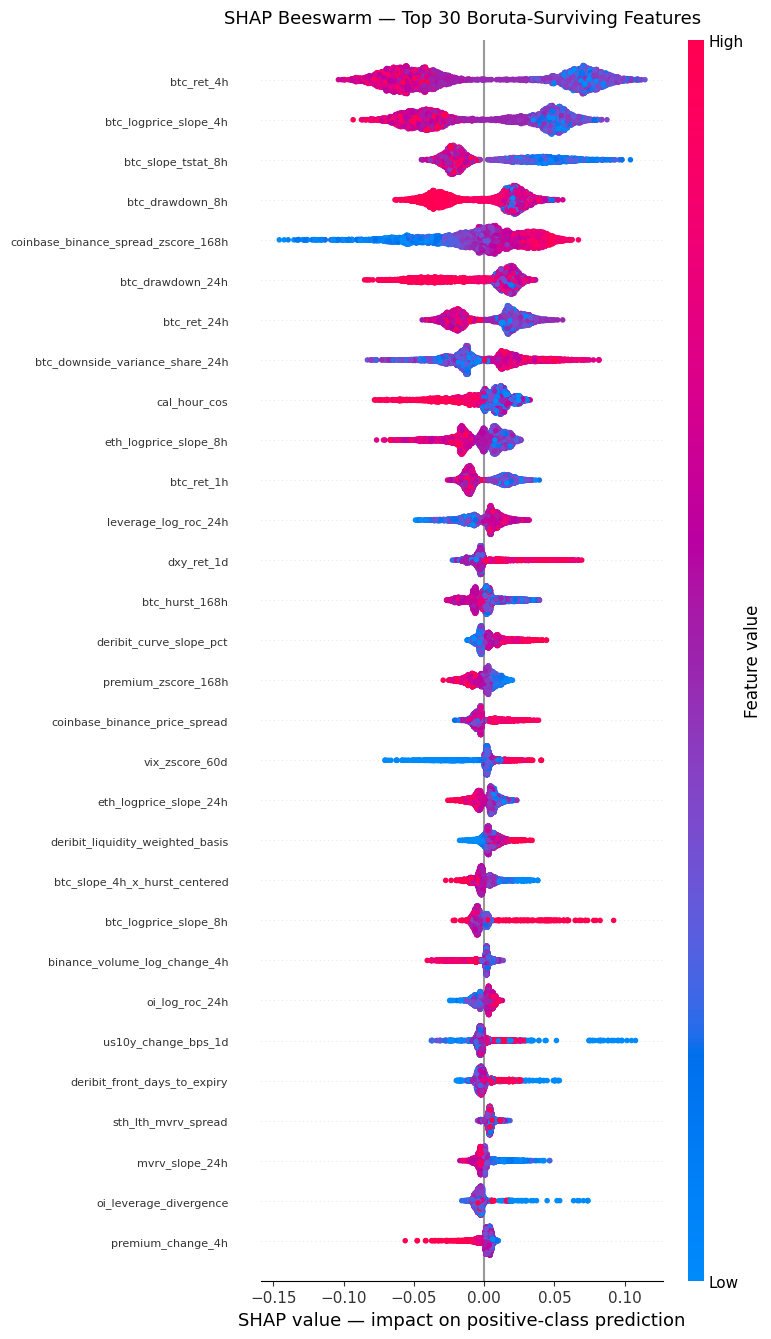

In [85]:
# Plot the SHAP beeswarm summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="dot", max_display=30, show=False)

plt.title("SHAP Beeswarm — Top 30 Boruta-Surviving Features", fontsize=13, pad=12)
plt.xlabel("SHAP value — impact on positive-class prediction")
plt.gca().tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

SHAP importance is concentrated in a relatively small part of the 68-feature Boruta set. The top 20 features account for 75.85% of total importance, while 24 and 36 features are required to reach 80% and 90%, respectively.

Short-term BTC perpetual-futures returns, trend and drawdown variables dominate the ranking, led by `btc_ret_4h` and `btc_logprice_slope_4h`. However, cross-exchange spreads, ETH trend, leverage, macro, term-structure and regime features also appear among the leading variables, indicating that the model draws on several complementary sources of information rather than price alone.

### **e) Boruta Surviving Feature Tournament for Final Selection**

Boruta retained 68 features, but the full set may still introduce noise and overfitting. A feature-set tournament therefore compares smaller Elastic Net and SHAP-ranked subsets against the full Boruta candidates.

Elastic Net provides a stable linear ranking when predictors are correlated and complements the tree-based Boruta and SHAP selections.

In [86]:
# Rank features using Elastic Net stability
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def purged_splits(X, n_splits):
    splits = []
    for train_idx, valid_idx in TimeSeriesSplit(n_splits=n_splits).split(X):
        valid_start = X.index[valid_idx[0]]
        train_idx = train_idx[X.index[train_idx] < valid_start - pd.Timedelta(hours=4)]
        splits.append((train_idx, valid_idx))
    return splits

tuning_splits = purged_splits(X_shap_train, 3)

elastic_net_cv = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=[0.01, 0.05, 0.20, 1.00],
        cv=tuning_splits,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.25, 0.50, 0.75],
        scoring="roc_auc",
        max_iter=3000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1))

start_time = time.time()
elastic_net_cv.fit(X_shap_train, y_shap_train)
runtime_minutes = (time.time() - start_time) / 60

cv_model = elastic_net_cv.named_steps["logisticregressioncv"]
best_c = float(cv_model.C_[0])
best_l1_ratio = float(cv_model.l1_ratio_[0])

fold_coefficients = []

for fold, (train_idx, _) in enumerate(purged_splits(X_shap_train, 5), start=1):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="elasticnet", solver="saga", C=best_c, l1_ratio=best_l1_ratio,
            max_iter=3000, tol=1e-3, random_state=42))

    model.fit(X_shap_train.iloc[train_idx], y_shap_train.iloc[train_idx])
    coefficients = model.named_steps["logisticregression"].coef_.ravel()
    fold_coefficients.append(pd.Series(coefficients, index=X_shap_train.columns, name=f"fold_{fold}"))

fold_coefficients = pd.concat(fold_coefficients, axis=1)
nonzero = fold_coefficients.abs() > 1e-6

sign_consistency = fold_coefficients.apply(
    lambda row: max((row[row.abs() > 1e-6] > 0).mean(), (row[row.abs() > 1e-6] < 0).mean())
    if (row.abs() > 1e-6).any() else 0, axis=1)

elastic_net_ranking = pd.DataFrame({
    "feature": X_shap_train.columns,
    "selection_frequency": nonzero.mean(axis=1),
    "sign_consistency": sign_consistency,
    "median_abs_coefficient": fold_coefficients.abs().median(axis=1)}).sort_values(
    ["selection_frequency", "sign_consistency", "median_abs_coefficient"],
    ascending=False).reset_index(drop=True)

elastic_net_ranking["rank"] = np.arange(1, len(elastic_net_ranking) + 1)
elastic_net_features = elastic_net_ranking.head(30)["feature"].tolist()

elastic_net_ranking.to_csv(DATA_PATH / "elastic_net_stability_ranking_4h.csv", index=False)
pd.DataFrame({"feature": elastic_net_features}).to_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv", index=False)

print(f"Runtime: {runtime_minutes:.2f} minutes")
print(f"Best C: {best_c}")
print(f"Best L1 ratio: {best_l1_ratio}")
print(f"Selected features: {len(elastic_net_features)}")

display(elastic_net_ranking.head(40).style.format({
    "selection_frequency": "{:.2f}",
    "sign_consistency": "{:.2f}",
    "median_abs_coefficient": "{:.6f}"}))

Runtime: 0.53 minutes
Best C: 0.05
Best L1 ratio: 0.75
Selected features: 30


,feature,selection_frequency,sign_consistency,median_abs_coefficient,rank
0,btc_logprice_slope_24h,1.00,1.00,0.343051,1
1,btc_slope_tstat_8h,1.00,1.00,0.224154,2
2,btc_logprice_slope_8h,1.00,1.00,0.183592,3
3,btc_ret_24h,1.00,1.00,0.148182,4
4,eth_logprice_slope_24h,1.00,1.00,0.091165,5
5,mvrv_zscore_168h,1.00,1.00,0.085372,6
6,oi_log_roc_24h,1.00,1.00,0.073551,7
7,cal_hour_cos,1.00,1.00,0.051075,8
8,btc_vol_of_vol_24h,1.00,1.00,0.050633,9
9,btc_return_acceleration_4h,1.00,1.00,0.049129,10


The top 20 and top 30 Elastic Net subsets are retained for comparison with the broader Boruta and SHAP candidates.

In [87]:
# Compare candidate feature sets under the same chronological benchmark
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_sets = {
    "SHAP top 20": shap_ranking.head(20)["feature"].tolist(),
    "SHAP 80%": shap_ranking.head(features_to_80pct)["feature"].tolist(),
    "Elastic Net top 30": elastic_net_features,
    "SHAP 90%": shap_ranking.head(features_to_90pct)["feature"].tolist(),
    "Boruta confirmed": confirmed_features,
    "Boruta inclusive": inclusive_features}

tournament_results = []
cv_splits = purged_splits(X_boruta, 5)

for set_name, features in feature_sets.items():
    fold_scores = []

    for train_idx, valid_idx in cv_splits:
        model = make_pipeline(StandardScaler(), LogisticRegression(penalty="l2", C=1.0, max_iter=2000, random_state=42))
        model.fit(X_boruta.iloc[train_idx][features], y_boruta.iloc[train_idx])

        probability = model.predict_proba(X_boruta.iloc[valid_idx][features])[:, 1]
        prediction = (probability >= 0.50).astype(int)

        fold_scores.append({
            "roc_auc": roc_auc_score(y_boruta.iloc[valid_idx], probability),
            "balanced_accuracy": balanced_accuracy_score(y_boruta.iloc[valid_idx], prediction)
        })

    fold_scores = pd.DataFrame(fold_scores)

    tournament_results.append({
        "feature_set": set_name,
        "features": len(features),
        "mean_roc_auc": fold_scores["roc_auc"].mean(),
        "std_roc_auc": fold_scores["roc_auc"].std(),
        "mean_balanced_accuracy": fold_scores["balanced_accuracy"].mean(),
        "std_balanced_accuracy": fold_scores["balanced_accuracy"].std()})

tournament_results = pd.DataFrame(tournament_results)
tournament_results = tournament_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

display(tournament_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

,feature_set,features,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,Elastic Net top 30,30,0.5583,0.0151,0.5404,0.0109
1,SHAP 80%,24,0.5565,0.0168,0.5407,0.0136
2,SHAP 90%,36,0.5535,0.0173,0.5372,0.0166
3,Boruta inclusive,68,0.5534,0.0178,0.5371,0.0147
4,Boruta confirmed,67,0.5533,0.0178,0.5370,0.0144
5,SHAP top 20,20,0.5489,0.0128,0.5338,0.0131


The 30-feature Elastic Net subset achieved the highest mean ROC-AUC of 0.5583, with balanced accuracy of 0.5404. It outperformed the larger Boruta sets and smaller SHAP subsets and was therefore selected as the best balance between predictive performance and model simplicity.

### **f) Final Feature Set**

The table summarises the 30 retained features by theme, economic interpretation, engineering status and data source. The final set spans BTC trend, momentum and volatility, derivatives positioning, term structure, cross-exchange pricing, on-chain activity, ETH, macroeconomic and calendar information.

| Feature                               | Feature family            | Economic interpretation                                                                                                                                         | Engineered feature | Data source          |
| ------------------------------------- | ------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------ | -------------------- |
| `btc_logprice_slope_24h`              | BTC trend                 | Direction and magnitude of the fitted BTC log-price trend over the preceding 24 hours.                                                                          | Yes                | Binance              |
| `btc_slope_tstat_8h`                  | BTC trend                 | Statistical strength of the fitted short-term BTC price trend, distinguishing persistent movement from noisy price variation.                                   | Yes                | Binance              |
| `btc_logprice_slope_8h`               | BTC trend                 | Direction and magnitude of the fitted BTC log-price trend over the preceding 8 hours.                                                                           | Yes                | Binance              |
| `btc_ret_24h`                         | BTC momentum              | BTC log return over the preceding 24 hours, representing medium-term directional momentum.                                                                      | Yes                | Binance              |
| `btc_drawdown_24h`                    | BTC downside state        | Distance of the current BTC price below its trailing 24-hour maximum, capturing recent downside pressure and recovery state.                                    | Yes                | Binance              |
| `eth_logprice_slope_24h`              | Cross-asset trend         | Fitted 24-hour ETH log-price trend, capturing directional information from the largest related cryptoasset market.                                              | Yes                | Binance              |
| `leverage_log_roc_24h`                | Derivatives positioning   | 24-hour change in aggregate market leverage on a logarithmic scale, indicating expansion or contraction in leveraged positioning.                               | Yes                | Glassnode            |
| `btc_vol_of_vol_24h`                  | BTC volatility            | Variability of short-horizon realised volatility over the preceding 24 hours, capturing instability in the volatility regime.                                   | Yes                | Binance              |
| `cal_hour_cos`                        | Calendar seasonality      | Cyclical encoding of the UTC trading hour, allowing the models to represent recurring intraday liquidity and participation patterns.                            | Yes                | Timestamp            |
| `btc_return_acceleration_4h`          | BTC momentum              | Difference between the latest 4-hour BTC return and the preceding 4-hour return, measuring acceleration or deceleration in price movement.                      | Yes                | Binance              |
| `btc_downside_variance_share_8h`      | BTC downside risk         | Proportion of trailing 8-hour realised variance attributable to negative returns, measuring asymmetry in recent price risk.                                     | Yes                | Binance              |
| `btc_slope_4h_x_hurst_centered`       | Regime interaction        | Interaction between the short-term BTC trend and the centred Hurst estimate, allowing trend effects to vary between persistent and mean-reverting regimes.      | Yes                | Binance              |
| `btc_slope_tstat_8h_x_egarch_regime`  | Regime interaction        | Interaction between short-term trend strength and the standardised EGARCH volatility regime, allowing trend predictability to vary with conditional volatility. | Yes                | Binance              |
| `oi_log_roc_4h`                       | Derivatives positioning   | Four-hour logarithmic change in perpetual-futures open interest, capturing rapid additions to or reductions in market exposure.                                 | Yes                | Glassnode            |
| `deribit_front_days_to_expiry`        | Futures term structure    | Remaining maturity of the nearest dated BTC futures contract, controlling for contract roll and maturity effects in the futures curve.                          | Yes                | Deribit              |
| `leverage_slope_8h`                   | Derivatives positioning   | Fitted trend in the logarithm of aggregate leverage over the preceding 8 hours, capturing the direction of leverage accumulation.                               | Yes                | Glassnode            |
| `pct_supply_profit_change_24h`        | On-chain profitability    | 24-hour change in the percentage of BTC supply held in profit, representing changes in aggregate holder profitability and potential selling pressure.           | Yes                | Glassnode            |
| `btc_trend_r2_8h`                     | BTC trend quality         | Proportion of short-term log-price variation explained by a fitted 8-hour linear trend, measuring trend consistency.                                            | Yes                | Binance              |
| `btc_trend_r2_24h`                    | BTC trend quality         | Proportion of log-price variation explained by a fitted 24-hour linear trend, measuring medium-term trend consistency.                                          | Yes                | Binance              |
| `premium_zscore_168h`                 | Perpetual-futures pricing | Binance perpetual premium standardised against its trailing 168-hour distribution, capturing unusually rich or discounted futures pricing.                      | Yes                | Binance              |
| `dxy_ret_1d`                          | Macro                     | Most recently available one-day US Dollar Index log return, representing broad changes in dollar strength and global risk conditions.                           | Yes                | Yahoo Finance        |
| `us10y_change_bps_1d`                 | Macro                     | Most recently available one-day change in the US 10-year Treasury yield, capturing changes in discount rates and macro-financial conditions.                    | Yes                | Yahoo Finance        |
| `exchange_net_position_signed_log`    | On-chain flows            | Signed logarithmic transformation of net BTC exchange-position change, retaining flow direction while reducing the influence of extreme observations.           | Yes                | Glassnode            |
| `btc_slope_tstat_24h`                 | BTC trend                 | Statistical strength of the fitted 24-hour BTC log-price trend, measuring whether medium-term direction is persistent relative to residual noise.               | Yes                | Binance              |
| `coinbase_binance_spread_zscore_168h` | Cross-exchange pricing    | Coinbase–Binance BTC price spread standardised over 168 hours, capturing unusual regional, venue-specific or liquidity-driven price dislocations.               | Yes                | Coinbase and Binance |
| `mvrv_zscore_168h`                    | On-chain valuation        | MVRV standardised against its trailing 168-hour distribution, measuring whether market value is unusually high or low relative to realised value.               | Yes                | Glassnode            |
| `btc_rv_24h`                          | BTC volatility            | Realised BTC volatility from hourly returns over the preceding 24 hours, representing the current magnitude of price risk.                                      | Yes                | Binance              |
| `deribit_total_log_notional`          | Derivatives activity      | Logarithm of aggregate hourly Deribit contract notional, capturing the level of institutional options and futures market activity.                              | Yes                | Deribit              |
| `deribit_curve_slope_pct`             | Futures term structure    | Difference between the second and front dated-futures basis, measuring the slope, steepness or inversion of the BTC futures curve.                              | Yes                | Deribit and Binance  |
| `btc_logprice_slope_4h`               | BTC trend                 | Direction and magnitude of the fitted BTC log-price trend over the preceding 4 hours.                                                                           | Yes                | Binance              |


## **(VII) Base-Learner Training and Selection**

Stacking is most useful when its Level-0 base learners are individually credible but make meaningfully different errors. This stage therefore begins with a broad comparison of linear, tree-based, kernel and sequential model families under the same chronological validation framework. Candidates are assessed not only on standalone predictive performance, but also on whether their different functional forms produce complementary out-of-fold signals. The model family is then narrowed through preprocessing review, untuned benchmarking, hyperparameter tuning and prediction-diversity analysis before the retained learners are passed to the Level-1 meta-model in the subsequent stacking stage.

### **Part I) Training Model Data Pre-Processing**


**Construct the Locked 30-Feature Training Dataset**

The final 30 features are aligned with the four-hour forward return, filtered using the ±0.05% dead zone and converted into the model-ready binary-classification sample.

In [88]:
# Build and save the locked 30-feature modelling dataset
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")
selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_model = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
targets = pd.read_csv(DATA_PATH / "targets_train_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()

X_model.index = pd.to_datetime(X_model.index, utc=True)
targets.index = pd.to_datetime(targets.index, utc=True)

X_model = X_model[selected_features]
fwd_return_model = targets["fwd_logret_4h"].reindex(X_model.index)
keep_mask = fwd_return_model.abs() > 0.0005

X_model = X_model.loc[keep_mask]
fwd_return_model = fwd_return_model.loc[keep_mask].rename("fwd_logret_4h")
y_model = (fwd_return_model > 0).astype(int).rename("target_4h")

X_model.to_csv(DATA_PATH / "X_train_model_30_4h.csv", index_label="timestamp")
y_model.to_frame().to_csv(DATA_PATH / "y_train_model_4h.csv", index_label="timestamp")
fwd_return_model.to_frame().to_csv(DATA_PATH / "returns_train_model_4h.csv", index_label="timestamp")

print(f"Modelling sample: {X_model.shape}")
print(f"Positive class: {y_model.mean() * 100:.2f}%")
print(f"Period: {X_model.index.min()} to {X_model.index.max()}")

Modelling sample: (37921, 30)
Positive class: 51.28%
Period: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


### **Part II) Candidate Model Families and Preprocessing**

**Candidate Models and Preprocessing**

To make results comparable, scaling places features measured in different units on a similar range. This is especially important for models whose coefficients, distances or optimisation depend on feature magnitude, but is generally unnecessary for tree-based models, which split observations by order rather than scale. Scaling is therefore treated as a model-specific preprocessing choice.

| Model | Role in the benchmark | Why it is included | Scaling treatment |
|---|---|---|---|
| L2 logistic regression | Linear benchmark | Provides a transparent and strongly regularised reference model for approximately linear relationships | Standard, robust and min-max scaling compared because coefficient estimation is scale-sensitive |
| Random Forest | Nonlinear tree benchmark | Captures nonlinear relationships and feature interactions without requiring a parametric functional form | No scaling required because tree splits are invariant to monotonic rescaling |
| XGBoost | Gradient-boosted tree benchmark | Tests whether sequential boosting improves the extraction of weak nonlinear and threshold-based effects | No scaling required |
| CatBoost | Regularised boosting candidate | Offers strong nonlinear modelling with ordered boosting and additional resistance to overfitting | No scaling required |
| RBF SVM | Nonlinear kernel candidate | Captures smooth nonlinear decision boundaries and may provide predictions distinct from tree and linear models | Standard, robust and min-max scaling compared because distances in feature space depend directly on scale |
| GRU | Sequential deep-learning candidate | Uses the preceding 24-hour feature sequence to capture temporal dependence not represented by static tabular models | Standard, robust and min-max scaling compared because neural-network optimisation is sensitive to input magnitude |

In [89]:
# check if Colab is running on GPU
!nvidia-smi

Thu Aug  6 06:48:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   57C    P0             29W /   72W |     194MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [90]:
# import required libraries
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

**i) L2 Logistic Regression**

L2 logistic regression provides a transparent, strongly regularised linear benchmark. It models the conditional probability of an upward move as a sigmoid transformation of a linear index,

$$
p(\mathbf{x})
=
\sigma\left(\beta_0 + \boldsymbol{\beta}^{\top}\mathbf{x}\right),
\qquad
\sigma(u)=\frac{1}{1+e^{-u}},
$$

with coefficients fitted by minimising the penalised negative log-likelihood

$$
-\sum_{i=1}^{n}
\left[
y_i\log p(\mathbf{x}_i)
+
(1-y_i)\log\left(1-p(\mathbf{x}_i)\right)
\right]
+
\frac{1}{2C}\lVert\boldsymbol{\beta}\rVert_2^{2}.
$$

The $L_2$ penalty shrinks the coefficients toward zero, which stabilises estimation when predictors remain correlated after feature selection. The inverse regularisation strength $C$ controls this trade-off, with smaller values imposing stronger shrinkage. Because the linear index depends directly on feature magnitude, standard, robust and min-max scaling are compared for this model.

In [91]:
# Evaluate the untuned Logistic Regression Benchmark
from sklearn.linear_model import LogisticRegression

scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "minmax": MinMaxScaler()}

benchmark_rows = []
tuning_splits = purged_splits(X_model, 5)

for scaler_name, scaler in scalers.items():
    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        model = make_pipeline(scaler, LogisticRegression(penalty="l2", C=1.0, max_iter=2000, random_state=42))
        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        prediction = (probability >= 0.50).astype(int)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
            "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

l2_scaler_folds = pd.DataFrame(benchmark_rows)

l2_scaler_results = l2_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_l2_scaler = l2_scaler_results.loc[0, "scaler"]
l2_scaler_results.to_csv(DATA_PATH / "l2_scaler_benchmark_4h.csv", index=False)
print("Logistic Regression Benchmark Results")
display(l2_scaler_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

print(f"Best scaler: {best_l2_scaler}")

Logistic Regression Benchmark Results


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,robust,0.5584,0.0151,0.5406,0.0108
1,standard,0.5583,0.0151,0.5404,0.0109
2,minmax,0.5556,0.0151,0.5398,0.0100


Best scaler: robust


Robust and standard scaling produced nearly identical results, but robust scaling achieved the highest mean ROC-AUC of 0.5584 and balanced accuracy of 0.5407. Robust scaling is therefore retained for the L2 logistic benchmark.

**ii) Random Forest**

Random Forest provides a nonlinear tree benchmark for interactions and threshold effects and does not require scaling.

In [92]:
# Evaluate the untuned Random Forest benchmark
from sklearn.ensemble import RandomForestClassifier

rf_results = []

for fold, (train_idx, valid_idx) in enumerate(purged_splits(X_model, 5), start=1):
    model = RandomForestClassifier(n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42)
    model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

    probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
    prediction = (probability >= 0.50).astype(int)

    rf_results.append({
        "fold": fold,
        "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
        "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

rf_results = pd.DataFrame(rf_results)

print("Random Forest Benchmark Results")
display(rf_results.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}"}))

print(f"Mean ROC-AUC: {rf_results['roc_auc'].mean():.4f}")
print(f"ROC-AUC standard deviation: {rf_results['roc_auc'].std():.4f}")
print(f"Mean balanced accuracy: {rf_results['balanced_accuracy'].mean():.4f}")
print(f"Balanced accuracy standard deviation: {rf_results['balanced_accuracy'].std():.4f}")

Random Forest Benchmark Results


,fold,roc_auc,balanced_accuracy
0,1,0.5512,0.5324
1,2,0.5361,0.5203
2,3,0.5561,0.5409
3,4,0.5706,0.5454
4,5,0.5358,0.5204


Mean ROC-AUC: 0.5499
ROC-AUC standard deviation: 0.0146
Mean balanced accuracy: 0.5319
Balanced accuracy standard deviation: 0.0115


**iii) XGBoost**

XGBoost tests whether sequential boosting extracts weak nonlinear and threshold effects more effectively than Random Forest.

In [93]:
# Evaluate the untuned XGBoost benchmark
from xgboost import XGBClassifier

xgb_results = []

for fold, (train_idx, valid_idx) in enumerate(purged_splits(X_model, 5), start=1):
    model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=-1, random_state=42)

    model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

    probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
    prediction = (probability >= 0.50).astype(int)

    xgb_results.append({
        "fold": fold,
        "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
        "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

xgb_results = pd.DataFrame(xgb_results)

print("XGBoost Benchmark Results")
display(xgb_results.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}"}))

print(f"Mean ROC-AUC: {xgb_results['roc_auc'].mean():.4f}")
print(f"ROC-AUC standard deviation: {xgb_results['roc_auc'].std():.4f}")
print(f"Mean balanced accuracy: {xgb_results['balanced_accuracy'].mean():.4f}")
print(f"Balanced accuracy standard deviation: {xgb_results['balanced_accuracy'].std():.4f}")

XGBoost Benchmark Results


,fold,roc_auc,balanced_accuracy
0,1,0.5504,0.5322
1,2,0.5324,0.5267
2,3,0.5482,0.5303
3,4,0.5474,0.5302
4,5,0.5404,0.5262


Mean ROC-AUC: 0.5438
ROC-AUC standard deviation: 0.0074
Mean balanced accuracy: 0.5291
Balanced accuracy standard deviation: 0.0026


**iv) CatBoost**

CatBoost provides a regularised boosting alternative to XGBoost and does not require feature scaling. It forms an additive ensemble of decision trees,

$$
F_M(\mathbf{x})
=
F_0(\mathbf{x})
+
\sum_{m=1}^{M}\eta\,h_m(\mathbf{x}),
$$

where ${h_m}$ is the tree added at boosting iteration ${m}$ and $\eta$ is the learning rate. For binary classification, the ensemble is fitted by minimising logistic loss. Ordered boosting and ordered target statistics are designed to reduce prediction shift and target leakage during training.

In [94]:
# Evaluate the untuned CatBoost benchmark
from catboost import CatBoostClassifier

cat_results = []

for fold, (train_idx, valid_idx) in enumerate(purged_splits(X_model, 5), start=1):
    model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, loss_function="Logloss", eval_metric="AUC", verbose=False, random_seed=42)
    model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

    probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
    prediction = (probability >= 0.50).astype(int)

    cat_results.append({
        "fold": fold,
        "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
        "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

cat_results = pd.DataFrame(cat_results)

print("CatBoost Benchmark Results")
display(cat_results.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}"}))

print(f"Mean ROC-AUC: {cat_results['roc_auc'].mean():.4f}")
print(f"ROC-AUC standard deviation: {cat_results['roc_auc'].std():.4f}")
print(f"Mean balanced accuracy: {cat_results['balanced_accuracy'].mean():.4f}")
print(f"Balanced accuracy standard deviation: {cat_results['balanced_accuracy'].std():.4f}")

CatBoost Benchmark Results


,fold,roc_auc,balanced_accuracy
0,1,0.5575,0.5437
1,2,0.5200,0.5093
2,3,0.5659,0.5416
3,4,0.5687,0.5484
4,5,0.5433,0.5323


Mean ROC-AUC: 0.5511
ROC-AUC standard deviation: 0.0200
Mean balanced accuracy: 0.5350
Balanced accuracy standard deviation: 0.0155


**v) RBF SVM**

RBF SVM provides a nonlinear kernel model with potentially complementary decision boundaries; standard, robust and min-max scaling are compared.

For the RBF SVM, the classification score can be written as

$$
f(\mathbf{x})
=
\sum_{i\in S}\alpha_i y_i K(\mathbf{x}_i,\mathbf{x})+b,
$$

where $S$ is the set of support vectors, $\alpha_i$ are the fitted dual coefficients and $y_i\in\{-1,+1\}$ are the class labels. The radial-basis kernel is

$$
K(\mathbf{x}_i,\mathbf{x})
=
\exp\left(-\gamma\lVert\mathbf{x}_i-\mathbf{x}\rVert^2\right).
$$

The regularisation parameter $C$ controls the trade-off between margin width and training errors, while $\gamma$ controls the locality of the nonlinear decision boundary. This allows the SVM to capture smooth nonlinear interactions that may not be represented by linear models or tree partitions.

In [95]:
# Compare scalers for the RBF SVM benchmark
from sklearn.svm import SVC

scalers = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "minmax": MinMaxScaler()}

benchmark_rows = []
tuning_splits = purged_splits(X_model, 5)

for scaler_name, scaler in scalers.items():
    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        model = make_pipeline(scaler, SVC(kernel="rbf", C=1.0, gamma="scale"))
        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        score = model.decision_function(X_model.iloc[valid_idx])
        prediction = (score >= 0).astype(int)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.iloc[valid_idx], score),
            "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)        })

svm_scaler_folds = pd.DataFrame(benchmark_rows)

svm_scaler_results = svm_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_svm_scaler = svm_scaler_results.loc[0, "scaler"]
svm_scaler_results.to_csv(DATA_PATH / "svm_scaler_benchmark_4h.csv", index=False)

print("RBF SVM Scaler Benchmark Results")
display(svm_scaler_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

print(f"Best scaler: {best_svm_scaler}")

RBF SVM Scaler Benchmark Results


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,robust,0.5582,0.0196,0.5404,0.0173
1,standard,0.5545,0.0173,0.5357,0.0156
2,minmax,0.5528,0.0202,0.5363,0.0179


Best scaler: robust


**vi) GRU (24 hour lookback)**

The GRU tests whether the preceding 24-hour feature sequence contains information beyond the current feature row. Sequences use the complete hourly matrix, while labels remain restricted to the dead-zone-filtered sample. The GRU updates its hidden state using reset and update gates:

$$
\mathbf{z}_t
=
\sigma\left(W_z\mathbf{x}_t+U_z\mathbf{h}_{t-1}+\mathbf{b}_z\right),
$$

$$
\mathbf{r}_t
=
\sigma\left(W_r\mathbf{x}_t+U_r\mathbf{h}_{t-1}+\mathbf{b}_r\right),
$$

$$
\widetilde{\mathbf{h}}_t
=
\tanh\left(W_h\mathbf{x}_t+
U_h(\mathbf{r}_t\odot\mathbf{h}_{t-1})+\mathbf{b}_h\right),
$$

$$
\mathbf{h}_t
=
(1-\mathbf{z}_t)\odot\mathbf{h}_{t-1}
+
\mathbf{z}_t\odot\widetilde{\mathbf{h}}_t.
$$

The gates allow the model to retain or update information across the 24-hour input sequence while using fewer parameters than a conventional LSTM.

In [96]:
# Compare scalers for the 24-hour GRU benchmark
import gc
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

X_gru_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_gru_hourly.index = pd.to_datetime(X_gru_hourly.index, utc=True)
X_gru_hourly = X_gru_hourly[selected_features]

scalers = {"standard": StandardScaler(), "robust": RobustScaler(), "minmax": MinMaxScaler()}

def make_sequences(X, endpoint_times, lookback=24):
    positions = X.index.get_indexer(endpoint_times)
    valid = positions >= lookback - 1
    sequences = np.asarray([X.iloc[i - lookback + 1:i + 1].to_numpy() for i in positions[valid]], dtype=np.float32)
    return sequences, endpoint_times[valid]

np.random.seed(42)
tf.random.set_seed(42)
benchmark_rows = []

for scaler_name, scaler in scalers.items():
    for fold, (train_idx, valid_idx) in enumerate(purged_splits(X_model, 5), start=1):
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        train_times = X_model.index[train_idx]
        valid_times = X_model.index[valid_idx]
        scaler.fit(X_gru_hourly.loc[:train_times.max()])

        X_scaled = pd.DataFrame(scaler.transform(X_gru_hourly), index=X_gru_hourly.index, columns=X_gru_hourly.columns)
        X_train_seq, train_times = make_sequences(X_scaled, train_times)
        X_valid_seq, valid_times = make_sequences(X_scaled, valid_times)

        model = Sequential([Input(shape=(24, X_model.shape[1])), GRU(32), Dropout(0.20), Dense(1, activation="sigmoid")])
        model.compile(optimizer=Adam(0.001), loss="binary_crossentropy")
        model.fit(X_train_seq, y_model.loc[train_times], epochs=10, batch_size=256, shuffle=False, verbose=0)

        probability = model.predict(X_valid_seq, batch_size=256, verbose=0).ravel()
        prediction = (probability >= 0.50).astype(int)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.loc[valid_times], probability),
            "balanced_accuracy": balanced_accuracy_score(y_model.loc[valid_times], prediction)})

        del model, X_scaled, X_train_seq, X_valid_seq
        gc.collect()

gru_scaler_folds = pd.DataFrame(benchmark_rows)
gru_scaler_results = gru_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_gru_scaler = gru_scaler_results.loc[0, "scaler"]
gru_scaler_results.to_csv(DATA_PATH / "gru_scaler_benchmark_4h.csv", index=False)

print("GRU 24-Hour Lookback Scaler Benchmark Results")
display(gru_scaler_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))
print(f"Best scaler: {best_gru_scaler}")

GRU 24-Hour Lookback Scaler Benchmark Results


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,standard,0.5543,0.0116,0.5356,0.0102
1,robust,0.5540,0.0124,0.5398,0.0102
2,minmax,0.5358,0.0169,0.5238,0.0167


Best scaler: standard


**vii) Untuned Base-Model Comparison**

The untuned benchmarks are compared using mean ROC-AUC, balanced accuracy and fold stability. For models requiring scaling, only the strongest scaler from the earlier comparison is carried forward. This provides a common basis for deciding which model families proceed to tuning and potential ensemble construction.

In [97]:
# Compare untuned base-model benchmarks
def summarise_model(model, family, scaler, results):
    return {
        "model": model,
        "family": family,
        "scaler": scaler,
        "mean_roc_auc": results["roc_auc"].mean(),
        "std_roc_auc": results["roc_auc"].std(),
        "mean_balanced_accuracy": results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": results["balanced_accuracy"].std()}

benchmark_comparison = pd.DataFrame([
    summarise_model("L2 Logistic Regression", "Linear", "RobustScaler", l2_scaler_folds.query("scaler == 'robust'")),
    summarise_model("Random Forest", "Bagged Trees", "None", rf_results),
    summarise_model("XGBoost", "Gradient Boosting", "None", xgb_results),
    summarise_model("CatBoost", "Gradient Boosting", "None", cat_results),
    summarise_model("RBF SVM", "Kernel", "RobustScaler", svm_scaler_folds.query("scaler == 'robust'")),
    summarise_model("GRU 24h", "Sequential Neural Network", "StandardScaler", gru_scaler_folds.query("scaler == 'standard'"))
]).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)

benchmark_comparison.to_csv(DATA_PATH / "untuned_base_model_benchmark_4h.csv", index=False)

print("Untuned Base-Model Benchmark Results")
display(benchmark_comparison.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

Untuned Base-Model Benchmark Results


,model,family,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,L2 Logistic Regression,Linear,RobustScaler,0.5584,0.0151,0.5406,0.0108
1,RBF SVM,Kernel,RobustScaler,0.5582,0.0196,0.5404,0.0173
2,GRU 24h,Sequential Neural Network,StandardScaler,0.5543,0.0116,0.5356,0.0102
3,CatBoost,Gradient Boosting,None,0.5511,0.0200,0.5350,0.0155
4,Random Forest,Bagged Trees,None,0.5499,0.0146,0.5319,0.0115
5,XGBoost,Gradient Boosting,None,0.5438,0.0074,0.5291,0.0026


All six untuned models produced ROC-AUC and balanced-accuracy scores above 0.50, suggesting that the selected features contain modest predictive information across several model families.

Performance was relatively close, so the next stage retains one representative from each distinct family for tuning: L2 logistic regression, RBF SVM, GRU and CatBoost. CatBoost is selected over XGBoost as the stronger gradient-boosting candidate, while Random Forest is not carried forward because it underperformed CatBoost and offered less incremental value as a second tree-based model.

### **Part III: Hyperparameter Tuning of Shortlisted Base Learners**

Hyperparameters were evaluated using training-only, purged expanding-window folds. Chronological order, the four-hour gap and model-specific preprocessing were preserved throughout.

| Model | Parameter | Candidate values | Role |
|---|---|---:|---|
| L2 logistic regression | $C$ | 0.001, 0.01, 0.1, 1, 10, 100 | Inverse regularisation strength |
| CatBoost | depth | 4, 6, 8 | Tree interaction depth |
| CatBoost | learning_rate | 0.01, 0.03, 0.1 | Boosting step size |
| CatBoost | l2_leaf_reg | 3, 10 | Leaf regularisation |
| CatBoost | iterations | 300, 600 | Number of boosting rounds |
| RBF SVM | $C$ | 0.1, 1, 10, 100 | Margin–error trade-off |
| RBF SVM | gamma | scale, 0.001, 0.01, 0.1 | RBF kernel locality |
| GRU | units | 16, 32, 64 | Hidden-state dimension |
| GRU | dropout | 0.0, 0.2 | Regularisation |
| GRU | learning rate | 0.001, 0.0003 | Optimisation step size |
| GRU | epochs | 6, 8, 10, 12, 15 | Training duration |

Final model comparison and ensemble construction used separate chronological out-of-fold predictions, reducing selection bias without exposing the test set.

**a) Tune All Shortlisted Base Learners**

In [98]:
# Tune robust-scaled L2 logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler

l2_fold_rows = []

for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    for fold, (train_idx, valid_idx) in enumerate(purged_splits(X_model, 5), start=1):
        model = make_pipeline(RobustScaler(), LogisticRegression(penalty="l2", C=C, max_iter=2000, random_state=42))
        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        prediction = (probability >= 0.50).astype(int)

        l2_fold_rows.append({
            "C": C,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
            "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

l2_fold_results = pd.DataFrame(l2_fold_rows)

l2_tuning_results = l2_fold_results.groupby("C", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_l2_C = float(l2_tuning_results.loc[0, "C"])

l2_fold_results.to_csv(DATA_PATH / "l2_tuning_folds_4h.csv", index=False)
l2_tuning_results.to_csv(DATA_PATH / "l2_tuning_results_4h.csv", index=False)

print("L2 Logistic Regression Tuning Results")
display(l2_tuning_results.round(4))
print(f"Selected C: {best_l2_C}")

L2 Logistic Regression Tuning Results


,C,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,10.0000,0.5584,0.0150,0.5407,0.0108
1,100.0000,0.5584,0.0151,0.5408,0.0107
2,1.0000,0.5584,0.0151,0.5406,0.0108
3,0.1000,0.5582,0.0150,0.5405,0.0111
4,0.0100,0.5576,0.0144,0.5392,0.0109
5,0.0010,0.5561,0.0117,0.5352,0.0134


Selected C: 10.0


In [99]:
# Tune CatBoost from scratch
from itertools import product
from catboost import CatBoostClassifier

cat_fold_rows = []
cat_splits = purged_splits(X_model, 5)
cat_grid = product([4, 6, 8], [0.01, 0.03, 0.1], [3, 10], [300, 600])

print("CatBoost model fits: 180")

for depth, learning_rate, l2_leaf_reg, iterations in cat_grid:
    for fold, (train_idx, valid_idx) in enumerate(cat_splits, start=1):
        model = CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            loss_function="Logloss",
            task_type="GPU",
            devices="0",
            random_seed=42,
            verbose=False,
            allow_writing_files=False)

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        prediction = (probability >= 0.50).astype(int)

        cat_fold_rows.append({
            "depth": depth,
            "learning_rate": learning_rate,
            "l2_leaf_reg": l2_leaf_reg,
            "iterations": iterations,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.iloc[valid_idx], probability),
            "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

cat_fold_results = pd.DataFrame(cat_fold_rows)
group_cols = ["depth", "learning_rate", "l2_leaf_reg", "iterations"]

cat_tuning_results = cat_fold_results.groupby(group_cols, as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_cat_params = cat_tuning_results.loc[0, group_cols].to_dict()

cat_fold_results.to_csv(DATA_PATH / "catboost_tuning_folds_4h.csv", index=False)
cat_tuning_results.to_csv(DATA_PATH / "catboost_tuning_results_4h.csv", index=False)

print("CatBoost Tuning Results")
display(cat_tuning_results.head(15).round(4))
print(f"Selected parameters: {best_cat_params}")

CatBoost model fits: 180
CatBoost Tuning Results


,depth,learning_rate,l2_leaf_reg,iterations,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,6,0.0100,10,300,0.5594,0.0177,0.5400,0.0165
1,6,0.0100,3,300,0.5585,0.0175,0.5386,0.0155
2,8,0.0100,10,300,0.5581,0.0178,0.5365,0.0170
3,8,0.0100,3,300,0.5579,0.0186,0.5377,0.0180
4,4,0.0100,3,300,0.5579,0.0157,0.5353,0.0151
5,6,0.0300,10,300,0.5578,0.0172,0.5402,0.0149
6,4,0.0100,10,300,0.5578,0.0155,0.5360,0.0146
7,6,0.0300,3,300,0.5578,0.0171,0.5397,0.0161
8,8,0.0300,3,300,0.5572,0.0173,0.5396,0.0148
9,8,0.0300,10,300,0.5570,0.0166,0.5376,0.0159


Selected parameters: {'depth': 6.0, 'learning_rate': 0.01, 'l2_leaf_reg': 10.0, 'iterations': 300.0}


In [100]:
# Tune robust-scaled RBF SVM from scratch
from itertools import product
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

svm_fold_rows = []
svm_grid = product([0.1, 1.0, 10.0, 100.0], ["scale", 0.001, 0.01, 0.1])
svm_splits = purged_splits(X_model, 5)

print("RBF SVM model fits: 80")

for C, gamma in svm_grid:
    for fold, (train_idx, valid_idx) in enumerate(svm_splits, start=1):
        model = make_pipeline(RobustScaler(), SVC(kernel="rbf", C=C, gamma=gamma))
        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        score = model.decision_function(X_model.iloc[valid_idx])
        prediction = (score >= 0).astype(int)

        svm_fold_rows.append({
            "C": C,
            "gamma": str(gamma),
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.iloc[valid_idx], score),
            "balanced_accuracy": balanced_accuracy_score(y_model.iloc[valid_idx], prediction)})

svm_fold_results = pd.DataFrame(svm_fold_rows)

svm_tuning_results = svm_fold_results.groupby(["C", "gamma"], as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_svm_params = svm_tuning_results.loc[0, ["C", "gamma"]].to_dict()

svm_fold_results.to_csv(DATA_PATH / "svm_tuning_folds_4h.csv", index=False)
svm_tuning_results.to_csv(DATA_PATH / "svm_tuning_results_4h.csv", index=False)

print("Robust-Scaled RBF SVM Tuning Results")
display(svm_tuning_results.round(4))
print(f"Selected parameters: {best_svm_params}")

RBF SVM model fits: 80
Robust-Scaled RBF SVM Tuning Results


,C,gamma,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,100.0000,0.001,0.5608,0.0172,0.5428,0.0166
1,1.0000,0.01,0.5607,0.0180,0.5409,0.0163
2,0.1000,scale,0.5600,0.0178,0.5373,0.0163
3,0.1000,0.1,0.5586,0.0189,0.5298,0.0198
4,10.0000,0.001,0.5584,0.0151,0.5387,0.0146
5,1.0000,scale,0.5582,0.0196,0.5404,0.0173
6,0.1000,0.01,0.5573,0.0140,0.5312,0.0191
7,10.0000,0.01,0.5571,0.0186,0.5398,0.0178
8,1.0000,0.001,0.5558,0.0113,0.5313,0.0187
9,0.1000,0.001,0.5545,0.0081,0.5130,0.0163


Selected parameters: {'C': 100.0, 'gamma': '0.001'}


In [101]:
# Tune the 24-hour GRU from scratch
import gc
import tensorflow as tf
from itertools import product
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

X_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
X_hourly = X_hourly[selected_features].astype("float32")

def build_sequences(X, endpoints, lookback=24):
    positions = X.index.get_indexer(endpoints)
    valid = positions >= lookback - 1
    positions, endpoints = positions[valid], endpoints[valid]
    sequences = np.asarray([X.iloc[i - lookback + 1:i + 1].to_numpy() for i in positions], dtype=np.float32)
    return sequences, endpoints

np.random.seed(42)
tf.random.set_seed(42)

gru_fold_rows = []
gru_splits = purged_splits(X_model, 5)
gru_grid = product([16, 32, 64], [0.0, 0.2], [0.001, 0.0003], [6, 8, 10, 12, 15])

print("GRU model fits: 300")

for units, dropout, learning_rate, epochs in gru_grid:
    for fold, (train_idx, valid_idx) in enumerate(gru_splits, start=1):
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        train_times = X_model.index[train_idx]
        valid_times = X_model.index[valid_idx]
        hourly_window = X_hourly.loc[:valid_times.max()]

        scaler = StandardScaler().fit(X_hourly.loc[:train_times.max()])
        X_scaled = pd.DataFrame(scaler.transform(hourly_window), index=hourly_window.index, columns=hourly_window.columns)

        X_train_seq, train_times = build_sequences(X_scaled, train_times)
        X_valid_seq, valid_times = build_sequences(X_scaled, valid_times)

        model = Sequential([Input(shape=(24, X_model.shape[1])), GRU(units), Dropout(dropout), Dense(1, activation="sigmoid")])
        model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy")
        model.fit(X_train_seq, y_model.loc[train_times], epochs=epochs, batch_size=256, shuffle=False, verbose=0)

        probability = model.predict(X_valid_seq, batch_size=256, verbose=0).ravel()
        prediction = (probability >= 0.50).astype(int)

        gru_fold_rows.append({
            "units": units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "epochs": epochs,
            "fold": fold,
            "roc_auc": roc_auc_score(y_model.loc[valid_times], probability),
            "balanced_accuracy": balanced_accuracy_score(y_model.loc[valid_times], prediction)})

        del model, X_scaled, X_train_seq, X_valid_seq
        gc.collect()

gru_fold_results = pd.DataFrame(gru_fold_rows)
group_cols = ["units", "dropout", "learning_rate", "epochs"]

gru_tuning_results = gru_fold_results.groupby(group_cols, as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

best_gru_params = gru_tuning_results.loc[0, group_cols].to_dict()

gru_fold_results.to_csv(DATA_PATH / "gru_tuning_folds_4h.csv", index=False)
gru_tuning_results.to_csv(DATA_PATH / "gru_tuning_results_4h.csv", index=False)

print("GRU 24-Hour Lookback Tuning Results")
display(gru_tuning_results.head(20).round(4))
print(f"Selected parameters: {best_gru_params}")

GRU model fits: 300
GRU 24-Hour Lookback Tuning Results


,units,dropout,learning_rate,epochs,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,64,0.0000,0.0003,12,0.5550,0.0165,0.5379,0.0151
1,64,0.2000,0.0010,10,0.5549,0.0152,0.5368,0.0142
2,64,0.0000,0.0003,15,0.5549,0.0166,0.5376,0.0144
3,32,0.0000,0.0010,8,0.5546,0.0120,0.5358,0.0113
4,32,0.2000,0.0010,12,0.5545,0.0140,0.5356,0.0117
5,32,0.0000,0.0010,10,0.5542,0.0129,0.5378,0.0132
6,32,0.2000,0.0010,15,0.5542,0.0149,0.5371,0.0120
7,64,0.2000,0.0003,15,0.5541,0.0131,0.5369,0.0112
8,64,0.2000,0.0010,12,0.5540,0.0147,0.5375,0.0112
9,64,0.0000,0.0010,8,0.5540,0.0145,0.5361,0.0107


Selected parameters: {'units': 64.0, 'dropout': 0.0, 'learning_rate': 0.0003, 'epochs': 12.0}


In [102]:
# Assemble the tuned-model summary
l2_best = l2_tuning_results.iloc[0]
cat_best = cat_tuning_results.iloc[0]
svm_best = svm_tuning_results.iloc[0]
gru_best = gru_tuning_results.iloc[0]

summary_rows = [
    {
        "model": "L2 Logistic Regression",
        "scaler": "RobustScaler",
        "selected_parameters": f"C={l2_best['C']:g}",
        "mean_roc_auc": l2_best["mean_roc_auc"],
        "std_roc_auc": l2_best["std_roc_auc"],
        "mean_balanced_accuracy": l2_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": l2_best["std_balanced_accuracy"]},
    {
        "model": "CatBoost",
        "scaler": "None",
        "selected_parameters": (
            f"depth={int(cat_best['depth'])}, lr={cat_best['learning_rate']:g}, "
            f"l2={int(cat_best['l2_leaf_reg'])}, iterations={int(cat_best['iterations'])}"),
        "mean_roc_auc": cat_best["mean_roc_auc"],
        "std_roc_auc": cat_best["std_roc_auc"],
        "mean_balanced_accuracy": cat_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": cat_best["std_balanced_accuracy"]},
    {
        "model": "RBF SVM",
        "scaler": "RobustScaler",
        "selected_parameters": f"C={svm_best['C']:g}, gamma={svm_best['gamma']}",
        "mean_roc_auc": svm_best["mean_roc_auc"],
        "std_roc_auc": svm_best["std_roc_auc"],
        "mean_balanced_accuracy": svm_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": svm_best["std_balanced_accuracy"]},
    {
        "model": "GRU 24h",
        "scaler": "StandardScaler",
        "selected_parameters": (
            f"units={int(gru_best['units'])}, dropout={gru_best['dropout']:g}, "
            f"lr={gru_best['learning_rate']:g}, epochs={int(gru_best['epochs'])}"),
        "mean_roc_auc": gru_best["mean_roc_auc"],
        "std_roc_auc": gru_best["std_roc_auc"],
        "mean_balanced_accuracy": gru_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": gru_best["std_balanced_accuracy"]}]

tuned_model_summary = pd.DataFrame(summary_rows)
tuned_model_summary = tuned_model_summary.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)
tuned_model_summary.insert(0, "rank", np.arange(1, len(tuned_model_summary) + 1))
tuned_model_summary.to_csv(DATA_PATH / "tuned_model_summary_4h.csv", index=False)

print("Tuned Model Comparison")
display(tuned_model_summary.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

Tuned Model Comparison


,rank,model,scaler,selected_parameters,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,1,RBF SVM,RobustScaler,"C=100, gamma=0.001",0.5608,0.0172,0.5428,0.0166
1,2,CatBoost,None,"depth=6, lr=0.01, l2=10, iterations=300",0.5594,0.0177,0.5400,0.0165
2,3,L2 Logistic Regression,RobustScaler,C=10,0.5584,0.0150,0.5407,0.0108
3,4,GRU 24h,StandardScaler,"units=64, dropout=0, lr=0.0003, epochs=12",0.5550,0.0165,0.5379,0.0151


The tuned models remain closely matched, with the RBF SVM ranking first at a mean ROC-AUC of 0.5608 and balanced accuracy of 0.5428. CatBoost and L2 logistic regression follow at 0.5594 and 0.5584 ROC-AUC respectively, while L2 exhibits the lowest fold dispersion. CatBoost, SVM and GRU are retained for OOF complementarity assessment, with L2 retained as the optimised linear benchmark.

### **Part IV: Final Tuned Model Assessment**

**a) Lock Model Specifications and Generate OOF Predictions**

The selected hyperparameters are locked, and each model is refitted across the same chronological OOF splits. The resulting aligned predictions support final model comparison, disagreement analysis and ensemble construction without using the untouched test set.

In [126]:
# Lock tuned specifications and prepare OOF data
import gc
import tensorflow as tf
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

l2_best = l2_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

cat_best = cat_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

svm_best = svm_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

gru_best = gru_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

L2_C = float(l2_best["C"])
CAT_DEPTH, CAT_ITERATIONS = int(cat_best["depth"]), int(cat_best["iterations"])
CAT_LR, CAT_L2 = float(cat_best["learning_rate"]), float(cat_best["l2_leaf_reg"])
SVM_C, SVM_GAMMA = float(svm_best["C"]), svm_best["gamma"]
SVM_GAMMA = SVM_GAMMA if SVM_GAMMA == "scale" else float(SVM_GAMMA)
GRU_UNITS, GRU_EPOCHS = int(gru_best["units"]), int(gru_best["epochs"])
GRU_DROPOUT, GRU_LR = float(gru_best["dropout"]), float(gru_best["learning_rate"])

X_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
X_hourly = X_hourly[selected_features].astype("float32")

common_index = X_model.index.intersection(y_model.index)
common_index = common_index[common_index >= X_hourly.index[23]]
X_oof, y_oof = X_model.loc[common_index], y_model.loc[common_index]
oof_splits = purged_splits(X_oof, 6)[1:]

def build_sequences(X, endpoints, lookback=24):
    positions = X.index.get_indexer(endpoints)
    return np.asarray([X.iloc[i - lookback + 1:i + 1].to_numpy() for i in positions], dtype=np.float32)

print("Final OOF Assessment Setup")
print(f"Sample: {X_oof.shape}, folds: {len(oof_splits)}")
print(f"L2: RobustScaler, C={L2_C:g}")
print(f"CatBoost: depth={CAT_DEPTH}, lr={CAT_LR:g}, l2={CAT_L2:g}, iterations={CAT_ITERATIONS}")
print(f"SVM: RobustScaler, C={SVM_C:g}, gamma={SVM_GAMMA}")
print(f"GRU: units={GRU_UNITS}, dropout={GRU_DROPOUT:g}, lr={GRU_LR:g}, epochs={GRU_EPOCHS}")

Final OOF Assessment Setup
Sample: (37898, 30), folds: 5
L2: RobustScaler, C=10
CatBoost: depth=6, lr=0.01, l2=10, iterations=300
SVM: RobustScaler, C=100, gamma=0.001
GRU: units=64, dropout=0, lr=0.0003, epochs=12


**i) L2 Logistic Regression OOF Predictions**

In [104]:
# Generate tuned L2 OOF predictions
l2_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    model = make_pipeline(RobustScaler(), LogisticRegression(C=L2_C, penalty="l2", max_iter=2000, random_state=42))
    model.fit(X_oof.iloc[train_idx], y_oof.iloc[train_idx])

    probability = model.predict_proba(X_oof.iloc[valid_idx])[:, 1]
    prediction = (probability >= 0.50).astype(int)

    l2_fold_outputs.append(pd.DataFrame({
        "timestamp": X_oof.index[valid_idx],
        "fold": fold,
        "target": y_oof.iloc[valid_idx].to_numpy(),
        "score": probability,
        "prediction": prediction}))

l2_oof = pd.concat(l2_fold_outputs, ignore_index=True).sort_values(["fold", "timestamp"])
l2_oof.to_csv(DATA_PATH / "oof_l2_4h.csv", index=False)

print("L2 Logistic Regression OOF Results")
print(f"Rows: {len(l2_oof):,}")
print(f"ROC-AUC: {roc_auc_score(l2_oof['target'], l2_oof['score']):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(l2_oof['target'], l2_oof['prediction']):.4f}")

L2 Logistic Regression OOF Results
Rows: 27,070
ROC-AUC: 0.5569
Balanced accuracy: 0.5410


**ii) CatBoost OOF Predictions**

In [105]:
# Generate tuned CatBoost OOF predictions
cat_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    model = CatBoostClassifier(
        iterations=CAT_ITERATIONS,
        depth=CAT_DEPTH,
        learning_rate=CAT_LR,
        l2_leaf_reg=CAT_L2,
        loss_function="Logloss",
        task_type="GPU",
        devices="0",
        random_seed=42,
        verbose=False,
        allow_writing_files=False)

    model.fit(X_oof.iloc[train_idx], y_oof.iloc[train_idx])

    probability = model.predict_proba(X_oof.iloc[valid_idx])[:, 1]
    prediction = (probability >= 0.50).astype(int)

    cat_fold_outputs.append(pd.DataFrame({
        "timestamp": X_oof.index[valid_idx],
        "fold": fold,
        "target": y_oof.iloc[valid_idx].to_numpy(),
        "score": probability,
        "prediction": prediction}))

cat_oof = pd.concat(cat_fold_outputs, ignore_index=True).sort_values(["fold", "timestamp"])
cat_oof.to_csv(DATA_PATH / "oof_catboost_4h.csv", index=False)

print("CatBoost OOF Results")
print(f"Rows: {len(cat_oof):,}")
print(f"ROC-AUC: {roc_auc_score(cat_oof['target'], cat_oof['score']):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(cat_oof['target'], cat_oof['prediction']):.4f}")

CatBoost OOF Results
Rows: 27,070
ROC-AUC: 0.5551
Balanced accuracy: 0.5390


**iii) RBF SVM OOF Predictions**

In [106]:
# Generate tuned RBF SVM OOF predictions
svm_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    model = make_pipeline(RobustScaler(), SVC(kernel="rbf", C=SVM_C, gamma=SVM_GAMMA))
    model.fit(X_oof.iloc[train_idx], y_oof.iloc[train_idx])

    score = model.decision_function(X_oof.iloc[valid_idx])
    prediction = (score >= 0).astype(int)

    svm_fold_outputs.append(pd.DataFrame({
        "timestamp": X_oof.index[valid_idx],
        "fold": fold,
        "target": y_oof.iloc[valid_idx].to_numpy(),
        "score": score,
        "prediction": prediction}))

svm_oof = pd.concat(svm_fold_outputs, ignore_index=True).sort_values(["fold", "timestamp"])
svm_oof.to_csv(DATA_PATH / "oof_svm_4h.csv", index=False)

print("RBF SVM OOF Results")
print(f"Rows: {len(svm_oof):,}")
print(f"ROC-AUC: {roc_auc_score(svm_oof['target'], svm_oof['score']):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(svm_oof['target'], svm_oof['prediction']):.4f}")

RBF SVM OOF Results
Rows: 27,070
ROC-AUC: 0.5600
Balanced accuracy: 0.5436


**iv) GRU OOF Predictions**

In [107]:
# Generate tuned GRU OOF predictions
gru_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    train_times = X_oof.index[train_idx]
    valid_times = X_oof.index[valid_idx]
    hourly_window = X_hourly.loc[:valid_times.max()]

    scaler = StandardScaler()
    scaler.fit(X_hourly.loc[:train_times.max()])

    X_scaled = pd.DataFrame(
        scaler.transform(hourly_window),
        index=hourly_window.index,
        columns=hourly_window.columns)

    X_train_seq = build_sequences(X_scaled, train_times)
    X_valid_seq = build_sequences(X_scaled, valid_times)

    model = Sequential([
        Input(shape=(24, X_oof.shape[1])),
        GRU(GRU_UNITS),
        Dropout(GRU_DROPOUT),
        Dense(1, activation="sigmoid")])

    model.compile(optimizer=Adam(learning_rate=GRU_LR), loss="binary_crossentropy")
    model.fit(X_train_seq, y_oof.loc[train_times], epochs=GRU_EPOCHS, batch_size=256, shuffle=False, verbose=0)

    probability = model.predict(X_valid_seq, batch_size=256, verbose=0).ravel()
    prediction = (probability >= 0.50).astype(int)

    gru_fold_outputs.append(pd.DataFrame({
        "timestamp": valid_times,
        "fold": fold,
        "target": y_oof.loc[valid_times].to_numpy(),
        "score": probability,
        "prediction": prediction}))

    del model, X_scaled, X_train_seq, X_valid_seq
    tf.keras.backend.clear_session()
    gc.collect()

gru_oof = pd.concat(gru_fold_outputs, ignore_index=True).sort_values(["fold", "timestamp"])
gru_oof.to_csv(DATA_PATH / "oof_gru_4h.csv", index=False)

print("GRU OOF Results")
print(f"Rows: {len(gru_oof):,}")
print(f"ROC-AUC: {roc_auc_score(gru_oof['target'], gru_oof['score']):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(gru_oof['target'], gru_oof['prediction']):.4f}")

GRU OOF Results
Rows: 27,070
ROC-AUC: 0.5503
Balanced accuracy: 0.5366


**v) Consolidate Final OOF Results**

In [108]:
# Consolidate and save aligned OOF predictions
oof_frames = []

for model, results in {"l2": l2_oof, "catboost": cat_oof, "svm": svm_oof, "gru": gru_oof}.items():
    frame = results.copy()
    frame["model"] = model
    oof_frames.append(frame)

oof_long = pd.concat(oof_frames, ignore_index=True)
oof_long = oof_long.sort_values(["model", "fold", "timestamp"]).reset_index(drop=True)

fold_rows = []

for (model, fold), results in oof_long.groupby(["model", "fold"]):
    fold_rows.append({
        "model": model,
        "fold": fold,
        "observations": len(results),
        "roc_auc": roc_auc_score(results["target"], results["score"]),
        "balanced_accuracy": balanced_accuracy_score(results["target"], results["prediction"])})

oof_fold_results = pd.DataFrame(fold_rows)

oof_model_summary = oof_fold_results.groupby("model", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")).sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

oof_model_summary.insert(0, "rank", np.arange(1, len(oof_model_summary) + 1))

oof_wide = oof_long.pivot(index=["timestamp", "fold", "target"], columns="model", values="score").reset_index()
oof_wide = oof_wide.rename(columns={"l2": "p_l2", "catboost": "p_catboost", "svm": "score_svm", "gru": "p_gru"})
oof_wide.columns.name = None
oof_wide = oof_wide.sort_values(["fold", "timestamp"]).reset_index(drop=True)

oof_long.to_csv(DATA_PATH / "tuned_model_oof_long_4h.csv", index=False)
oof_wide.to_csv(DATA_PATH / "tuned_model_oof_predictions_4h.csv", index=False)
oof_fold_results.to_csv(DATA_PATH / "tuned_model_oof_fold_results_4h.csv", index=False)
oof_model_summary.to_csv(DATA_PATH / "tuned_model_oof_summary_4h.csv", index=False)

print("Final Tuned Model OOF Summary")
display(oof_model_summary.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

print(f"Aligned OOF observations: {len(oof_wide):,}")

Final Tuned Model OOF Summary


,rank,model,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,1,svm,0.5625,0.0129,0.5442,0.0152
1,2,catboost,0.5604,0.0182,0.5401,0.0138
2,3,l2,0.5591,0.0089,0.5415,0.0080
3,4,gru,0.5540,0.0122,0.5374,0.0127


Aligned OOF observations: 27,070


OOF performance remains modest but consistent across model families. The RBF SVM ranks first with a mean ROC-AUC of 0.5625 and balanced accuracy of 0.5442, followed by CatBoost at 0.5604 ROC-AUC. L2 logistic regression shows the lowest fold dispersion, while the GRU contributes a distinct sequential model structure. All four models therefore proceed to prediction-correlation and ensemble analysis.

**b) Base-Learner Complementarity and Stacking Suitability**

Standalone performance is not sufficient to determine whether a model should be retained as a Level-0 base learner. Stacking is more likely to benefit when candidate models capture related predictive structure in different ways and therefore produce partially distinct out-of-fold scores and errors. Combining heterogeneous learners can improve robustness where individual models capture different aspects of the predictive relationship (Hasan et al., 2022).

Complementarity is assessed from three perspectives:

- Pearson and Spearman score correlations measure similarity in predicted score levels and rankings.
- Hard-prediction disagreement measures how often candidate models assign different classes at a common threshold.
- Fold-level performance and error patterns are reviewed together to identify models that may contribute information not already captured by the strongest standalone learner.

These diagnostics do not determine the final stack on their own. They are used to understand how the candidate learners are likely to interact when their aligned out-of-fold predictions are passed to the Level-1 meta-model. The incremental contribution of each retained learner, including the GRU, is tested formally in the subsequent stacking section.

i) Raw Pearson and Spearman Correlation Score

In [109]:
# Compare OOF score correlations
score_cols = {"p_l2": "L2", "p_catboost": "CatBoost", "score_svm": "SVM", "p_gru": "GRU"}
oof_scores = oof_wide[list(score_cols)].rename(columns=score_cols)

pearson_corr = oof_scores.corr(method="pearson")
spearman_corr = oof_scores.corr(method="spearman")

correlation_results = pd.concat([
    pearson_corr.stack().rename("pearson"),
    spearman_corr.stack().rename("spearman")
], axis=1).reset_index(names=["model_1", "model_2"])

correlation_results.to_csv(DATA_PATH / "tuned_model_oof_correlations_4h.csv", index=False)

print("Pearson Correlation of OOF Scores")
display(pearson_corr.round(3))
print()
print("Spearman Correlation of OOF Scores")
display(spearman_corr.round(3))

Pearson Correlation of OOF Scores


,L2,CatBoost,SVM,GRU
L2,1.0000,0.7440,0.8390,0.7910
CatBoost,0.7440,1.0000,0.7180,0.6910
SVM,0.8390,0.7180,1.0000,0.7860
GRU,0.7910,0.6910,0.7860,1.0000



Spearman Correlation of OOF Scores


,L2,CatBoost,SVM,GRU
L2,1.0000,0.7550,0.8780,0.7880
CatBoost,0.7550,1.0000,0.7500,0.6900
SVM,0.8780,0.7500,1.0000,0.8070
GRU,0.7880,0.6900,0.8070,1.0000


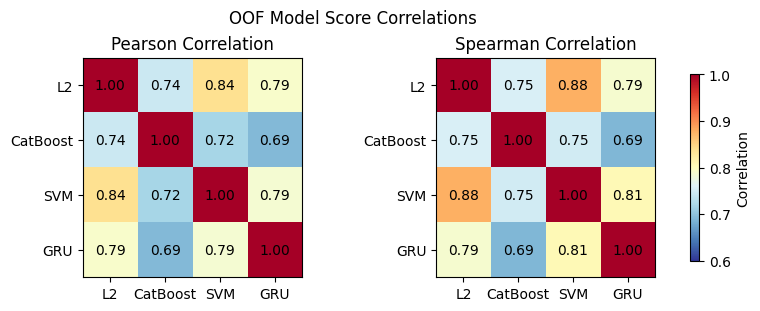

In [110]:
# Plot Pearson and Spearman correlations side by side

fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
for ax, title, matrix in zip(
    axes,
    ["Pearson Correlation", "Spearman Correlation"],
    [pearson_corr, spearman_corr]):
    image = ax.imshow(matrix, vmin=0.6, vmax=1.0, cmap="RdYlBu_r")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=axes, label="Correlation", shrink=0.85)
fig.suptitle("OOF Model Score Correlations")
plt.show()

All four models capture a common signal, but L2 and SVM are the most similar, with Pearson and Spearman correlations of 0.84 and 0.88. CatBoost and GRU are the least correlated and therefore provide greater potential diversification.

ii) Hard Prediction Disagreement Score

Hard-prediction disagreement measures how often models assign different classes at the selected threshold.

In [111]:
# Measure pairwise hard-prediction disagreement
hard_predictions = oof_wide[["timestamp", "fold", "target"]].copy()
hard_predictions["l2"] = (oof_wide["p_l2"] >= 0.50).astype(int)
hard_predictions["catboost"] = (oof_wide["p_catboost"] >= 0.50).astype(int)
hard_predictions["svm"] = (oof_wide["score_svm"] >= 0).astype(int)
hard_predictions["gru"] = (oof_wide["p_gru"] >= 0.50).astype(int)

model_names = ["l2", "catboost", "svm", "gru"]
disagreement_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for model_1 in model_names:
    for model_2 in model_names:
        disagreement_matrix.loc[model_1, model_2] = (hard_predictions[model_1] != hard_predictions[model_2]).mean()

disagreement_results = []

for i, model_1 in enumerate(model_names):
    for model_2 in model_names[i + 1:]:
        rate = disagreement_matrix.loc[model_1, model_2]
        disagreement_results.append({
            "model_1": model_1,
            "model_2": model_2,
            "disagreement_rate": rate,
            "agreement_rate": 1 - rate})

disagreement_results = pd.DataFrame(disagreement_results).sort_values("disagreement_rate", ascending=False).reset_index(drop=True)
disagreement_results.to_csv(DATA_PATH / "tuned_model_oof_disagreement_4h.csv", index=False)

print("Pairwise Hard-Prediction Disagreement")
display(disagreement_matrix.style.format("{:.3f}"))
print()
print("Ranked Model-Pair Disagreement")
display(disagreement_results.style.format({
    "disagreement_rate": "{:.2%}",
    "agreement_rate": "{:.2%}"}))

Pairwise Hard-Prediction Disagreement


,l2,catboost,svm,gru
l2,0.000,0.210,0.134,0.199
catboost,0.210,0.000,0.199,0.248
svm,0.134,0.199,0.000,0.186
gru,0.199,0.248,0.186,0.000



Ranked Model-Pair Disagreement


,model_1,model_2,disagreement_rate,agreement_rate
0,catboost,gru,24.77%,75.23%
1,l2,catboost,21.02%,78.98%
2,l2,gru,19.90%,80.10%
3,catboost,svm,19.90%,80.10%
4,svm,gru,18.59%,81.41%
5,l2,svm,13.44%,86.56%


The complementarity analysis supports retaining CatBoost, RBF SVM and GRU as the Level-0 base learners. SVM provides the strongest standalone OOF performance, while CatBoost exhibits lower score correlation with both SVM and GRU than the L2 benchmark. The CatBoost–GRU pair also records the highest hard-prediction disagreement at 24.77%, indicating useful structural diversity despite the GRU’s weaker individual performance. By contrast, L2 and SVM are highly correlated and disagree on only 13.44% of observations. The incremental value of the retained learners is therefore assessed formally within the supervised Level-1 stacking framework.

## **(VIII) Stacking Architecture and Model Lock**

### **Part I) Construct the Level-1 Meta-Feature Matrix**

The tuned out-of-fold predictions from the three retained Level-0 base learners—CatBoost, RBF SVM and GRU—are aligned to form the Level-1 meta-feature matrix. These models were carried forward because they offered the strongest combination of standalone performance and prediction diversity across tree-based, kernel and sequential architectures.

For each timestamp $t$, the Level-1 input is

$$
\mathbf{z}_t
=
\begin{bmatrix}
p_t^{\mathrm{CatBoost}} \\
s_t^{\mathrm{SVM}} \\
p_t^{\mathrm{GRU}}
\end{bmatrix},
$$

where $p_t^{\mathrm{CatBoost}}$ and $p_t^{\mathrm{GRU}}$ are predicted probabilities and $s_t^{\mathrm{SVM}}$ is the SVM decision score. After standardisation within the fitted pipeline, the Level-1 meta-model produces

$$
\widehat{p}_t
=
\sigma\left(
\beta_0
+
\beta_1\widetilde{p}_t^{\mathrm{CatBoost}}
+
\beta_2\widetilde{s}_t^{\mathrm{SVM}}
+
\beta_3\widetilde{p}_t^{\mathrm{GRU}}
\right),
$$

where

$$
\sigma(x)=\frac{1}{1+e^{-x}}.
$$

Each meta-feature was generated only for observations excluded from the corresponding base learner’s training fold. The aligned matrix therefore provides a training-only foundation for fitting and evaluating the supervised meta-model without using the untouched test set.

In [112]:
# Load the aligned base-model OOF predictions for Level-1 stacking
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

meta_oof = pd.read_csv(
    DATA_PATH / "tuned_model_oof_predictions_4h.csv",
    parse_dates=["timestamp"])

meta_oof["timestamp"] = pd.to_datetime(meta_oof["timestamp"], utc=True)

meta_cols = ["p_l2", "p_catboost", "score_svm", "p_gru"]
meta_oof = meta_oof[["timestamp", "fold", "target"] + meta_cols].sort_values(["fold", "timestamp"]).reset_index(drop=True)

meta_summary = pd.DataFrame({
    "observations": meta_oof[meta_cols].notna().sum(),
    "missing": meta_oof[meta_cols].isna().sum(),
    "minimum": meta_oof[meta_cols].min(),
    "maximum": meta_oof[meta_cols].max()})

print("Level-1 Meta-Feature Matrix")
print(f"Shape: {meta_oof.shape}")
print(f"Period: {meta_oof['timestamp'].min()} to {meta_oof['timestamp'].max()}")
print(f"OOF folds: {meta_oof['fold'].nunique()}")
print(f"Target positive rate: {meta_oof['target'].mean():.4f}")
display(meta_summary.round(4))

Level-1 Meta-Feature Matrix
Shape: (27070, 7)
Period: 2021-11-14 02:00:00+00:00 to 2025-03-12 08:00:00+00:00
OOF folds: 5
Target positive rate: 0.5067


,observations,missing,minimum,maximum
p_l2,27070,0,0.1296,0.9358
p_catboost,27070,0,0.3268,0.7075
score_svm,27070,0,-5.4120,8.3289
p_gru,27070,0,0.1440,0.8582


### **Part II) Chronological Cross-Fitting of the Meta-Model**

The three retained base learners—CatBoost, RBF SVM and GRU—produce different views of the same directional forecasting problem. CatBoost captures nonlinear threshold effects, the RBF SVM models smooth nonlinear boundaries and the GRU uses recent feature sequences to capture temporal dependence. Their aligned out-of-fold scores are therefore combined rather than relying on any single model.

An L2-regularised logistic regression is used as the Level-1 meta-model. This provides a simple and stable way to learn how much information each base learner contributes when their scores are considered together.

To evaluate the complete stack without breaking time order, the meta-model is cross-fitted chronologically. For each eligible fold, it is trained only on meta-features from earlier folds and then used to predict the next unseen fold. The resulting predictions are therefore out-of-sample for both the base learners and the meta-model, providing a fair training-period estimate of the stacked model’s performance.

In [113]:
# Cross-fit the logistic meta-model on expanding chronological OOF folds
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

meta_cols_stack = ["p_catboost", "score_svm", "p_gru"]
meta_folds = sorted(meta_oof["fold"].unique())
stack_frames, coefficient_rows = [], []

for test_fold in meta_folds[1:]:
    train = meta_oof[meta_oof["fold"] < test_fold]
    test = meta_oof[meta_oof["fold"] == test_fold]

    stacker = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=2000))])

    stacker.fit(train[meta_cols_stack], train["target"])
    score = stacker.predict_proba(test[meta_cols_stack])[:, 1]

    fold_result = test[["timestamp", "fold", "target"]].copy()
    fold_result["stack_score"] = score
    fold_result["stack_prediction"] = (score >= 0.50).astype(int)
    stack_frames.append(fold_result)

    coefficients = stacker.named_steps["model"].coef_[0]
    coefficient_rows.append({
        "fold": test_fold,
        **dict(zip(meta_cols_stack, coefficients))})

stack_oof = pd.concat(stack_frames, ignore_index=True)
stack_coefficients = pd.DataFrame(coefficient_rows)

stack_fold_rows = []

for fold in sorted(stack_oof["fold"].unique()):
    fold_data = stack_oof[stack_oof["fold"] == fold]

    stack_fold_rows.append({
        "fold": fold,
        "observations": len(fold_data),
        "roc_auc": roc_auc_score(
            fold_data["target"], fold_data["stack_score"]),
        "balanced_accuracy": balanced_accuracy_score(
            fold_data["target"], fold_data["stack_prediction"])})

stack_fold_metrics = pd.DataFrame(stack_fold_rows)

stack_oof.to_csv(DATA_PATH / "stacked_logistic_cat_svm_gru_oof_4h.csv", index=False)
stack_coefficients.to_csv(DATA_PATH / "stacked_logistic_cat_svm_gru_coefficients_4h.csv", index=False)

stack_fold_metrics.to_csv(DATA_PATH / "stacked_logistic_cat_svm_gru_fold_metrics_4h.csv", index=False)

print(f"Cross-fitted observations: {len(stack_oof):,}")
print(f"Mean fold ROC-AUC: {stack_fold_metrics['roc_auc'].mean():.4f}")
print(f"Mean fold balanced accuracy: {stack_fold_metrics['balanced_accuracy'].mean():.4f}")

display(stack_fold_metrics.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}"}))

display(stack_coefficients.round(4))

Cross-fitted observations: 21,656
Mean fold ROC-AUC: 0.5687
Mean fold balanced accuracy: 0.5406


,fold,observations,roc_auc,balanced_accuracy
0,2,5414,0.5644,0.5300
1,3,5414,0.5870,0.5511
2,4,5414,0.5677,0.5459
3,5,5414,0.5555,0.5356


,fold,p_catboost,score_svm,p_gru
0,2,0.0714,0.1274,-0.0125
1,3,0.0643,0.1300,0.0064
2,4,0.0946,0.1519,-0.0164
3,5,0.0993,0.1474,-0.0133


### **Part III) Meta-Coefficient Interpretation**

Because the Level-1 inputs are standardised within the pipeline, the fitted logistic coefficients can be compared across the three base learners. Their signs and relative magnitudes show how the meta-model combines CatBoost, RBF SVM and GRU within each chronological fold. These coefficients are not fixed ensemble weights; they represent the change in the Level-1 log-odds associated with a one-standard-deviation change in each base-model score.

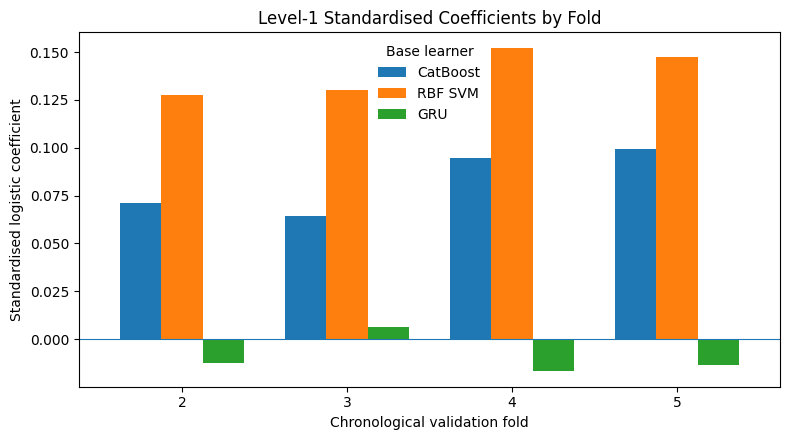

In [114]:
# Plot standardised Level-1 coefficients across chronological folds
import matplotlib.pyplot as plt

coef_plot = stack_coefficients.rename(columns={
    "p_catboost": "CatBoost",
    "score_svm": "RBF SVM",
    "p_gru": "GRU"}).set_index("fold")

ax = coef_plot.plot(kind="bar", figsize=(8, 4.5), width=0.75)

ax.axhline(0, linewidth=0.8)
ax.set_title("Level-1 Standardised Coefficients by Fold")
ax.set_xlabel("Chronological validation fold")
ax.set_ylabel("Standardised logistic coefficient")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Base learner", frameon=False)

plt.tight_layout()
plt.show()

The Level-1 coefficients are stable across chronological folds and assign the largest positive weight to the RBF SVM, with CatBoost providing a smaller but consistently positive contribution. The GRU coefficient remains close to zero and is slightly negative in most folds, indicating limited incremental information after controlling for the two tabular learners. Its retention is therefore determined by the formal CatBoost–SVM versus CatBoost–SVM–GRU comparison rather than standalone performance or coefficient sign alone.

### **Part IV) Benchmark Comparison**

The initial CatBoost–SVM–GRU stack assigns little incremental weight to the GRU, while L2 logistic regression provides stronger standalone stability but overlaps substantially with the SVM. The comparison is therefore extended to three supervised Level-1 specifications: CatBoost–SVM–GRU, CatBoost–SVM–L2 and a four-model stack containing all retained candidates.

These supervised stacks are compared with CatBoost standalone, an equal-weight four-model pool and a fixed 30% CatBoost–70% SVM benchmark. All candidates are evaluated on the same expanding chronological OOF folds. For the fixed-combination benchmarks, model scores are converted to empirical percentile ranks using only earlier OOF observations, preventing later score distributions from influencing earlier validation periods.

The comparison determines whether the GRU’s prediction diversity or L2’s stability provides useful conditional information after controlling for CatBoost and SVM. Selection is based on mean and minimum ROC-AUC, fold dispersion, balanced accuracy and model parsimony rather than on any single headline metric.

In [127]:
# Compare supervised stacks with point-in-time OOF benchmarks
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def empirical_percentile(values, reference):
    reference = np.sort(np.asarray(reference))
    return np.searchsorted(reference, np.asarray(values), side="right") / len(reference)

rank_sources = {
    "p_l2": "l2_rank",
    "p_catboost": "catboost_rank",
    "score_svm": "svm_rank",
    "p_gru": "gru_rank"}

stack_specs = {
    "CatBoost-SVM-GRU logistic stack": ["p_catboost", "score_svm", "p_gru"],
    "CatBoost-SVM-L2 logistic stack": ["p_catboost", "score_svm", "p_l2"],
    "Four-model logistic stack": ["p_l2", "p_catboost", "score_svm", "p_gru"]}

pti_frames = []

for test_fold in sorted(meta_oof["fold"].unique())[1:]:
    train = meta_oof[meta_oof["fold"] < test_fold]
    test = meta_oof[meta_oof["fold"] == test_fold].copy()

    for source, rank_col in rank_sources.items():
        test[rank_col] = empirical_percentile(test[source], train[source])

    for candidate, features in stack_specs.items():
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=1.0,
                penalty="l2",
                solver="lbfgs",
                max_iter=2000,
                random_state=42))])

        model.fit(train[features], train["target"])
        test[candidate] = model.predict_proba(test[features])[:, 1]

    pti_frames.append(test)

comparison_pti = pd.concat(pti_frames, ignore_index=True)
rank_cols = list(rank_sources.values())

comparison_pti["CatBoost standalone"] = comparison_pti["catboost_rank"]
comparison_pti["Equal four-model"] = comparison_pti[rank_cols].mean(axis=1)

comparison_pti["Fixed-weight CatBoost 30% + SVM 70%"] = (
    0.30 * comparison_pti["catboost_rank"] +
    0.70 * comparison_pti["svm_rank"])

candidate_cols = [
    "CatBoost-SVM-GRU logistic stack",
    "CatBoost-SVM-L2 logistic stack",
    "Four-model logistic stack",
    "Fixed-weight CatBoost 30% + SVM 70%",
    "Equal four-model",
    "CatBoost standalone"]

comparison_rows = []

for candidate in candidate_cols:
    for fold in sorted(comparison_pti["fold"].unique()):
        fold_data = comparison_pti[comparison_pti["fold"] == fold]
        score = fold_data[candidate]
        prediction = (score >= 0.50).astype(int)

        comparison_rows.append({
            "candidate": candidate,
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], score),
            "balanced_accuracy": balanced_accuracy_score(
                fold_data["target"], prediction)})

comparison_pti_folds = pd.DataFrame(comparison_rows)

comparison_pti_summary = comparison_pti_folds.groupby(
    "candidate", as_index=False).agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        min_roc_auc=("roc_auc", "min"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"))

pooled_rows = []

for candidate in candidate_cols:
    score = comparison_pti[candidate]
    prediction = (score >= 0.50).astype(int)

    pooled_rows.append({
        "candidate": candidate,
        "pooled_roc_auc": roc_auc_score(comparison_pti["target"], score),
        "pooled_balanced_accuracy": balanced_accuracy_score(
            comparison_pti["target"], prediction)})

comparison_pti_summary = comparison_pti_summary.merge(
    pd.DataFrame(pooled_rows), on="candidate", how="left")

comparison_pti_summary = comparison_pti_summary.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

comparison_pti_summary.insert(
    0, "rank", np.arange(1, len(comparison_pti_summary) + 1))

comparison_pti_folds.to_csv(
    DATA_PATH / "stacking_candidate_pti_folds_4h.csv", index=False)

comparison_pti_summary.to_csv(
    DATA_PATH / "stacking_candidate_pti_summary_4h.csv", index=False)

print("Point-in-Time OOF Benchmark Comparison")

display(comparison_pti_summary.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "min_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}",
    "min_balanced_accuracy": "{:.4f}",
    "pooled_roc_auc": "{:.4f}",
    "pooled_balanced_accuracy": "{:.4f}"}))

Point-in-Time OOF Benchmark Comparison


,rank,candidate,mean_roc_auc,std_roc_auc,min_roc_auc,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,pooled_roc_auc,pooled_balanced_accuracy
0,1,Fixed-weight CatBoost 30% + SVM 70%,0.5688,0.0133,0.5552,0.5431,0.0089,0.5341,0.5687,0.5447
1,2,CatBoost-SVM-GRU logistic stack,0.5687,0.0132,0.5555,0.5406,0.0096,0.5300,0.5678,0.5425
2,3,Equal four-model,0.5679,0.0113,0.5581,0.5405,0.0036,0.5355,0.5679,0.5421
3,4,CatBoost-SVM-L2 logistic stack,0.5671,0.0112,0.5567,0.5407,0.0073,0.5319,0.5664,0.5427
4,5,Four-model logistic stack,0.5660,0.0121,0.5548,0.5404,0.0095,0.5295,0.5655,0.5423
5,6,CatBoost standalone,0.5653,0.0168,0.5494,0.5405,0.0104,0.5259,0.5648,0.5416


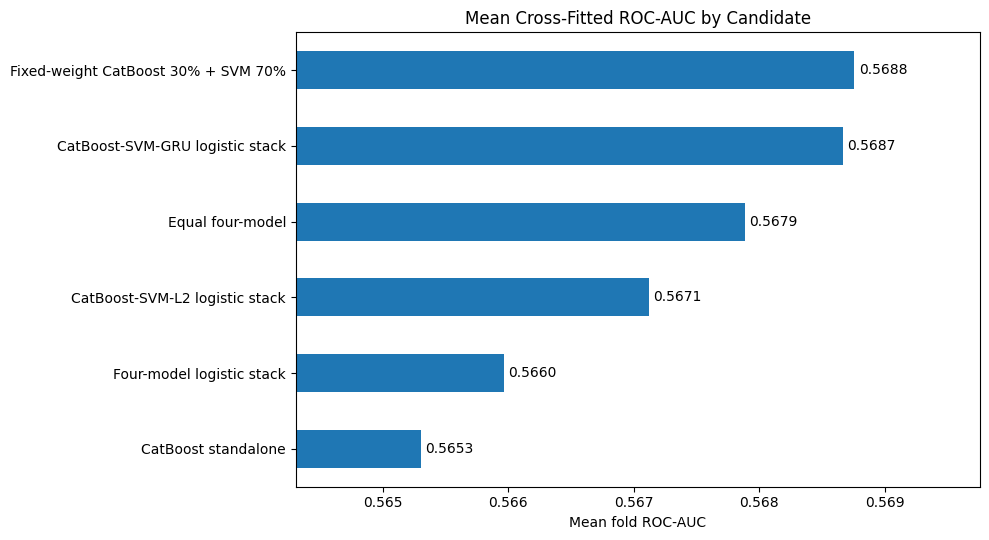

In [128]:
# Plot mean cross-fitted ROC-AUC by benchmark candidate
import matplotlib.pyplot as plt

benchmark_plot = comparison_pti_summary.sort_values("mean_roc_auc").copy()

ax = benchmark_plot.plot(
    x="candidate",
    y="mean_roc_auc",
    kind="barh",
    figsize=(10, 5.5),
    legend=False)

ax.set_title("Mean Cross-Fitted ROC-AUC by Candidate")
ax.set_xlabel("Mean fold ROC-AUC")
ax.set_ylabel("")
ax.set_xlim(
    benchmark_plot["mean_roc_auc"].min() - 0.001,
    benchmark_plot["mean_roc_auc"].max() + 0.001)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()

The fixed-weight CatBoost–SVM blend achieved the highest mean fold ROC-AUC at 0.5688 and the strongest mean balanced accuracy at 0.5431, narrowly ahead of the CatBoost–SVM–GRU logistic stack on ranking performance. The GRU-based supervised stack remained competitive at 0.5687 mean ROC-AUC, while replacing GRU with L2 reduced performance to 0.5671 and adding all four learners reduced it further to 0.5660. This indicates that L2’s standalone stability does not translate into useful conditional information once the SVM is included, consistent with their high prediction correlation. The equal four-model blend produced the lowest fold dispersion and strongest minimum ROC-AUC, but sacrificed average performance. Overall, CatBoost and SVM provide the core signal, with the GRU offering limited but more useful incremental diversity than L2.

### **Part V) Incremental Value of the GRU**

The retained CatBoost–SVM–GRU stack is compared directly with a reduced CatBoost–SVM logistic stack using identical expanding chronological folds and OOF timestamps. This isolates the incremental contribution of the GRU after the Level-1 model has re-estimated the optimal combination of the two stronger tabular learners. The comparison focuses on mean and minimum ROC-AUC, fold dispersion and balanced accuracy; the GRU is retained only if its additional sequence information improves ranking performance or temporal stability.

In [129]:
# Cross-fit CatBoost-SVM and assess the incremental value of GRU
meta_cols_cs = ["p_catboost", "score_svm"]
stack_cs_frames = []

for test_fold in meta_folds[1:]:
    train = meta_oof[meta_oof["fold"] < test_fold]
    test = meta_oof[meta_oof["fold"] == test_fold]

    stacker_cs = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=2000,
            random_state=42))])

    stacker_cs.fit(train[meta_cols_cs], train["target"])
    score = stacker_cs.predict_proba(test[meta_cols_cs])[:, 1]

    fold_result = test[["timestamp", "fold", "target"]].copy()
    fold_result["stack_cs_score"] = score
    stack_cs_frames.append(fold_result)

stack_cs_oof = pd.concat(stack_cs_frames, ignore_index=True)

gru_compare = stack_oof[["timestamp", "fold", "target", "stack_score"]].merge(
    stack_cs_oof[["timestamp", "fold", "stack_cs_score"]],
    on=["timestamp", "fold"],
    how="inner")

gru_candidates = {
    "CatBoost-SVM-GRU logistic stack": "stack_score",
    "CatBoost-SVM logistic stack": "stack_cs_score"}

gru_rows = []

for candidate, score_col in gru_candidates.items():
    for fold in sorted(gru_compare["fold"].unique()):
        fold_data = gru_compare[gru_compare["fold"] == fold]
        score = fold_data[score_col]
        prediction = (score >= 0.50).astype(int)

        gru_rows.append({
            "candidate": candidate,
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], score),
            "balanced_accuracy": balanced_accuracy_score(
                fold_data["target"], prediction)})

gru_fold_metrics = pd.DataFrame(gru_rows)

gru_summary = gru_fold_metrics.groupby(
    "candidate", as_index=False).agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        min_roc_auc=("roc_auc", "min"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"))

pooled_rows = []

for candidate, score_col in gru_candidates.items():
    score = gru_compare[score_col]
    prediction = (score >= 0.50).astype(int)

    pooled_rows.append({
        "candidate": candidate,
        "pooled_roc_auc": roc_auc_score(gru_compare["target"], score),
        "pooled_balanced_accuracy": balanced_accuracy_score(
            gru_compare["target"], prediction)})

gru_summary = gru_summary.merge(pd.DataFrame(pooled_rows), on="candidate", how="left")

gru_summary = gru_summary.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

gru_summary.insert(0, "rank", np.arange(1, len(gru_summary) + 1))

stack_cs_oof.to_csv(DATA_PATH / "stacked_logistic_cat_svm_oof_4h.csv", index=False)
gru_fold_metrics.to_csv(DATA_PATH / "stacking_gru_incremental_folds_4h.csv", index=False)
gru_summary.to_csv(DATA_PATH / "stacking_gru_incremental_summary_4h.csv", index=False)
print("Incremental Value of the GRU Meta-Feature")

display(gru_summary.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "min_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}",
    "min_balanced_accuracy": "{:.4f}",
    "pooled_roc_auc": "{:.4f}",
    "pooled_balanced_accuracy": "{:.4f}"}))

Incremental Value of the GRU Meta-Feature


,rank,candidate,mean_roc_auc,std_roc_auc,min_roc_auc,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,pooled_roc_auc,pooled_balanced_accuracy
0,1,CatBoost-SVM logistic stack,0.5690,0.0130,0.5565,0.5402,0.0092,0.5298,0.5680,0.5420
1,2,CatBoost-SVM-GRU logistic stack,0.5687,0.0132,0.5555,0.5406,0.0096,0.5300,0.5678,0.5425


Adding the GRU did not improve the supervised stack’s ranking performance. The reduced CatBoost–SVM logistic stack achieved a slightly higher mean ROC-AUC of 0.5690, a higher minimum ROC-AUC of 0.5565 and marginally lower fold dispersion than the three-model specification. The GRU produced only a small improvement in balanced accuracy, which was insufficient to offset its weaker and mostly negative Level-1 coefficients, lower parsimony and additional computational cost. The CatBoost–SVM logistic stack is therefore retained as the final supervised architecture.

### **Part VI) Fold-Level Incremental Value of the Selected Stack**

Because the aggregate differences between the reduced CatBoost–SVM stack and simpler alternatives are small, fold-level ROC-AUC uplifts are examined to determine whether its advantage is broadly distributed through time or concentrated in individual validation periods. Each candidate is evaluated on identical timestamps within each fold, allowing direct paired comparisons with CatBoost standalone, the fixed-weight CatBoost–SVM benchmark, the equal-weight four-model pool and the three-model CatBoost–SVM–GRU stack.

In [131]:
# Add the reduced CatBoost-SVM stack to the benchmark comparison
comparison_pti = comparison_pti.merge(stack_cs_oof[["timestamp", "fold", "stack_cs_score"]], on=["timestamp", "fold"], how="inner")
comparison_pti["CatBoost-SVM logistic stack"] = comparison_pti["stack_cs_score"]

In [132]:
# Compare paired fold-level ROC-AUC on identical OOF observations
paired_candidates = [
    "CatBoost-SVM logistic stack",
    "CatBoost-SVM-GRU logistic stack",
    "Fixed-weight CatBoost 30% + SVM 70%",
    "Equal four-model",
    "CatBoost standalone"]

paired_rows = []

for fold in sorted(comparison_pti["fold"].unique()):
    fold_data = comparison_pti[comparison_pti["fold"] == fold]
    row = {"fold": fold, "observations": len(fold_data)}

    for candidate in paired_candidates:
        key = candidate.lower().replace(" ", "_").replace("%", "pct")
        key = key.replace("-", "_").replace("+", "plus")
        row[f"{key}_auc"] = roc_auc_score(
            fold_data["target"], fold_data[candidate])

    paired_rows.append(row)

paired_fold_results = pd.DataFrame(paired_rows)

stack_auc = "catboost_svm_logistic_stack_auc"
gru_auc = "catboost_svm_gru_logistic_stack_auc"
fixed_auc = "fixed_weight_catboost_30pct_plus_svm_70pct_auc"
equal_auc = "equal_four_model_auc"
cat_auc = "catboost_standalone_auc"

paired_fold_results["uplift_vs_gru_stack"] = paired_fold_results[stack_auc] - paired_fold_results[gru_auc]
paired_fold_results["uplift_vs_fixed_weight"] = paired_fold_results[stack_auc] - paired_fold_results[fixed_auc]
paired_fold_results["uplift_vs_equal_weight"] = paired_fold_results[stack_auc] - paired_fold_results[equal_auc]
paired_fold_results["uplift_vs_catboost"] = paired_fold_results[stack_auc] - paired_fold_results[cat_auc]

comparisons = {
    "CatBoost-SVM stack vs GRU stack": "uplift_vs_gru_stack",
    "CatBoost-SVM stack vs fixed-weight blend": "uplift_vs_fixed_weight",
    "CatBoost-SVM stack vs equal-weight pool": "uplift_vs_equal_weight",
    "CatBoost-SVM stack vs CatBoost": "uplift_vs_catboost"}

paired_summary = pd.DataFrame([{
    "comparison": label,
    "mean_auc_uplift": paired_fold_results[column].mean(),
    "positive_auc_folds": (paired_fold_results[column] > 0).sum(),
    "minimum_auc_uplift": paired_fold_results[column].min()}
    for label, column in comparisons.items()])

paired_fold_results.to_csv(DATA_PATH / "stacking_paired_fold_uplift_4h.csv", index=False)
paired_summary.to_csv(DATA_PATH / "stacking_paired_uplift_summary_4h.csv", index=False)

display_cols = [
    "fold",
    "observations",
    stack_auc,
    gru_auc,
    fixed_auc,
    equal_auc,
    cat_auc,
    "uplift_vs_gru_stack",
    "uplift_vs_fixed_weight",
    "uplift_vs_equal_weight",
    "uplift_vs_catboost"]

print("Paired Fold-Level ROC-AUC Uplift")

display(paired_fold_results[display_cols].style.format({
    column: "{:+.4f}" if "uplift" in column else "{:.4f}"
    for column in display_cols
    if column not in ["fold", "observations"]}))

display(paired_summary.style.format({
    "mean_auc_uplift": "{:+.4f}",
    "minimum_auc_uplift": "{:+.4f}"}))

Paired Fold-Level ROC-AUC Uplift


,fold,observations,catboost_svm_logistic_stack_auc,catboost_svm_gru_logistic_stack_auc,fixed_weight_catboost_30pct_plus_svm_70pct_auc,equal_four_model_auc,catboost_standalone_auc,uplift_vs_gru_stack,uplift_vs_fixed_weight,uplift_vs_equal_weight,uplift_vs_catboost
0,2,5414,0.5644,0.5644,0.5659,0.5626,0.5494,-0.0001,-0.0015,+0.0018,+0.0150
1,3,5414,0.5872,0.5870,0.5871,0.5840,0.5875,+0.0002,+0.0001,+0.0032,-0.0004
2,4,5414,0.5681,0.5677,0.5668,0.5669,0.5683,+0.0004,+0.0013,+0.0012,-0.0002
3,5,5414,0.5565,0.5555,0.5552,0.5581,0.5560,+0.0009,+0.0013,-0.0016,+0.0005


,comparison,mean_auc_uplift,positive_auc_folds,minimum_auc_uplift
0,CatBoost-SVM stack vs GRU stack,+0.0004,3,-0.0001
1,CatBoost-SVM stack vs fixed-weight blend,+0.0003,3,-0.0015
2,CatBoost-SVM stack vs equal-weight pool,+0.0011,3,-0.0016
3,CatBoost-SVM stack vs CatBoost,+0.0037,2,-0.0004


The reduced CatBoost–SVM logistic stack outperformed the GRU-augmented stack in three of four chronological folds, with a mean ROC-AUC uplift of 0.0004. It also exceeded the fixed-weight CatBoost–SVM blend and the equal-weight four-model pool in three folds, although the average gains were small at 0.0003 and 0.0011 respectively. Relative to CatBoost alone, the stack delivered a larger mean uplift of 0.0037, but the improvement was concentrated in the earliest validation fold and was positive in only two of four folds. The evidence therefore supports the CatBoost–SVM stack as a modest and parsimonious improvement over the strongest standalone learner, while confirming that its advantage over simpler combination rules is limited rather than decisive.

### **Part VII) Final Meta-Model Fit, Benchmark Lock and Artifacts**

This section locks two pre-specified ensemble specifications before untouched-test evaluation. The primary CQF architecture is a supervised CatBoost–SVM–GRU stack with an L2-regularised logistic-regression meta-model, retaining three heterogeneous Level-0 learners in line with the project brief. A fixed 30% CatBoost–70% SVM blend is also locked as a parsimonious benchmark because it achieved the strongest mean OOF performance among the simple combination rules. Both specifications are carried forward unchanged to the test period; the supervised stack remains the primary project model, while the fixed blend provides a direct comparison between formal stacking and the simpler specification favoured by OOF performance.

### **Part VII .1) Lock the Primary CatBoost–SVM–GRU Stack**

**a) Load the Final Meta-Training Data**

In [119]:
# Load the aligned OOF predictions used to fit the final meta-model
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

meta_oof = pd.read_csv(DATA_PATH / "tuned_model_oof_predictions_4h.csv", parse_dates=["timestamp"])
meta_oof["timestamp"] = pd.to_datetime(meta_oof["timestamp"], utc=True)
meta_cols = ["p_catboost", "score_svm", "p_gru"]
meta_train = meta_oof[["timestamp", "fold", "target"] + meta_cols].dropna().sort_values("timestamp").reset_index(drop=True)

print(f"Final meta-training rows: {len(meta_train):,}")
print(f"Period: {meta_train['timestamp'].min()} " f"to {meta_train['timestamp'].max()}")
print(f"Meta-features: {meta_cols}")

Final meta-training rows: 27,070
Period: 2021-11-14 02:00:00+00:00 to 2025-03-12 08:00:00+00:00
Meta-features: ['p_catboost', 'score_svm', 'p_gru']


**b) Confirm the Final Stacking Architecture**

The primary CQF architecture combines CatBoost, RBF SVM and GRU as heterogeneous Level-0 learners with an L2-regularised logistic-regression meta-model at Level 1. Chronological OOF analysis showed that most of the conditional contribution comes from the SVM and CatBoost, while the GRU receives only a small positive coefficient in the final full-OOF fit and does not improve ranking performance relative to the reduced CatBoost–SVM stack. The three-learner specification is nevertheless retained as the formal project stack because it satisfies the required ensemble architecture and remains effectively tied with the strongest OOF alternatives. Its role is therefore interpreted as the primary exam-compliant model rather than the uniquely best-performing specification.

**c) Fit the Final Level-1 Meta-Model**

The final L2-regularised logistic-regression meta-model is fitted on all aligned OOF predictions from CatBoost, RBF SVM and GRU. Because each meta-feature was generated only for observations excluded from the corresponding base learner’s training fold, the Level-1 model remains separated from the Level-0 fitting process.

The resulting full-OOF metrics are descriptive measures of the final fitted meta-model. The chronological cross-fitted results reported earlier remain the basis for model selection and performance assessment.

In [120]:
# Fit the final Level-1 meta-model on all aligned OOF predictions
from joblib import dump

final_stacker = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=2000))])

final_stacker.fit(meta_train[meta_cols], meta_train["target"])

meta_train["stack_score"] = final_stacker.predict_proba(meta_train[meta_cols])[:, 1]
meta_train["stack_prediction"] = (meta_train["stack_score"] >= 0.50).astype(int)

final_meta_auc = roc_auc_score(meta_train["target"], meta_train["stack_score"])
final_meta_ba = balanced_accuracy_score(meta_train["target"], meta_train["stack_prediction"])

final_coefficients = pd.DataFrame({"meta_feature": meta_cols, "coefficient": final_stacker.named_steps["model"].coef_[0]})

dump(final_stacker, DATA_PATH / "final_cat_svm_gru_stacker_4h.joblib")
meta_train.to_csv(DATA_PATH / "final_stacker_training_oof_4h.csv", index=False)
final_coefficients.to_csv(DATA_PATH / "final_stacker_coefficients_4h.csv", index=False)

print(f"Final meta-training rows: {len(meta_train):,}")
print(f"Descriptive full-OOF ROC-AUC: {final_meta_auc:.4f}")
print(f"Descriptive full-OOF balanced accuracy: {final_meta_ba:.4f}")

display(final_coefficients.round(4))

Final meta-training rows: 27,070
Descriptive full-OOF ROC-AUC: 0.5610
Descriptive full-OOF balanced accuracy: 0.5434


,meta_feature,coefficient
0,p_catboost,0.0922
1,score_svm,0.1286
2,p_gru,0.0140


**d) Fit and Save the Final Level-0 Base Learners**

The tuned CatBoost, RBF SVM and GRU base learners are refitted on the complete locked training sample and saved for unchanged application to the untouched test period. CatBoost is stored in its native model format, the SVM is saved as a complete robust-scaling pipeline, and the GRU model, scaler and sequence specification are saved separately. This preserves the exact Level-0 configuration used by the final stacking model and avoids any refitting or preprocessing changes during test evaluation.

In [133]:
# Fit and save the final tuned CatBoost and SVM base learners
from joblib import dump
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

final_catboost = CatBoostClassifier(
    depth=CAT_DEPTH,
    learning_rate=CAT_LR,
    l2_leaf_reg=CAT_L2,
    iterations=CAT_ITERATIONS,
    loss_function="Logloss",
    random_seed=42,
    verbose=False)

final_catboost.fit(X_model, y_model)
final_catboost.save_model(str(DATA_PATH / "final_catboost_model_4h.cbm"))

final_svm = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVC(C=SVM_C, gamma=SVM_GAMMA, kernel="rbf"))])

final_svm.fit(X_model, y_model)
dump(final_svm, DATA_PATH / "final_svm_model_4h.joblib")

print("Final CatBoost and SVM artifacts saved")

Final CatBoost and SVM artifacts saved


In [134]:
# Fit and save the final tuned GRU on the complete training sample
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

X_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
y_gru = pd.read_csv(DATA_PATH / "y_train_model_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()["target_4h"]
selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
y_gru.index = pd.to_datetime(y_gru.index, utc=True)
X_hourly = X_hourly[selected_features].astype("float32")

gru_best = pd.read_csv(DATA_PATH / "gru_tuning_results_4h.csv").sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

GRU_LOOKBACK, GRU_BATCH_SIZE = 24, 256
GRU_UNITS, GRU_EPOCHS = int(gru_best["units"]), int(gru_best["epochs"])
GRU_DROPOUT, GRU_LR = float(gru_best["dropout"]), float(gru_best["learning_rate"])

gru_endpoints = y_gru.index.intersection(X_hourly.index)
gru_endpoints = gru_endpoints[gru_endpoints >= X_hourly.index[GRU_LOOKBACK - 1]]

final_gru_scaler = StandardScaler()
X_gru_scaled = pd.DataFrame(final_gru_scaler.fit_transform(X_hourly), index=X_hourly.index, columns=selected_features)

positions = X_gru_scaled.index.get_indexer(gru_endpoints)
X_gru_train = np.asarray([X_gru_scaled.iloc[i - GRU_LOOKBACK + 1:i + 1].to_numpy() for i in positions], dtype=np.float32)
y_gru_train = y_gru.loc[gru_endpoints].to_numpy()

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

final_gru = Sequential([Input(shape=(GRU_LOOKBACK, len(selected_features))), GRU(GRU_UNITS), Dropout(GRU_DROPOUT), Dense(1, activation="sigmoid")])
final_gru.compile(optimizer=Adam(GRU_LR), loss="binary_crossentropy")
final_gru.fit(X_gru_train, y_gru_train, epochs=GRU_EPOCHS, batch_size=GRU_BATCH_SIZE, shuffle=False, verbose=0)

final_gru.save(DATA_PATH / "final_gru_model_4h.keras")
dump(final_gru_scaler, DATA_PATH / "final_gru_scaler_4h.joblib")

gru_specification = {
    "lookback_hours": GRU_LOOKBACK,
    "features": selected_features,
    "units": GRU_UNITS,
    "dropout": GRU_DROPOUT,
    "learning_rate": GRU_LR,
    "epochs": GRU_EPOCHS,
    "batch_size": GRU_BATCH_SIZE,
    "shuffle": False,
    "training_sequences": len(X_gru_train),
    "model_file": "final_gru_model_4h.keras",
    "scaler_file": "final_gru_scaler_4h.joblib"}

with open(DATA_PATH / "final_gru_specification_4h.json", "w") as file:
    json.dump(gru_specification, file, indent=2)

print(f"GRU training sequences: {len(X_gru_train):,}")
print(f"Sequence shape: {X_gru_train.shape}")
print(f"Units: {GRU_UNITS} | Dropout: {GRU_DROPOUT:g}")
print(f"Learning rate: {GRU_LR:g} | Epochs: {GRU_EPOCHS}")
print("Final GRU model, scaler and specification saved")

GRU training sequences: 37,898
Sequence shape: (37898, 24, 30)
Units: 64 | Dropout: 0
Learning rate: 0.0003 | Epochs: 12
Final GRU model, scaler and specification saved


**e) Save the Final Stacking Specification**


The JSON specification records the locked base learners, meta-feature order, Level-1 settings, fitted coefficients and key OOF evidence. The fitted pipeline remains stored separately as a joblib file for untouched test inference.

In [136]:
# Save the final stacking specification and artifact references
spec_path = DATA_PATH / "final_stacking_specification_4h.json"

stack_specification = {
    "level_0_models": ["CatBoost", "RBF SVM", "GRU"],
    "level_0_artifacts": {
        "catboost": "final_catboost_model_4h.cbm",
        "svm": "final_svm_model_4h.joblib",
        "gru_model": "final_gru_model_4h.keras",
        "gru_scaler": "final_gru_scaler_4h.joblib",
        "gru_specification": "final_gru_specification_4h.json"},
    "stacker_file": "final_cat_svm_gru_stacker_4h.joblib",
    "selected_features_file": "elastic_net_selected_features_30_4h.csv",
    "classification_threshold": 0.50,
    "target_dead_zone": 0.0005,
    "meta_training_rows": len(meta_train),
    "meta_features": meta_cols,
    "cross_fitted_mean_auc": float(stack_fold_metrics["roc_auc"].mean()),
    "cross_fitted_mean_balanced_accuracy": float(
        stack_fold_metrics["balanced_accuracy"].mean())}

with open(spec_path, "w") as file:
    json.dump(stack_specification, file, indent=2)

print("Final stacking specification saved")
print(f"Level-0 models: {', '.join(stack_specification['level_0_models'])}")
print(f"Meta-training rows: {stack_specification['meta_training_rows']:,}")
print(f"Cross-fitted mean ROC-AUC: {stack_specification['cross_fitted_mean_auc']:.4f}")
print(f"Cross-fitted mean balanced accuracy: {stack_specification['cross_fitted_mean_balanced_accuracy']:.4f}")
print(f"Saved: {spec_path}")

Final stacking specification saved
Level-0 models: CatBoost, RBF SVM, GRU
Meta-training rows: 27,070
Cross-fitted mean ROC-AUC: 0.5687
Cross-fitted mean balanced accuracy: 0.5406
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/final_stacking_specification_4h.json


**f) Final Artifact Lock Summary**



The final inference pipeline is now locked. It contains the three fitted Level-0 base learners, the GRU scaler and sequence specification, the Level-1 logistic-regression pipeline and the readable stacking specification. No model is refitted or altered after this point.

In [137]:
# Display and verify the locked inference artifacts
locked_artifacts = {
    "CatBoost model": stack_specification["level_0_artifacts"]["catboost"],
    "SVM pipeline": stack_specification["level_0_artifacts"]["svm"],
    "GRU model": stack_specification["level_0_artifacts"]["gru_model"],
    "GRU scaler": stack_specification["level_0_artifacts"]["gru_scaler"],
    "GRU specification": stack_specification["level_0_artifacts"]["gru_specification"],
    "Level-1 stacker": stack_specification["stacker_file"],
    "Stacking specification": spec_path.name}

artifact_table = pd.DataFrame({
    "file": locked_artifacts,
    "exists": {name: (DATA_PATH / file).exists() for name, file in locked_artifacts.items()}})

display(artifact_table)

,file,exists
CatBoost model,final_catboost_model_4h.cbm,True
SVM pipeline,final_svm_model_4h.joblib,True
GRU model,final_gru_model_4h.keras,True
GRU scaler,final_gru_scaler_4h.joblib,True
GRU specification,final_gru_specification_4h.json,True
Level-1 stacker,final_cat_svm_gru_stacker_4h.joblib,True
Stacking specification,final_stacking_specification_4h.json,True


### **Part VII.2) Lock the Fixed 30% CatBoost–70% SVM Benchmark**

The fixed 30% CatBoost–70% SVM blend is locked as the strongest parsimonious benchmark identified through point-in-time OOF analysis. Because CatBoost probabilities and SVM decision scores are measured on different scales, each score is converted to an empirical percentile rank using the training OOF distribution before the fixed weights are applied. The specification is saved before untouched-test evaluation and is carried forward unchanged as a benchmark to the primary supervised stack.

#### **a) Define the Locked Benchmark**

In [138]:
# Define the locked fixed-weight benchmark
benchmark_weights = {"catboost": 0.30, "svm": 0.70}
benchmark_models = ["CatBoost", "RBF SVM"]
benchmark_name = "Fixed 30% CatBoost + 70% SVM"
benchmark_threshold = 0.50

print(f"Benchmark: {benchmark_name}")
print(f"Weights: CatBoost={benchmark_weights['catboost']:.0%}, SVM={benchmark_weights['svm']:.0%}")
print(f"Classification threshold: {benchmark_threshold:.2f}")

Benchmark: Fixed 30% CatBoost + 70% SVM
Weights: CatBoost=30%, SVM=70%
Classification threshold: 0.50


#### **b) Specify Point-in-Time Score Transformation**

CatBoost probabilities and SVM decision scores are not directly comparable because they use different scales. Their aligned training OOF scores are therefore saved as frozen empirical reference distributions. During untouched-test inference, each test score is mapped to its percentile within the corresponding training OOF distribution before applying the fixed 30%–70% weights. No test observations enter the transformation.

In [171]:
# Save frozen component and combined benchmark OOF-score references
catboost_reference = np.sort(meta_oof["p_catboost"].to_numpy())
svm_reference = np.sort(meta_oof["score_svm"].to_numpy())

catboost_oof_rank = empirical_percentile(meta_oof["p_catboost"], catboost_reference)
svm_oof_rank = empirical_percentile(meta_oof["score_svm"], svm_reference)

benchmark_oof_score = (
    benchmark_weights["catboost"] * catboost_oof_rank +
    benchmark_weights["svm"] * svm_oof_rank)

benchmark_reference = pd.DataFrame({
    "catboost_reference": catboost_reference,
    "svm_reference": svm_reference,
    "benchmark_score_reference": np.sort(benchmark_oof_score)})

reference_path = DATA_PATH / "fixed_cat_svm_oof_references_4h.csv"
benchmark_reference.to_csv(reference_path, index=False)

print(f"Reference observations: {len(benchmark_reference):,}")
print(f"Saved: {reference_path}")

Reference observations: 27,070
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/fixed_cat_svm_oof_references_4h.csv


#### **c) Save the Benchmark Specification**

The locked specification records the fixed weights, frozen percentile-reference file, shared Level-0 artifacts, selected-feature file, classification threshold and target dead zone. The benchmark uses the same fitted CatBoost and SVM models as the primary stack and introduces no additional model fitting.

In [140]:
# Save the fixed CatBoost-SVM benchmark specification
benchmark_spec_path = DATA_PATH / "fixed_cat_svm_benchmark_specification_4h.json"

benchmark_specification = {
    "name": benchmark_name,
    "models": benchmark_models,
    "weights": benchmark_weights,
    "artifacts": {
        "catboost": "final_catboost_model_4h.cbm",
        "svm": "final_svm_model_4h.joblib"},
    "score_reference_file": reference_path.name,
    "selected_features_file": "elastic_net_selected_features_30_4h.csv",
    "classification_threshold": benchmark_threshold,
    "target_dead_zone": 0.0005,
    "oof_mean_roc_auc": 0.5688,
    "oof_mean_balanced_accuracy": 0.5431}

with open(benchmark_spec_path, "w") as file:
    json.dump(benchmark_specification, file, indent=2)

print(f"Saved: {benchmark_spec_path}")

Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/fixed_cat_svm_benchmark_specification_4h.json


#### **d) Verify Locked Benchmark Artifacts**

The final audit lists the files required for benchmark inference and confirms that the saved specification points to the shared fitted models and frozen OOF score references.

In [141]:
# Display and verify locked benchmark artifacts
benchmark_artifacts = {
    "CatBoost model": benchmark_specification["artifacts"]["catboost"],
    "SVM pipeline": benchmark_specification["artifacts"]["svm"],
    "OOF score references": benchmark_specification["score_reference_file"],
    "Selected features": benchmark_specification["selected_features_file"],
    "Benchmark specification": benchmark_spec_path.name}

benchmark_artifact_table = pd.DataFrame({
    "file": benchmark_artifacts,
    "exists": {name: (DATA_PATH / file).exists() for name, file in benchmark_artifacts.items()}})

display(benchmark_artifact_table)

,file,exists
CatBoost model,final_catboost_model_4h.cbm,True
SVM pipeline,final_svm_model_4h.joblib,True
OOF score references,fixed_cat_svm_oof_references_4h.csv,True
Selected features,elastic_net_selected_features_30_4h.csv,True
Benchmark specification,fixed_cat_svm_benchmark_specification_4h.json,True


## **(IX) Model Testing**

The untouched test feature matrix is reconstructed using a 5,100-hour historical warm-up window drawn from the continuous point-in-time-aligned source data. This provides sufficient context for all retained rolling and recursively estimated features, including the 5,040-hour EGARCH requirement. Features are calculated using only information available at or before each timestamp, after which only the original test timestamps are retained.

This preserves the full untouched test sample while reproducing the information set that would have been available in real time.

**a) Loading Test Data, Audit and Test Pipeline Construction**

**i) Load Test Data and Locked Artifacts**

In [124]:
# Imports for locked model loading
import json
from pathlib import Path

import pandas as pd
from catboost import CatBoostClassifier
from joblib import load
from tensorflow.keras.models import load_model

In [142]:
# Load untouched test data and locked ensemble artifacts
from joblib import load
from tensorflow.keras.models import load_model

DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train_raw = pd.read_csv(DATA_PATH / "X_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_test_raw = pd.read_csv(DATA_PATH / "X_test_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
X_train_engineered = pd.read_csv(DATA_PATH / "X_train_engineered_v2.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
targets_test = pd.read_csv(DATA_PATH / "targets_test_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

with open(DATA_PATH / "final_stacking_specification_4h.json") as file:
    stack_spec = json.load(file)

with open(DATA_PATH / "fixed_cat_svm_benchmark_specification_4h.json") as file:
    benchmark_spec = json.load(file)

artifacts = stack_spec["level_0_artifacts"]

with open(DATA_PATH / artifacts["gru_specification"]) as file:
    gru_spec = json.load(file)

benchmark_reference = pd.read_csv(DATA_PATH / benchmark_spec["score_reference_file"])

final_catboost = CatBoostClassifier()
final_catboost.load_model(str(DATA_PATH / artifacts["catboost"]))
final_svm = load(DATA_PATH / artifacts["svm"])
final_gru = load_model(DATA_PATH / artifacts["gru_model"])
final_gru_scaler = load(DATA_PATH / artifacts["gru_scaler"])
final_stacker = load(DATA_PATH / stack_spec["stacker_file"])

for df in [X_train_raw, X_test_raw, X_train_engineered, targets_test]:
    df.index = pd.to_datetime(df.index, utc=True)

summary = pd.Series({
    "raw_train_rows": len(X_train_raw),
    "raw_test_rows": len(X_test_raw),
    "engineered_train_rows": len(X_train_engineered),
    "test_target_rows": len(targets_test),
    "locked_features": len(selected_features),
    "primary_models": ", ".join(stack_spec["level_0_models"]),
    "benchmark": benchmark_spec["name"],
    "benchmark_reference_rows": len(benchmark_reference),
    "classification_threshold": stack_spec["classification_threshold"],
    "target_dead_zone": stack_spec["target_dead_zone"]})

display(summary.to_frame("value"))

,value
raw_train_rows,45537
raw_test_rows,11391
engineered_train_rows,40497
test_target_rows,11391
locked_features,30
primary_models,"CatBoost, RBF SVM, GRU"
benchmark,Fixed 30% CatBoost + 70% SVM
benchmark_reference_rows,27070
classification_threshold,0.5000
target_dead_zone,0.0005


**ii) Historical-Context Test Feature Construction**

A 5,100-hour pre-test history window is loaded from the continuous point-in-time-aligned source data. This provides sufficient warm-up for all retained rolling and recursively estimated features, including the longest EGARCH requirement, without shortening the untouched test sample. The original test timestamps remain unchanged, and the 24-hour purge continues to separate the training and test partitions. The corresponding Deribit contract panel is restricted to the same historical-context period.

In [143]:
# Load continuous PIT-aware history for test feature construction
RAW_PATH = DATA_PATH.parent / "raw_data"
warmup_bars = 5100

test_start = X_test_raw.index.min()
test_end = X_test_raw.index.max()
context_start = test_start - pd.Timedelta(hours=warmup_bars)

X_test_context = pd.read_csv(
    RAW_PATH / "df_merged_1h_pit_aligned.csv",
    parse_dates=["timestamp"]).set_index("timestamp")

X_test_context.index = pd.to_datetime(X_test_context.index, utc=True)
X_test_context = X_test_context.loc[context_start:test_end, X_test_raw.columns].sort_index()

deribit_test_context = pd.read_csv(
    RAW_PATH / "deribit_btc_futures_pit_aligned.csv",
    parse_dates=["timestamp", "expiration_timestamp"])

deribit_test_context["timestamp"] = pd.to_datetime(deribit_test_context["timestamp"], utc=True)
deribit_test_context["expiration_timestamp"] = pd.to_datetime(
    deribit_test_context["expiration_timestamp"], utc=True, errors="coerce")

deribit_test_context = deribit_test_context[deribit_test_context["timestamp"].between(context_start, test_end)].sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

expected_index = pd.date_range(context_start, test_end, freq="h", tz="UTC")

summary = pd.Series({
    "context_start": X_test_context.index.min(),
    "test_start": test_start,
    "warmup_rows": (X_test_context.index < test_start).sum(),
    "test_rows": (X_test_context.index >= test_start).sum(),
    "missing_hours": len(expected_index.difference(X_test_context.index)),
    "deribit_rows": len(deribit_test_context)})

display(summary.to_frame("value"))

,value
context_start,2024-08-12 21:00:00+00:00
test_start,2025-03-13 09:00:00+00:00
warmup_rows,5100
test_rows,11391
missing_hours,0
deribit_rows,82463


**iii) Define Locked Feature-Construction Functions**

The following functions reproduce only the 30 locked predictors using the same trailing-window, point-in-time-aware transformations applied during training.

In [145]:
# Define the locked 30-feature construction pipeline
from arch import arch_model

def rolling_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = ((x - x_mean) ** 2).sum()

    sum_y = log_price.rolling(window).sum()
    sum_y2 = log_price.pow(2).rolling(window).sum()
    sum_xy = log_price.rolling(window).apply(lambda y: y @ x, raw=True)

    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt(residual_ss / (window - 2) / sxx)
    tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)

    return slope, tstat, r2


def estimate_hurst(returns):
    scales = np.array([1, 2, 4, 8, 12, 24])
    log_scales, log_vars = [], []

    for scale in scales:
        usable = len(returns) // scale * scale
        aggregated = returns[-usable:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated, ddof=1)

        if np.isfinite(variance) and variance > 0:
            log_scales.append(np.log(scale))
            log_vars.append(np.log(variance))

    return np.polyfit(log_scales, log_vars, 1)[0] / 2 if len(log_scales) >= 3 else np.nan

def build_btc_trend(X):
    features = pd.DataFrame(index=X.index)
    log_price = np.log(pd.to_numeric(X["btc_close"], errors="coerce"))
    ret_4h = log_price.diff(4)

    slope_4h, _, _ = rolling_regression(log_price, 4)
    slope_8h, tstat_8h, r2_8h = rolling_regression(log_price, 8)
    slope_24h, tstat_24h, r2_24h = rolling_regression(log_price, 24)

    features["btc_logprice_slope_24h"] = slope_24h
    features["btc_slope_tstat_8h"] = tstat_8h
    features["btc_logprice_slope_8h"] = slope_8h
    features["btc_ret_24h"] = log_price.diff(24)
    features["btc_return_acceleration_4h"] = ret_4h - ret_4h.shift(4)
    features["btc_trend_r2_8h"] = r2_8h
    features["btc_trend_r2_24h"] = r2_24h
    features["btc_slope_tstat_24h"] = tstat_24h
    features["btc_logprice_slope_4h"] = slope_4h

    return features


def build_btc_volatility(X):
    features = pd.DataFrame(index=X.index)
    close = pd.to_numeric(X["btc_close"], errors="coerce")
    returns = np.log(close).diff()
    squared = returns.pow(2)
    downside = returns.clip(upper=0).pow(2)

    rv_4h = np.sqrt(squared.rolling(4).sum())
    features["btc_drawdown_24h"] = close / close.rolling(24).max() - 1
    features["btc_vol_of_vol_24h"] = rv_4h.rolling(24).std()
    features["btc_downside_variance_share_8h"] = downside.rolling(8).sum() / squared.rolling(8).sum().replace(0, np.nan)
    features["btc_rv_24h"] = np.sqrt(squared.rolling(24).sum())

    hurst = pd.Series(np.nan, index=X.index)

    for position in range(168, len(X), 24):
        sample = returns.iloc[position - 167:position + 1]

        if sample.notna().sum() == 168:
            hurst.iloc[position] = estimate_hurst(sample.to_numpy())

    features["btc_hurst_168h"] = hurst.ffill()

    egarch_returns = 100 * returns
    egarch_vol = pd.Series(np.nan, index=X.index)

    for position in range(4320, len(X), 24):
        start = position - 4319
        end = min(position + 24, len(X))
        estimation = egarch_returns.iloc[start:position + 1].dropna()
        filtering = egarch_returns.iloc[start:end].dropna()

        if len(estimation) != 4320:
            continue

        model = arch_model(estimation, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
        fitted = model.fit(disp="off", show_warning=False)

        filter_model = arch_model(filtering, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
        filtered = filter_model.fix(fitted.params)
        segment_index = X.index[position:end]

        egarch_vol.loc[segment_index] = filtered.conditional_volatility.reindex(segment_index) / 100

    regime_mean = egarch_vol.rolling(720).mean().shift()
    regime_std = egarch_vol.rolling(720).std().shift()
    features["btc_egarch_vol_regime"] = (egarch_vol - regime_mean) / regime_std.replace(0, np.nan)

    return features

def build_market_features(X):
    features = pd.DataFrame(index=X.index)

    eth_log = np.log(pd.to_numeric(X["eth_close"], errors="coerce").where(lambda x: x > 0))
    features["eth_logprice_slope_24h"] = rolling_regression(eth_log, 24)[0]

    oi = pd.to_numeric(X["oi_perp"], errors="coerce")
    leverage = pd.to_numeric(X["leverage_ratio"], errors="coerce")
    oi_log = np.log(oi.where(oi > 0))
    leverage_log = np.log(leverage.where(leverage > 0))

    features["oi_log_roc_4h"] = oi_log.diff(4)
    features["oi_log_roc_24h"] = oi_log.diff(24)
    features["oi_slope_8h"] = rolling_regression(oi_log, 8)[0]
    features["leverage_log_roc_4h"] = leverage_log.diff(4)
    features["leverage_log_roc_24h"] = leverage_log.diff(24)
    features["leverage_slope_8h"] = rolling_regression(leverage_log, 8)[0]

    premium = pd.to_numeric(X["btc_perp_premium_close"], errors="coerce")
    premium_mean = premium.rolling(168).mean()
    premium_std = premium.rolling(168).std()

    features["premium_zscore_168h"] = ((premium - premium_mean) / premium_std.replace(0, np.nan))

    coinbase = pd.to_numeric(X["coinbase_btc_close"], errors="coerce")
    btc = pd.to_numeric(X["btc_close"], errors="coerce")
    spread = coinbase / btc - 1
    spread_mean = spread.rolling(168).mean()
    spread_std = spread.rolling(168).std()

    features["coinbase_binance_spread_zscore_168h"] = ((spread - spread_mean) / spread_std.replace(0, np.nan))

    return features

def build_onchain_macro_calendar(X):
    features = pd.DataFrame(index=X.index)
    exchange_col = "exchange_net_position_change"

    if exchange_col not in X:
        exchange_col = "exch_net_pos_chg"

    mvrv = pd.to_numeric(X["mvrv_z"], errors="coerce").ffill()
    sth_mvrv = pd.to_numeric(X["sth_mvrv"], errors="coerce").ffill()
    lth_mvrv = pd.to_numeric(X["lth_mvrv"], errors="coerce").ffill()
    supply_profit = pd.to_numeric(X["pct_supply_profit"], errors="coerce").ffill()
    exchange_position = pd.to_numeric(X[exchange_col], errors="coerce").fillna(0)

    mvrv_mean = mvrv.rolling(168).mean()
    mvrv_std = mvrv.rolling(168).std()

    features["sth_lth_mvrv_spread"] = sth_mvrv - lth_mvrv
    features["pct_supply_profit_change_24h"] = supply_profit.diff(24)
    features["mvrv_zscore_168h"] = ((mvrv - mvrv_mean) / mvrv_std.replace(0, np.nan))

    features["exchange_net_position_signed_log"] = (np.sign(exchange_position) * np.log1p(exchange_position.abs()))

    dxy = pd.to_numeric(X["dxy"], errors="coerce").ffill()
    us10y = pd.to_numeric(X["us10y"], errors="coerce").ffill()

    features["dxy_ret_1d"] = np.log(dxy.where(dxy > 0)).diff(24)
    features["us10y_change_bps_1d"] = us10y.diff(24) * 10
    features["cal_hour_cos"] = np.cos(2 * np.pi * X.index.hour / 24)

    return features

def build_deribit_features(X, panel):
    deribit = panel.copy()
    btc_close = pd.to_numeric(X["btc_close"], errors="coerce")

    deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)
    deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
    deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)
    deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
    deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400
    deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
    deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

    dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
    dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])
    dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

    front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X.index)
    second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X.index)
    notional = deribit.groupby("timestamp")["cost"].sum().reindex(X.index).fillna(0)

    features = pd.DataFrame(index=X.index)
    features["deribit_front_days_to_expiry"] = front["days_to_expiry"]
    features["deribit_total_log_notional"] = np.log1p(notional)
    features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]

    return features

def build_locked_30_features(X, deribit_panel, feature_names):
    trend = build_btc_trend(X)
    volatility = build_btc_volatility(X)
    market = build_market_features(X)
    external = build_onchain_macro_calendar(X)
    deribit = build_deribit_features(X, deribit_panel)

    interactions = pd.DataFrame(index=X.index)
    interactions["btc_slope_4h_x_hurst_centered"] = trend["btc_logprice_slope_4h"] * (volatility["btc_hurst_168h"] - 0.5)
    interactions["btc_slope_tstat_8h_x_egarch_regime"] = trend["btc_slope_tstat_8h"] * volatility["btc_egarch_vol_regime"]

    features = pd.concat([trend, volatility, market, external, deribit, interactions], axis=1)
    return features[feature_names].replace([np.inf, -np.inf], np.nan)

**iv) Construct and Save the Test Feature Matrix**

The locked features are constructed over the full historical context and then restricted to the original untouched test timestamps.

In [146]:
# Construct the locked test feature matrix
X_test_features_context = build_locked_30_features(
    X_test_context,
    deribit_test_context,
    selected_features)

X_test_engineered = X_test_features_context.reindex(X_test_raw.index)
missing_values = int(X_test_engineered.isna().sum().sum())
infinite_values = int(np.isinf(X_test_engineered.to_numpy()).sum())

summary = pd.Series({
    "context_rows": len(X_test_features_context),
    "test_rows": len(X_test_engineered),
    "locked_features": X_test_engineered.shape[1],
    "missing_values": missing_values,
    "infinite_values": infinite_values,
    "timestamp_alignment": X_test_engineered.index.equals(X_test_raw.index),
    "feature_order": X_test_engineered.columns.tolist() == selected_features})

display(summary.to_frame("value"))

X_test_engineered.reset_index().to_csv(
    DATA_PATH / "X_test_engineered_30_4h.csv",
    index=False)

,value
context_rows,16491
test_rows,11391
locked_features,30
missing_values,0
infinite_values,0
timestamp_alignment,True
feature_order,True


**v) Training–Test Feature Parity Audit**

The locked feature builder is reapplied to the training data and compared with the saved training matrix to confirm that test-time construction reproduces the original feature definitions.

In [150]:
# Rebuild training features and summarise parity
STRICT_TOL, PRACTICAL_TOL = 1e-8, 2e-2

deribit_train = pd.read_csv(DATA_PATH / "deribit_train_panel.csv", parse_dates=["timestamp", "expiration_timestamp"])
deribit_train["timestamp"] = pd.to_datetime(deribit_train["timestamp"], utc=True)
deribit_train["expiration_timestamp"] = pd.to_datetime(deribit_train["expiration_timestamp"], utc=True, errors="coerce")

X_train_rebuilt = build_locked_30_features(X_train_raw, deribit_train, selected_features).reindex(X_train_engineered.index)
common_index = X_train_rebuilt.index.intersection(X_train_engineered.index)
parity_rows = []

for feature in selected_features:
    saved = X_train_engineered.loc[common_index, feature]
    rebuilt = X_train_rebuilt.loc[common_index, feature]
    diff = (rebuilt - saved).abs()

    parity_rows.append({
        "feature": feature,
        "max_abs_diff": diff.max(),
        "mean_abs_diff": diff.mean(),
        "strict_parity": bool((diff <= STRICT_TOL).all()),
        "practical_parity": bool((diff <= PRACTICAL_TOL).all())})

parity = pd.DataFrame(parity_rows).set_index("feature")

parity_summary = pd.Series({
    "rows_compared": len(common_index),
    "features_compared": len(selected_features),
    "strict_parity_features": parity["strict_parity"].sum(),
    "practical_parity_features": parity["practical_parity"].sum(),
    "maximum_absolute_difference": parity["max_abs_diff"].max(),
    "maximum_mean_absolute_difference": parity["mean_abs_diff"].max()})

display(parity_summary.to_frame("value"))
display(parity.nlargest(10, "max_abs_diff"))

,value
rows_compared,"40,497.0000"
features_compared,30.0000
strict_parity_features,30.0000
practical_parity_features,30.0000
maximum_absolute_difference,0.0000
maximum_mean_absolute_difference,0.0000


,max_abs_diff,mean_abs_diff,strict_parity,practical_parity
feature,,,,
btc_downside_variance_share_8h,0.0000,0.0000,True,True
deribit_front_days_to_expiry,0.0000,0.0000,True,True
btc_slope_tstat_8h_x_egarch_regime,0.0000,0.0000,True,True
btc_slope_tstat_8h,0.0000,0.0000,True,True
btc_slope_tstat_24h,0.0000,0.0000,True,True
deribit_total_log_notional,0.0000,0.0000,True,True
premium_zscore_168h,0.0000,0.0000,True,True
exchange_net_position_signed_log,0.0000,0.0000,True,True
coinbase_binance_spread_zscore_168h,0.0000,0.0000,True,True


The reconstructed pipeline reproduced all 30 locked predictors exactly across 40,497 overlapping training timestamps. Every feature satisfied the strict numerical tolerance of 10
−8
, with zero maximum and mean absolute difference.

This confirms exact parity between the saved training matrix and the feature-construction function used for untouched-test inference. The test pipeline therefore applies the same transformations, ordering and numerical logic as the final training pipeline.

**vi) Create the Dead-Zone-Filtered Test Sample**

In [151]:
# Align engineered features with the untouched four-hour target
test_sample = X_test_engineered.join(targets_test[["fwd_logret_4h"]], how="inner")
test_sample = test_sample.dropna(subset=["fwd_logret_4h"])

dead_zone = float(stack_spec["target_dead_zone"])
test_classification = test_sample[test_sample["fwd_logret_4h"].abs() > dead_zone].copy()
test_classification["target_4h"] = (test_classification["fwd_logret_4h"] > 0).astype(int)

X_test_classification = test_classification[selected_features]
y_test_classification = test_classification["target_4h"]

summary = pd.Series({
    "aligned_test_rows": len(test_sample),
    "dead_zone_exclusions": len(test_sample) - len(test_classification),
    "classification_rows": len(test_classification),
    "positive_rate": y_test_classification.mean()})

display(summary.to_frame("value"))

,value
aligned_test_rows,"11,387.0000"
dead_zone_exclusions,824.0000
classification_rows,"10,563.0000"
positive_rate,0.5028


**vii) Generate Final Stacked Test Predictions**

The three locked Level-0 base learners are applied to the reconstructed test feature matrix. Their CatBoost probability, SVM decision score and GRU probability are assembled in the locked meta-feature order and passed to the fitted Level-1 logistic-regression meta-model. The resulting stack scores and binary predictions are saved for subsequent evaluation.

In [152]:
# Generate Level-0 and final stacked test predictions
X_test_model = X_test_engineered[selected_features].astype("float32")

cat_score = final_catboost.predict_proba(X_test_model)[:, 1]
svm_score = final_svm.decision_function(X_test_model)

gru_lookback = int(gru_spec["lookback_hours"])
test_start = X_test_model.index.min()

gru_context = X_test_features_context.loc[X_test_features_context.index < test_start, selected_features].tail(gru_lookback - 1)
gru_input = pd.concat([gru_context, X_test_model])

gru_scaled = pd.DataFrame(
    final_gru_scaler.transform(gru_input),
    index=gru_input.index,
    columns=selected_features)

gru_sequences = np.asarray([
    gru_scaled.iloc[i - gru_lookback + 1:i + 1].to_numpy()
    for i in range(gru_lookback - 1, len(gru_scaled))], dtype=np.float32)

gru_score = final_gru.predict(
    gru_sequences,
    batch_size=int(gru_spec["batch_size"]),
    verbose=0).ravel()

test_meta = pd.DataFrame({
    "p_catboost": cat_score,
    "score_svm": svm_score,
    "p_gru": gru_score}, index=X_test_model.index)

stack_score = final_stacker.predict_proba(
    test_meta[stack_spec["meta_features"]])[:, 1]

threshold = float(stack_spec["classification_threshold"])
stack_prediction = (stack_score >= threshold).astype(int)

stacked_test_scores = test_meta.copy()
stacked_test_scores["stack_score"] = stack_score
stacked_test_scores["stack_prediction"] = stack_prediction

stacked_test_scores.reset_index().to_csv(DATA_PATH / "final_stacked_test_scores_4h.csv", index=False)

summary = pd.Series({
    "test_rows": len(X_test_model),
    "gru_context_rows": len(gru_context),
    "gru_sequences": len(gru_sequences),
    "stacked_scores": len(stack_score),
    "threshold": threshold,
    "predicted_positive_rate": stack_prediction.mean()})

display(summary.to_frame("value"))

,value
test_rows,"11,391.0000"
gru_context_rows,23.0000
gru_sequences,"11,391.0000"
stacked_scores,"11,391.0000"
threshold,0.5000
predicted_positive_rate,0.4884


### **viii) Generate the Fixed CatBoost–SVM Benchmark Predictions**

In [153]:
# Generate fixed 30% CatBoost-70% SVM test predictions
catboost_test_score = final_catboost.predict_proba(X_test_engineered[selected_features])[:, 1]
svm_test_score = final_svm.decision_function(X_test_engineered[selected_features])

catboost_reference = benchmark_reference["catboost_reference"].to_numpy()
svm_reference = benchmark_reference["svm_reference"].to_numpy()

catboost_test_rank = empirical_percentile(catboost_test_score, catboost_reference)
svm_test_rank = empirical_percentile(svm_test_score, svm_reference)

fixed_cat_svm_score = (
    benchmark_spec["weights"]["catboost"] * catboost_test_rank +
    benchmark_spec["weights"]["svm"] * svm_test_rank)

fixed_cat_svm_prediction = (
    fixed_cat_svm_score >= benchmark_spec["classification_threshold"]).astype(int)

fixed_cat_svm_test = pd.DataFrame({
    "timestamp": X_test_engineered.index,
    "catboost_score": catboost_test_score,
    "svm_score": svm_test_score,
    "catboost_rank": catboost_test_rank,
    "svm_rank": svm_test_rank,
    "fixed_cat_svm_score": fixed_cat_svm_score,
    "fixed_cat_svm_prediction": fixed_cat_svm_prediction})

fixed_cat_svm_test.to_csv(
    DATA_PATH / "fixed_cat_svm_test_scores_4h.csv", index=False)

summary = pd.Series({
    "test_rows": len(fixed_cat_svm_test),
    "catboost_weight": benchmark_spec["weights"]["catboost"],
    "svm_weight": benchmark_spec["weights"]["svm"],
    "threshold": benchmark_spec["classification_threshold"],
    "predicted_positive_rate": fixed_cat_svm_test["fixed_cat_svm_prediction"].mean()})

display(summary.to_frame("value"))

,value
test_rows,"11,391.0000"
catboost_weight,0.3000
svm_weight,0.7000
threshold,0.5000
predicted_positive_rate,0.4350


## **(X) Model Evaluation**

The fixed benchmark reuses the locked CatBoost and SVM models from the primary stack. Their test outputs are mapped to percentile ranks using the frozen training OOF reference distributions, then combined using the pre-specified 30% CatBoost and 70% SVM weights. Neither the percentile mapping nor the weights use information from the untouched test period.

### **Part I: Primary CatBoost–SVM–GRU Stack**

**a) Evaluate the Locked Stacking Model**

The locked CatBoost–SVM–GRU stack is evaluated on the dead-zone-filtered untouched test sample. Predictions are taken directly from the completed test-inference pipeline, ensuring that evaluation uses the same Level-0 scores, Level-1 meta-model and locked 0.50 decision threshold applied during inference.

In [154]:
# Evaluate the locked stack on the dead-zone-filtered test sample
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score)

full_scores = stacked_test_scores.rename(columns={
    "p_catboost": "catboost_score",
    "score_svm": "svm_score",
    "p_gru": "gru_score"})

test_results = test_classification[["fwd_logret_4h", "target_4h"]].join(full_scores, how="inner")

y_true = test_results["target_4h"]
y_score = test_results["stack_score"]
y_pred = test_results["stack_prediction"].astype(int)

test_metrics = pd.DataFrame([{
    "observations": len(test_results),
    "roc_auc": roc_auc_score(y_true, y_score),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall": recall_score(y_true, y_pred),
    "f1": f1_score(y_true, y_pred),
    "actual_positive_rate": y_true.mean(),
    "predicted_positive_rate": y_pred.mean()}])

confusion = pd.DataFrame(confusion_matrix(y_true, y_pred), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
test_results.reset_index().to_csv(DATA_PATH / "final_test_classification_predictions_4h.csv", index=False)
test_metrics.to_csv(DATA_PATH / "final_test_classification_metrics_4h.csv", index=False)

confusion.to_csv(DATA_PATH / "final_test_confusion_matrix_4h.csv")

print(f"Full test scores: {len(full_scores):,}")
print(f"Classification observations: {len(test_results):,}")

display(test_metrics.round(4))
display(confusion)

Full test scores: 11,391
Classification observations: 10,563


,observations,roc_auc,balanced_accuracy,accuracy,precision,recall,f1,actual_positive_rate,predicted_positive_rate
0,10563,0.5361,0.5278,0.5278,0.5313,0.5167,0.5239,0.5028,0.4890


,Predicted 0,Predicted 1
Actual 0,2831,2421
Actual 1,2567,2744


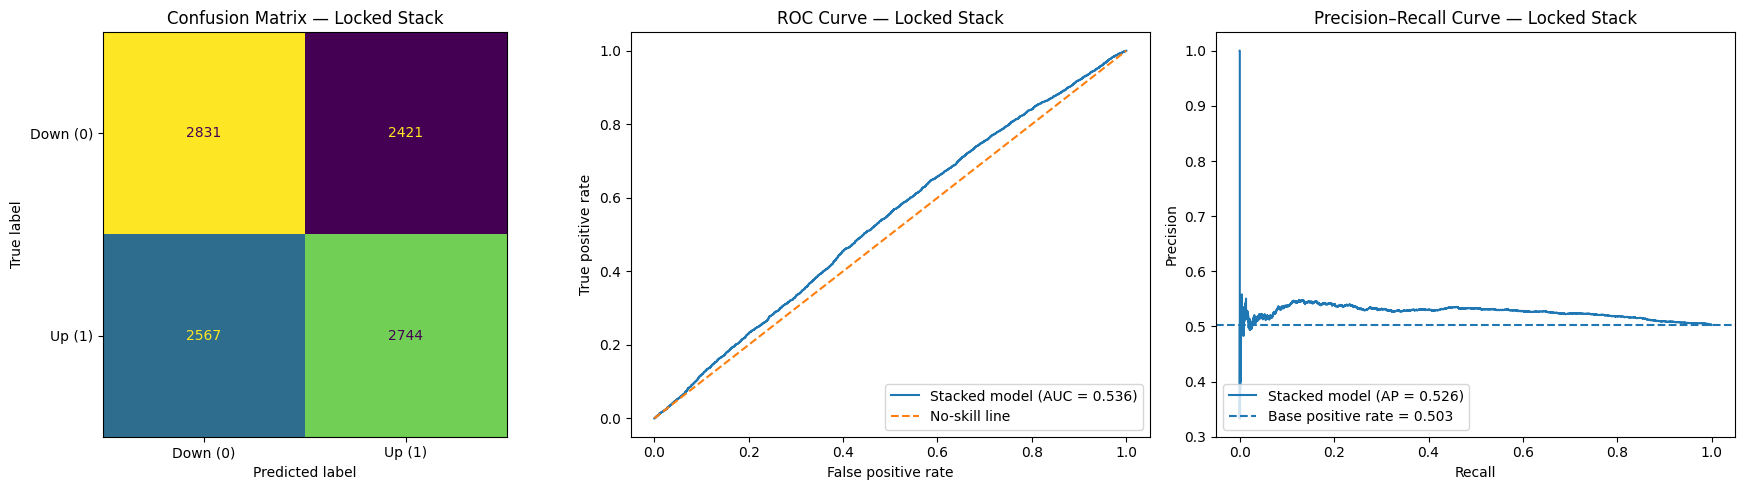

Test Classification Report
              precision    recall  f1-score   support

    Down (0)     0.5245    0.5390    0.5316      5252
      Up (1)     0.5313    0.5167    0.5239      5311

    accuracy                         0.5278     10563
   macro avg     0.5279    0.5278    0.5278     10563
weighted avg     0.5279    0.5278    0.5277     10563



In [155]:
# Plot classification diagnostics for the locked stack
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score,
    classification_report, precision_recall_curve, roc_curve)

y_true = test_results["target_4h"]
y_score = test_results["stack_score"]
y_pred = test_results["stack_prediction"].astype(int)

fpr, tpr, _ = roc_curve(y_true, y_score)
pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_score)

roc_auc = roc_auc_score(y_true, y_score)
average_precision = average_precision_score(y_true, y_score)
base_rate = y_true.mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Down (0)", "Up (1)"],
    colorbar=False,
    ax=axes[0])

axes[0].set_title("Confusion Matrix — Locked Stack")

axes[1].plot(fpr, tpr, label=f"Stacked model (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", label="No-skill line")
axes[1].set_title("ROC Curve — Locked Stack")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")

axes[2].plot(
    pr_recall,
    pr_precision,
    label=f"Stacked model (AP = {average_precision:.3f})")

axes[2].axhline(
    base_rate,
    linestyle="--",
    label=f"Base positive rate = {base_rate:.3f}")

axes[2].set_title("Precision–Recall Curve — Locked Stack")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

print("Test Classification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Down (0)", "Up (1)"],
    digits=4))

The locked CatBoost–SVM–GRU stack achieved a ROC-AUC of 0.5361 and balanced accuracy of 0.5278 on 10,563 dead-zone-filtered observations from the untouched test period. Both metrics remained above 0.50 without test-set tuning, indicating modest out-of-sample directional discrimination.

Class performance was relatively balanced. The model correctly identified 53.9% of negative outcomes and 51.7% of positive outcomes, producing 2,831 true negatives and 2,744 true positives. Precision and recall for the positive class were 0.5313 and 0.5167 respectively.

The predicted positive rate was 48.9%, compared with a realised positive rate of 50.3%. Average precision was approximately 0.526, modestly above the unconditional positive-rate benchmark. Overall, the primary stack retained a weak but measurable directional signal, but the classification results alone remain insufficient to establish economic viability.

In [156]:
# Compare cross-fitted OOF and untouched test performance
comparison = pd.DataFrame({
    "sample": ["Chronological OOF", "Untouched test"],
    "roc_auc": [
        stack_fold_metrics["roc_auc"].mean(),
        test_metrics.loc[0, "roc_auc"]],
    "balanced_accuracy": [
        stack_fold_metrics["balanced_accuracy"].mean(),
        test_metrics.loc[0, "balanced_accuracy"]]})

display(comparison.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}"}))

,sample,roc_auc,balanced_accuracy
0,Chronological OOF,0.5687,0.5406
1,Untouched test,0.5361,0.5278


Performance moderated on the untouched test set, with ROC-AUC declining from 0.5687 to 0.5361 and balanced accuracy from 0.5406 to 0.5278. Both metrics remained above 0.50 without test-set tuning, indicating that the primary stack retained modest out-of-sample directional discrimination. The decline nevertheless confirms weaker generalisation beyond the chronological OOF sample.

**b) Performance Stability**

Performance stability is assessed through quarterly test metrics and train-to-test feature shifts. The quarterly analysis identifies whether the aggregate test result is broadly distributed through time or concentrated in particular market periods, while the feature-shift analysis highlights changes in the model-input distribution. The locked base learners, Level-1 meta-model and 0.50 classification threshold remain unchanged throughout.

**i) Quarterly Test Performance**

Quarterly metrics are calculated on the same dead-zone-filtered untouched test sample to assess how the stack’s ranking and classification performance vary through time.

In [157]:
# Assess quarterly performance on the untouched stacked-model test sample
quarterly_rows = []

quarters = test_results.index.tz_localize(None).to_period("Q")

for quarter, group in test_results.groupby(quarters):
    y_true = group["target_4h"]
    y_score = group["stack_score"]
    y_pred = group["stack_prediction"].astype(int)

    quarterly_rows.append({
        "quarter": str(quarter),
        "observations": len(group),
        "roc_auc": roc_auc_score(y_true, y_score),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "actual_positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean()    })

quarterly_performance = pd.DataFrame(quarterly_rows)

quarterly_performance.to_csv(DATA_PATH / "final_stacked_test_quarterly_performance_4h.csv", index=False)

display(quarterly_performance.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "accuracy": "{:.4f}",
    "actual_positive_rate": "{:.3f}",
    "predicted_positive_rate": "{:.3f}"}))

,quarter,observations,roc_auc,balanced_accuracy,accuracy,actual_positive_rate,predicted_positive_rate
0,2025Q1,422,0.5211,0.5267,0.5237,0.526,0.443
1,2025Q2,2031,0.5626,0.5462,0.5460,0.519,0.497
2,2025Q3,2001,0.5449,0.5304,0.5297,0.506,0.442
3,2025Q4,2058,0.5441,0.5308,0.5306,0.507,0.483
4,2026Q1,2036,0.5241,0.5258,0.5250,0.486,0.526
5,2026Q2,2015,0.5151,0.5083,0.5082,0.492,0.505


Quarterly performance was strongest in 2025Q2, with ROC-AUC of 0.5626 and balanced accuracy of 0.5462. The model remained above 0.54 ROC-AUC through 2025Q4, with balanced accuracy close to 0.53 in both 2025Q3 and 2025Q4.

Performance weakened in 2026, falling to ROC-AUC of 0.5151 and balanced accuracy of 0.5083 by 2026Q2. This indicates that the primary stack retained useful signal in parts of the test period, but the feature–target relationship became materially weaker toward the end of the sample.

**ii) Train-to-Test Feature Shift**

Standardised mean shifts identify which locked predictors changed most between the training and test periods. This provides evidence of distributional change in the model inputs and helps assess whether weaker test performance may be associated with a different market regime.

In [158]:
# Measure train-to-test shifts in the locked feature set
train_mean = X_train_engineered[selected_features].mean()
train_std = X_train_engineered[selected_features].std().replace(0, np.nan)
test_mean = X_test_engineered[selected_features].mean()

feature_shift = pd.DataFrame({
    "feature": selected_features,
    "standardised_mean_shift": ((test_mean - train_mean) / train_std).reindex(selected_features).to_numpy()})

feature_shift["absolute_shift"] = feature_shift["standardised_mean_shift"].abs()
feature_shift = feature_shift.sort_values("absolute_shift", ascending=False)

feature_shift.to_csv(DATA_PATH / "final_test_feature_shift_4h.csv", index=False)

display(feature_shift.head(10).style.format({
    "standardised_mean_shift": "{:+.3f}",
    "absolute_shift": "{:.3f}"}))

,feature,standardised_mean_shift,absolute_shift
25,btc_rv_24h,-0.480,0.480
27,deribit_curve_slope_pct,-0.474,0.474
8,btc_vol_of_vol_24h,-0.419,0.419
26,deribit_total_log_notional,+0.294,0.294
28,sth_lth_mvrv_spread,+0.210,0.210
21,exchange_net_position_signed_log,-0.202,0.202
23,btc_drawdown_24h,+0.197,0.197
5,mvrv_zscore_168h,-0.102,0.102
3,btc_ret_24h,-0.059,0.059
0,btc_logprice_slope_24h,-0.054,0.054


The largest train-to-test shifts were concentrated in volatility conditions, derivatives structure and on-chain state. Test-period 24-hour realised volatility, volatility-of-volatility and the Deribit curve slope were materially lower than in training, while aggregate Deribit notional increased. The short-term versus long-term holder MVRV spread also rose, exchange net positioning declined and the 24-hour BTC drawdown measure shifted upward.

By contrast, the mean shifts in 24-hour BTC return and log-price slope were comparatively small. The deterioration in test performance is therefore more consistent with changes in volatility, derivatives-market structure and holder-state conditions than with the selected four-hour horizon being inherently unsuitable. These relationships are associative rather than causal, but they support a regime-change interpretation of the weaker test results.

### **Part II: Fixed 30% CatBoost–70% SVM Benchmark**

#### **a) Evaluate the Locked Fixed-Weight Benchmark**

The locked benchmark is evaluated on the same 10,563 dead-zone-filtered test observations used for the primary stack. CatBoost and SVM test scores are first mapped to their frozen training OOF percentile distributions, then combined using the pre-specified 30%–70% weights. The comparison therefore isolates the effect of the simpler fixed-weight architecture without changing the test sample, threshold or target definition.

In [159]:
# Evaluate the fixed CatBoost-SVM benchmark on the dead-zone-filtered test sample
benchmark_scores = fixed_cat_svm_test.set_index("timestamp")
benchmark_scores.index = pd.to_datetime(benchmark_scores.index, utc=True)

benchmark_results = test_classification[["fwd_logret_4h", "target_4h"]].join(
    benchmark_scores[["fixed_cat_svm_score", "fixed_cat_svm_prediction"]], how="inner")

y_true_benchmark = benchmark_results["target_4h"]
y_score_benchmark = benchmark_results["fixed_cat_svm_score"]
y_pred_benchmark = benchmark_results["fixed_cat_svm_prediction"].astype(int)

benchmark_metrics = pd.DataFrame([{
    "observations": len(benchmark_results),
    "roc_auc": roc_auc_score(y_true_benchmark, y_score_benchmark),
    "balanced_accuracy": balanced_accuracy_score(y_true_benchmark, y_pred_benchmark),
    "accuracy": accuracy_score(y_true_benchmark, y_pred_benchmark),
    "precision": precision_score(y_true_benchmark, y_pred_benchmark),
    "recall": recall_score(y_true_benchmark, y_pred_benchmark),
    "f1": f1_score(y_true_benchmark, y_pred_benchmark),
    "actual_positive_rate": y_true_benchmark.mean(),
    "predicted_positive_rate": y_pred_benchmark.mean()}])

benchmark_confusion = pd.DataFrame(
    confusion_matrix(y_true_benchmark, y_pred_benchmark),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"])

benchmark_results.reset_index().to_csv(DATA_PATH / "fixed_cat_svm_test_classification_predictions_4h.csv", index=False)
benchmark_metrics.to_csv(DATA_PATH / "fixed_cat_svm_test_classification_metrics_4h.csv", index=False)
benchmark_confusion.to_csv(DATA_PATH / "fixed_cat_svm_test_confusion_matrix_4h.csv")

print(f"Benchmark test scores: {len(benchmark_scores):,}")
print(f"Classification observations: {len(benchmark_results):,}")

display(benchmark_metrics.round(4))
display(benchmark_confusion)

Benchmark test scores: 11,391
Classification observations: 10,563


,observations,roc_auc,balanced_accuracy,accuracy,precision,recall,f1,actual_positive_rate,predicted_positive_rate
0,10563,0.5345,0.5240,0.5236,0.5303,0.4598,0.4925,0.5028,0.4360


,Predicted 0,Predicted 1
Actual 0,3089,2163
Actual 1,2869,2442


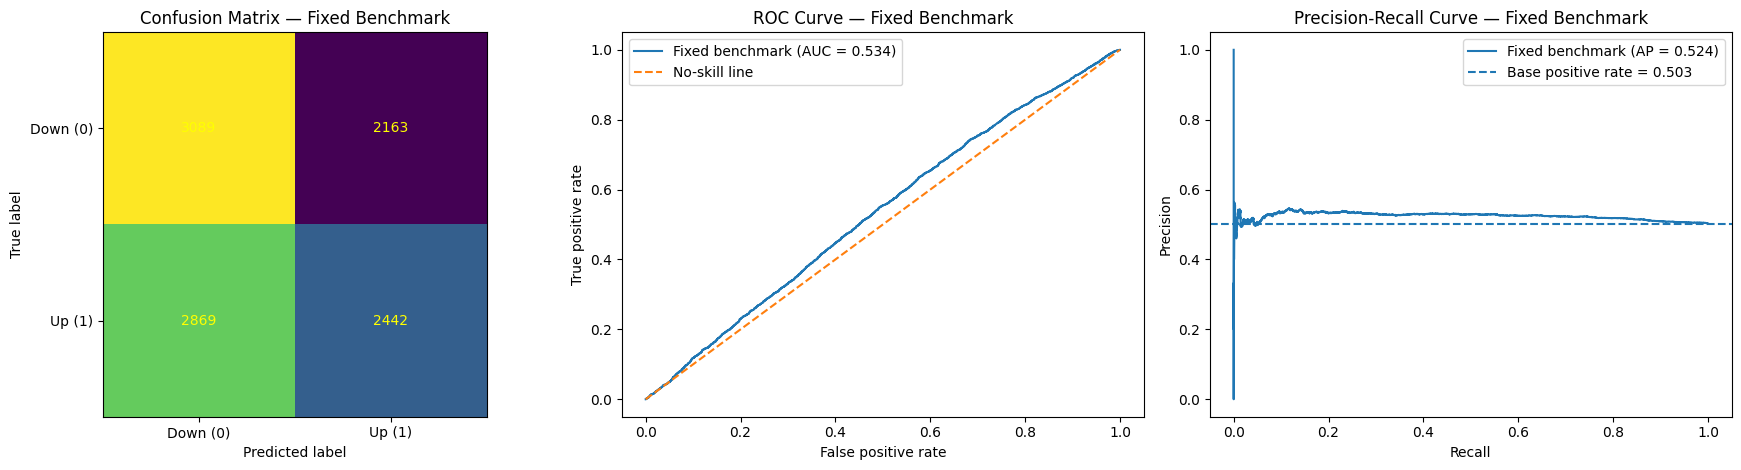

Benchmark Classification Report
              precision    recall  f1-score   support

    Down (0)     0.5185    0.5882    0.5511      5252
      Up (1)     0.5303    0.4598    0.4925      5311

    accuracy                         0.5236     10563
   macro avg     0.5244    0.5240    0.5218     10563
weighted avg     0.5244    0.5236    0.5217     10563



In [160]:
# Plot benchmark confusion matrix, ROC curve and precision-recall curve
from sklearn.metrics import average_precision_score, classification_report, precision_recall_curve, roc_curve

fpr_benchmark, tpr_benchmark, _ = roc_curve(y_true_benchmark, y_score_benchmark)
precision_benchmark, recall_benchmark, _ = precision_recall_curve(y_true_benchmark, y_score_benchmark)
ap_benchmark = average_precision_score(y_true_benchmark, y_score_benchmark)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].imshow(benchmark_confusion, cmap="viridis")
axes[0].set_title("Confusion Matrix — Fixed Benchmark")
axes[0].set_xticks([0, 1], ["Down (0)", "Up (1)"])
axes[0].set_yticks([0, 1], ["Down (0)", "Up (1)"])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, benchmark_confusion.iloc[i, j], ha="center", va="center", color="yellow")

axes[1].plot(fpr_benchmark, tpr_benchmark, label=f"Fixed benchmark (AUC = {benchmark_metrics.loc[0, 'roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", label="No-skill line")
axes[1].set_title("ROC Curve — Fixed Benchmark")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

axes[2].plot(recall_benchmark, precision_benchmark, label=f"Fixed benchmark (AP = {ap_benchmark:.3f})")
axes[2].axhline(y_true_benchmark.mean(), linestyle="--", label=f"Base positive rate = {y_true_benchmark.mean():.3f}")
axes[2].set_title("Precision-Recall Curve — Fixed Benchmark")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Benchmark Classification Report")
print(classification_report(y_true_benchmark, y_pred_benchmark, target_names=["Down (0)", "Up (1)"], digits=4))

The locked fixed benchmark achieved a ROC-AUC of 0.5345 and balanced accuracy of 0.5240 on the same 10,563 dead-zone-filtered observations. Both metrics remained above 0.50 without test-period tuning, but were slightly below the primary stack’s ROC-AUC of 0.5361 and balanced accuracy of 0.5278.

The benchmark predicted positive outcomes less frequently, with a predicted-positive rate of 43.6% against a realised rate of 50.3%. It correctly identified 58.8% of negative outcomes but only 46.0% of positive outcomes, producing 3,089 true negatives and 2,442 true positives. This greater downside sensitivity may still be economically useful, particularly for short-side or tail-based strategies, despite the weaker aggregate classification metrics.

#### **b) Performance Stability**

**Quarterly Test Performance**

In [162]:
# Evaluate quarterly stability of the fixed CatBoost-SVM benchmark
benchmark_quarterly = benchmark_results.copy()
benchmark_quarterly["quarter"] = benchmark_quarterly.index.tz_localize(None).to_period("Q").astype(str)

quarterly_rows = []

for quarter, data in benchmark_quarterly.groupby("quarter"):
    y_true_q = data["target_4h"]
    y_score_q = data["fixed_cat_svm_score"]
    y_pred_q = data["fixed_cat_svm_prediction"].astype(int)

    quarterly_rows.append({
        "quarter": quarter,
        "observations": len(data),
        "roc_auc": roc_auc_score(y_true_q, y_score_q),
        "balanced_accuracy": balanced_accuracy_score(y_true_q, y_pred_q),
        "accuracy": accuracy_score(y_true_q, y_pred_q),
        "actual_positive_rate": y_true_q.mean(),
        "predicted_positive_rate": y_pred_q.mean()})

benchmark_quarterly_metrics = pd.DataFrame(quarterly_rows)
benchmark_quarterly_metrics.to_csv(DATA_PATH / "fixed_cat_svm_test_quarterly_performance_4h.csv", index=False)

display(benchmark_quarterly_metrics.style.format({
    "roc_auc": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "accuracy": "{:.4f}",
    "actual_positive_rate": "{:.3f}",
    "predicted_positive_rate": "{:.3f}"}))

,quarter,observations,roc_auc,balanced_accuracy,accuracy,actual_positive_rate,predicted_positive_rate
0,2025Q1,422,0.5188,0.5177,0.5118,0.526,0.389
1,2025Q2,2031,0.5598,0.5436,0.5411,0.519,0.437
2,2025Q3,2001,0.5437,0.5259,0.5247,0.506,0.396
3,2025Q4,2058,0.5443,0.5307,0.5296,0.507,0.421
4,2026Q1,2036,0.5218,0.5175,0.5182,0.486,0.475
5,2026Q2,2015,0.5124,0.5060,0.5067,0.492,0.459


Quarterly performance followed the same broad pattern as the primary stack. The fixed CatBoost–SVM benchmark was strongest in 2025Q2, reaching ROC-AUC of 0.5598 and balanced accuracy of 0.5436, and remained above 0.54 ROC-AUC through 2025Q4.

Performance weakened in 2026, falling to ROC-AUC of 0.5124 and balanced accuracy of 0.5060 by 2026Q2. The benchmark also maintained a lower predicted-positive rate throughout most quarters, reflecting its stronger downside bias and helping explain its higher negative-class recall but weaker positive-class recall.

**c) Model Testing Conclusions**

The primary CatBoost–SVM–GRU stack performed more weakly on the untouched test set than during chronological OOF validation, but retained a modest margin above the 0.50 benchmark. Test ROC-AUC was 0.5361 and balanced accuracy was 0.5278 across 10,563 dead-zone-filtered observations, compared with chronological OOF values of 0.5687 and 0.5406.

Class behaviour remained relatively balanced. The stack correctly identified 53.9% of negative outcomes and 51.7% of positive outcomes, while its predicted positive rate of 48.9% remained close to the realised positive rate of 50.3%.

The fixed 30% CatBoost–70% SVM benchmark produced similar but slightly weaker results, with ROC-AUC of 0.5345 and balanced accuracy of 0.5240. This confirms that the simpler blend retained comparable directional information, although the supervised stack remained the stronger specification on the aggregate test metrics.

Quarterly performance and feature-shift analysis indicate that the reduction in performance was not uniform through time. Results were strongest in 2025Q2 and weakened into 2026, with 2026Q2 approaching coin-flip performance. The largest train-to-test shifts were concentrated in volatility conditions, Deribit market structure and on-chain holder-state variables rather than in directional BTC trend measures, supporting a regime-dependent interpretation of the weaker test results.

Overall, the primary stack retained a weak but measurable out-of-sample directional signal, but the margin remained too small to establish economic viability from classification results alone. The next stage therefore evaluates whether the primary and benchmark scores can support tradable strategies after accounting for overlapping horizons, turnover, execution rules and transaction costs.

## **(XI) P&L Simulation and Backtesting**

Backtesting is required to assess whether either locked ensemble’s statistical signal has economic value. Classification metrics can show whether the primary CatBoost–SVM–GRU stack and the fixed 30% CatBoost–70% SVM benchmark contain out-of-sample directional information. Weak realised returns, excessive turnover, transaction costs or poorly specified execution rules may eliminate an otherwise measurable forecasting advantage.

This section converts both sets of locked test scores into explicit trading positions and evaluates them under identical assumptions, allowing a fair economic comparison between the supervised stack and the simpler fixed-weight benchmark. Performance is assessed against BTC buy-and-hold using total and annualised return, Sharpe ratio, maximum drawdown, exposure, turnover and trading frequency.

Because both models predict the four-hour forward return of BTCUSDT perpetual futures, the backtests use fixed four-hour UTC decision points at 00:00, 04:00, 08:00, 12:00, 16:00 and 20:00. Positions are rebalanced only at these times and held until the next decision point, producing non-overlapping four-hour return periods. The same thresholds, position rules, transaction-cost assumptions and evaluation sample are applied to both specifications so that any performance difference reflects the model scores rather than unequal backtest design.

**a) Assess Realised Returns Across Locked Stack-Score Brackets**

Untouched test observations are assigned to five fixed brackets using percentiles of the locked training OOF stack-score distribution. This avoids selecting score thresholds from the test sample and evaluates whether different score regions are associated with systematically different realised four-hour returns.

A broadly monotonic return pattern would support the economic ranking value of the stack. Irregular bracket performance would instead indicate that any useful information is concentrated in particular score regions.

In [163]:
# Evaluate fixed OOF-relative bracket strategies
TC_BPS = 5
tc_rate = TC_BPS / 10_000
periods_per_year = 6 * 365

stack_reference = pd.read_csv(DATA_PATH / "final_stacker_training_oof_4h.csv")
stack_reference = stack_reference["stack_score"].dropna().sort_values().to_numpy()

def empirical_percentile(values, reference):
    return np.searchsorted(reference, np.asarray(values), side="right") / len(reference)

backtest = stacked_test_scores[["stack_score"]].copy()
backtest["score_percentile"] = empirical_percentile(backtest["stack_score"], stack_reference)
backtest = backtest.join(targets_test[["fwd_logret_4h"]], how="inner")
backtest = backtest[backtest.index.hour % 4 == 0].dropna()
backtest["btc_return_4h"] = np.expm1(backtest["fwd_logret_4h"])

backtest["score_bracket"] = pd.cut(
    backtest["score_percentile"],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
    include_lowest=True,
    right=False)

def backtest_metrics(period_return, signal):
    period_return = period_return.fillna(0)
    signal = signal.reindex(period_return.index).fillna(0)

    wealth = (1 + period_return).cumprod()
    years = len(period_return) / periods_per_year
    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    annual_volatility = period_return.std() * np.sqrt(periods_per_year)

    period_std = period_return.std()
    sharpe = np.nan if period_std == 0 else period_return.mean() / period_std * np.sqrt(periods_per_year)

    drawdown = wealth / wealth.cummax() - 1
    maximum_drawdown = drawdown.min()
    calmar = np.nan if maximum_drawdown == 0 else annual_return / abs(maximum_drawdown)

    turnover = signal.diff().abs()
    turnover.iloc[0] = abs(signal.iloc[0])

    active = signal.ne(0)
    entries = active & signal.shift(1, fill_value=0).eq(0)

    return {
        "periods": len(period_return),
        "active_periods": int(active.sum()),
        "entries": int(entries.sum()),
        "exposure": signal.abs().mean(),
        "final_wealth": wealth.iloc[-1],
        "total_return": wealth.iloc[-1] - 1,
        "annualised_return": annual_return,
        "annualised_volatility": annual_volatility,
        "sharpe_ratio": sharpe,
        "maximum_drawdown": maximum_drawdown,
        "calmar_ratio": calmar,
        "turnover_sides": turnover.sum(),
        "trades_per_year": entries.sum() / years,
        "win_rate": period_return[active].gt(0).mean() if active.any() else np.nan}

q = backtest["score_percentile"]

bottom_20 = q.lt(0.20)
bottom_40 = q.lt(0.40)
top_40 = q.ge(0.60)
top_20 = q.ge(0.80)

strategy_specs = {
    "Long-Only Top 20%": top_20.astype(float),
    "Short-Only Bottom 20%": -bottom_20.astype(float),
    "Long-Short Top/Bottom 20%": top_20.astype(float) - bottom_20.astype(float),
    "Long-Only Top 40%": top_40.astype(float),
    "Short-Only Bottom 40%": -bottom_40.astype(float),
    "Long-Short Top/Bottom 40%": top_40.astype(float) - bottom_40.astype(float)
}

strategy_rows = []

for strategy, signal in strategy_specs.items():
    turnover = signal.diff().abs()
    turnover.iloc[0] = abs(signal.iloc[0])

    net_return = signal * backtest["btc_return_4h"] - turnover * tc_rate

    strategy_rows.append({
        "strategy": strategy,
        **backtest_metrics(net_return, signal)})

strategy_table = pd.DataFrame(strategy_rows)
strategy_table = strategy_table.sort_values(
    ["sharpe_ratio", "annualised_return"],
    ascending=False).reset_index(drop=True)

benchmark_signal = pd.Series(1.0, index=backtest.index)
benchmark_turnover = benchmark_signal.diff().abs()
benchmark_turnover.iloc[0] = abs(benchmark_signal.iloc[0])

benchmark_return = (benchmark_signal * backtest["btc_return_4h"] - benchmark_turnover * tc_rate)

benchmark_table = pd.DataFrame([{"strategy": "BTC Buy-and-Hold", **backtest_metrics(benchmark_return, benchmark_signal)}])

benchmark_table.to_csv(DATA_PATH / "final_stacked_buy_hold_4h.csv", index=False)
strategy_table.to_csv(DATA_PATH / "final_stacked_bracket_strategies_4h.csv", index=False)

display(benchmark_table.round(4))
display(strategy_table.round(4))

,strategy,periods,active_periods,entries,exposure,final_wealth,total_return,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,calmar_ratio,turnover_sides,trades_per_year,win_rate
0,BTC Buy-and-Hold,2846,2846,1,1.0000,0.7115,-0.2885,-0.2304,0.4153,-0.4227,-0.5346,-0.4310,1.0000,0.7695,0.5000


,strategy,periods,active_periods,entries,exposure,final_wealth,total_return,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,calmar_ratio,turnover_sides,trades_per_year,win_rate
0,Short-Only Bottom 20%,2846,699,376,0.2456,1.0730,0.0730,0.0557,0.1851,0.3852,-0.1948,0.2859,752.0000,289.3324,0.5465
1,Long-Short Top/Bottom 20%,2846,1056,583,0.3710,0.9644,-0.0356,-0.0275,0.2392,0.0029,-0.2185,-0.1258,"1,252.0000",448.6191,0.5350
2,Short-Only Bottom 40%,2846,1341,534,0.4712,0.8830,-0.1170,-0.0913,0.2665,-0.2258,-0.2721,-0.3355,"1,068.0000",410.9136,0.5205
3,Long-Only Top 20%,2846,357,250,0.1254,0.8988,-0.1012,-0.0788,0.1517,-0.4654,-0.1462,-0.5392,500.0000,192.3753,0.5154
4,Long-Short Top/Bottom 40%,2846,2271,452,0.7980,0.5258,-0.4742,-0.3902,0.3729,-1.1398,-0.5479,-0.7123,"1,979.0000",347.8145,0.5073
5,Long-Only Top 40%,2846,930,456,0.3268,0.5955,-0.4045,-0.3289,0.2604,-1.4009,-0.4258,-0.7725,911.0000,350.8925,0.5043


Economic performance was strongest in the lowest score tail. The short-only bottom-20% strategy was the only tested specification to produce positive net performance after transaction costs of 5 basis points per traded side, with a total return of 7.3%, an annualised return of 5.6% and a Sharpe ratio of 0.39. Its 54.7% win rate indicates that the most bearish score region retained economically relevant directional information.

Over the same period, BTC buy-and-hold, after applying the same 5 basis point entry cost, produced a total return of approximately -28.8%, an annualised return of -23.0% and a Sharpe ratio of -0.42. The short-only bottom-tail strategy therefore materially outperformed passive BTC exposure while also limiting maximum drawdown to 19.5%.

The broader top-40%, bottom-40% and long-short specifications performed materially worse, indicating that the economic information was concentrated in the most bearish score tail rather than distributed symmetrically across the score range. With 752 traded sides and approximately 24.6% exposure, the bottom-20% short-only strategy established a positive but still modest level of economic viability that requires further robustness testing.

**b) Assess Realised Returns Across Fixed 30% CatBoost–70% SVM Score Brackets**

The fixed-weight benchmark is evaluated using the same non-overlapping four-hour periods, percentile brackets, position rules and 5-basis-point transaction cost applied to the primary stack. Holding the backtest design constant allows any difference in realised performance to be attributed to the benchmark score rather than to different execution assumptions.

In [172]:
# Evaluate fixed OOF-relative benchmark bracket strategies
benchmark_backtest = backtest.drop(columns=["stack_score", "score_rank"], errors="ignore").join(
    benchmark_scores["fixed_cat_svm_score"].rename("benchmark_score"), how="inner")

benchmark_score_reference = benchmark_reference["benchmark_score_reference"].dropna().to_numpy()
benchmark_backtest["score_percentile"] = empirical_percentile(
    benchmark_backtest["benchmark_score"], benchmark_score_reference)

benchmark_positions = {
    "Short-Only Bottom 20%": np.where(benchmark_backtest["score_percentile"] <= 0.20, -1.0, 0.0),
    "Long-Only Top 20%": np.where(benchmark_backtest["score_percentile"] >= 0.80, 1.0, 0.0),
    "Long-Short Top/Bottom 20%": np.select(
        [benchmark_backtest["score_percentile"] <= 0.20, benchmark_backtest["score_percentile"] >= 0.80],
        [-1.0, 1.0], default=0.0),
    "Short-Only Bottom 40%": np.where(benchmark_backtest["score_percentile"] <= 0.40, -1.0, 0.0),
    "Long-Only Top 40%": np.where(benchmark_backtest["score_percentile"] >= 0.60, 1.0, 0.0),
    "Long-Short Top/Bottom 40%": np.select(
        [benchmark_backtest["score_percentile"] <= 0.40, benchmark_backtest["score_percentile"] >= 0.60],
        [-1.0, 1.0], default=0.0)}

benchmark_strategy_rows = []

for name, values in benchmark_positions.items():
    signal = pd.Series(values, index=benchmark_backtest.index)
    turnover = signal.diff().abs()
    turnover.iloc[0] = abs(signal.iloc[0])
    net_return = signal * benchmark_backtest["btc_return_4h"] - turnover * tc_rate
    metrics = backtest_metrics(net_return, signal)
    benchmark_strategy_rows.append({"strategy": name, **metrics})

benchmark_strategy_table = pd.DataFrame(benchmark_strategy_rows)
benchmark_strategy_table = benchmark_strategy_table.sort_values(
    ["sharpe_ratio", "annualised_return"], ascending=False).reset_index(drop=True)

benchmark_strategy_table.to_csv(
    DATA_PATH / "final_fixed_cat_svm_bracket_strategies_4h.csv", index=False)

display(benchmark_table.round(4))
display(benchmark_strategy_table.round(4))

,strategy,periods,active_periods,entries,exposure,final_wealth,total_return,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,calmar_ratio,turnover_sides,trades_per_year,win_rate
0,BTC Buy-and-Hold,2846,2846,1,1.0000,0.7115,-0.2885,-0.2304,0.4153,-0.4227,-0.5346,-0.4310,1.0000,0.7695,0.5000


,strategy,periods,active_periods,entries,exposure,final_wealth,total_return,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,calmar_ratio,turnover_sides,trades_per_year,win_rate
0,Short-Only Bottom 20%,2846,705,382,0.2477,0.9387,-0.0613,-0.0475,0.1945,-0.1527,-0.2300,-0.2065,764.0000,293.9494,0.5404
1,Short-Only Bottom 40%,2846,1326,530,0.4659,0.8697,-0.1303,-0.1019,0.2654,-0.2721,-0.2852,-0.3572,"1,060.0000",407.8356,0.5143
2,Long-Short Top/Bottom 20%,2846,1072,595,0.3767,0.8555,-0.1445,-0.1131,0.2484,-0.3589,-0.2325,-0.4866,"1,278.0000",457.8531,0.5308
3,Long-Only Top 20%,2846,367,257,0.1290,0.9114,-0.0886,-0.0689,0.1547,-0.3845,-0.1704,-0.4045,514.0000,197.7618,0.5150
4,Long-Short Top/Bottom 40%,2846,2272,455,0.7983,0.5167,-0.4833,-0.3984,0.3740,-1.1711,-0.5507,-0.7234,"1,963.0000",350.1230,0.5044
5,Long-Only Top 40%,2846,946,452,0.3324,0.5943,-0.4057,-0.3300,0.2629,-1.3912,-0.4184,-0.7887,903.0000,347.8145,0.5085


The fixed 30% CatBoost–70% SVM benchmark preserved the same broad concentration of economic information in the bearish score tail, but did not produce positive net performance. Its strongest specification, short-only bottom 20%, returned -6.1% with an annualised return of -4.8% and a Sharpe ratio of -0.15, despite a 54.0% win rate and approximately 24.8% exposure.

By comparison, the primary stack’s short-only bottom-20% strategy produced a positive 7.3% total return, 5.6% annualised return and a Sharpe ratio of 0.39 under the same 5-basis-point transaction-cost assumption. It also achieved a slightly higher 54.7% win rate, with similar exposure but marginally lower turnover.

The comparison indicates that the supervised stack added economically useful information beyond the simpler fixed blend. Aggregate classification performance differed only modestly, but the stack ranked the most bearish observations more effectively in realised-return terms. Its advantage therefore appears primarily in tail separation and economic payoff rather than in a large improvement in headline classification metrics.

**c) Transaction-Cost Sensitivity of the Primary Stack**

The strongest strategy identified in the fixed-bracket comparison, the short-only bottom-20% rule, is evaluated across transaction costs of 0, 3 and 5 basis points per traded side. This separates the underlying gross signal from the effect of turnover and assesses whether the bearish tail remains economically viable under alternative execution-cost assumptions.

In [167]:
# Test transaction-cost sensitivity of the primary-stack bottom-20% short strategy
costs_bps = [0, 3, 5]
signal = -backtest["score_percentile"].le(0.20).astype(float)

turnover = signal.diff().abs()
turnover.iloc[0] = abs(signal.iloc[0])
gross_return = signal * backtest["btc_return_4h"]

cost_rows = []

for cost_bps in costs_bps:
    net_return = gross_return - turnover * cost_bps / 10_000
    metrics = backtest_metrics(net_return, signal)
    cost_rows.append({"cost_bps_per_side": cost_bps, **metrics})

cost_comparison = pd.DataFrame(cost_rows)
cost_comparison.to_csv(DATA_PATH / "stacked_bottom_20_short_cost_comparison_4h.csv", index=False)

display(cost_comparison[[
    "cost_bps_per_side",
    "active_periods",
    "entries",
    "exposure",
    "total_return",
    "annualised_return",
    "sharpe_ratio",
    "maximum_drawdown",
    "turnover_sides",
    "trades_per_year",
    "win_rate"
]].round(4))

,cost_bps_per_side,active_periods,entries,exposure,total_return,annualised_return,sharpe_ratio,maximum_drawdown,turnover_sides,trades_per_year,win_rate
0,0,699,376,0.2456,0.5627,0.4099,1.9482,-0.1515,752.0000,289.3324,0.5794
1,3,699,376,0.2456,0.2471,0.1852,1.0108,-0.1772,752.0000,289.3324,0.5622
2,5,699,376,0.2456,0.0730,0.0557,0.3852,-0.1948,752.0000,289.3324,0.5465


The bottom-20% short-only strategy remained profitable across all tested transaction-cost assumptions, but performance was highly cost-sensitive. Gross total return was 56.3% with a Sharpe ratio of 1.95 before costs, declining to 24.7% and 1.01 at 3 basis points per side, and to 7.3% and 0.39 at 5 basis points.

The strategy therefore retained positive net performance at the baseline 5-basis-point assumption, but most of its gross advantage was absorbed by its 752 traded sides. This confirms that the bearish tail signal has economic value while also showing that execution costs and turnover are central constraints on practical viability.

**d) Holding-Period Sensitivity of the Primary Stack**

The bottom-20% short-only strategy produced a meaningful gross signal, but its performance deteriorated sharply as transaction costs increased. Minimum holding periods of 4, 8 and 12 hours are therefore compared to assess whether reducing position changes can preserve more of the short-side edge.

Each short position must remain open for the specified minimum number of four-hour decision intervals before it can be closed. The locked score rule and transaction-cost assumption remain unchanged, so differences in performance reflect the trade-off between lower turnover and slower response to new model signals.

In [168]:
# Test 4-, 8- and 12-hour minimum holds for the bottom-20% short-only strategy
cost_rate = 5 / 10_000
hold_hours = [4, 8, 12]

desired = -backtest["score_percentile"].le(0.20).astype(float)

def apply_minimum_hold(desired_signal, hold_steps):
    signal = pd.Series(0.0, index=desired_signal.index)
    position, lock = 0.0, 0

    for timestamp, target in desired_signal.items():
        if lock == 0 and target != position:
            position, lock = target, hold_steps
        signal.loc[timestamp] = position
        lock = max(lock - 1, 0)

    return signal

hold_rows = []

for hours in hold_hours:
    signal = apply_minimum_hold(desired, hours // 4)

    turnover = signal.diff().abs()
    turnover.iloc[0] = abs(signal.iloc[0])

    net_return = signal * backtest["btc_return_4h"] - turnover * cost_rate
    metrics = backtest_metrics(net_return, signal)

    hold_rows.append({"minimum_hold_hours": hours,**metrics})

hold_comparison = pd.DataFrame(hold_rows)

hold_comparison.to_csv(
    DATA_PATH / "stacked_bottom_20_short_minimum_hold_4h.csv",
    index=False)

display(hold_comparison[[
    "minimum_hold_hours",
    "active_periods",
    "entries",
    "exposure",
    "total_return",
    "annualised_return",
    "sharpe_ratio",
    "maximum_drawdown",
    "turnover_sides",
    "trades_per_year",
    "win_rate"
]].round(4))

,minimum_hold_hours,active_periods,entries,exposure,total_return,annualised_return,sharpe_ratio,maximum_drawdown,turnover_sides,trades_per_year,win_rate
0,4,699,376,0.2456,0.0730,0.0557,0.3852,-0.1948,752.0000,289.3324,0.5465
1,8,795,296,0.2793,0.0674,0.0515,0.3532,-0.2087,592.0000,227.7723,0.5220
2,12,869,241,0.3053,0.2558,0.1916,0.9141,-0.1922,482.0000,185.4498,0.5236


The holding-period sensitivity analysis shows that reducing turnover did not improve performance monotonically, but the 12-hour minimum hold materially strengthened the economics of the bottom-20% short-only strategy. Extending the minimum hold from 4 to 8 hours reduced turnover from 752 to 592 traded sides, although total return eased slightly from 7.3% to 6.7% and the Sharpe ratio declined from 0.39 to 0.35.

The 12-hour minimum hold produced the strongest result. Turnover fell further to 482 traded sides, while total return increased to 25.6%, annualised return to 19.2% and the Sharpe ratio to 0.91. Maximum drawdown remained similar to the four-hour specification at approximately -19.2%, despite exposure rising to 30.5%.

These results indicate that the bearish tail signal can benefit from greater position persistence, particularly at the 12-hour holding period. The improvement appears to reflect both lower turnover and stronger capture of sustained downside moves, rather than turnover reduction alone, since the 8-hour result was slightly weaker than the four-hour baseline. The 8- and 12-hour results remain sensitivity findings based on the untouched test period and should therefore be treated as exploratory rather than as independently validated optimal holding rules.

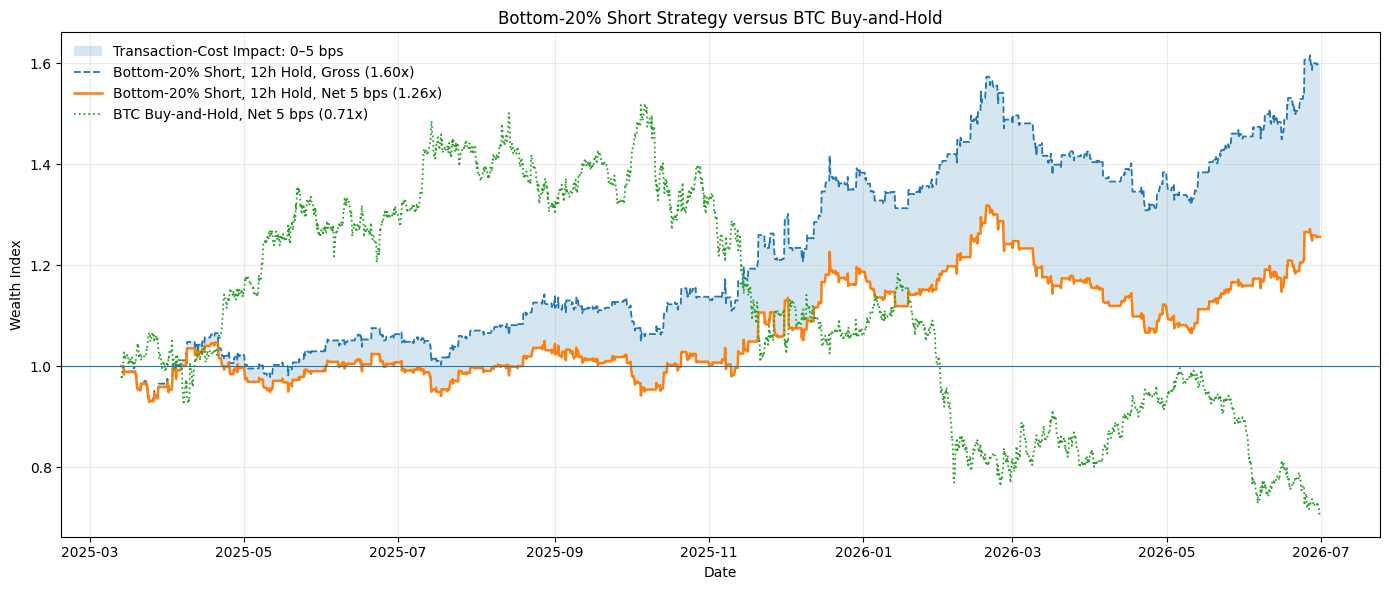

In [169]:
# Plot gross and net 12-hour bottom-20% short strategy against net BTC buy-and-hold
hold_steps = 3
cost_rate = 5 / 10_000

desired = -backtest["score_percentile"].le(0.20).astype(float)
signal = apply_minimum_hold(desired, hold_steps)

turnover = signal.diff().abs()
turnover.iloc[0] = abs(signal.iloc[0])

gross_return = signal * backtest["btc_return_4h"]
net_return = gross_return - turnover * cost_rate

gross_wealth = (1 + gross_return).cumprod()
net_wealth = (1 + net_return).cumprod()

benchmark_signal = pd.Series(1.0, index=backtest.index)
benchmark_turnover = benchmark_signal.diff().abs()
benchmark_turnover.iloc[0] = abs(benchmark_signal.iloc[0])

benchmark_return = (benchmark_signal * backtest["btc_return_4h"] - benchmark_turnover * cost_rate)
benchmark_wealth = (1 + benchmark_return).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(
    gross_wealth.index,
    net_wealth.to_numpy(),
    gross_wealth.to_numpy(),
    alpha=0.18,
    label="Transaction-Cost Impact: 0–5 bps")

ax.plot(
    gross_wealth.index,
    gross_wealth,
    linewidth=1.3,
    linestyle="--",
    label=f"Bottom-20% Short, 12h Hold, Gross ({gross_wealth.iloc[-1]:.2f}x)")

ax.plot(
    net_wealth.index,
    net_wealth,
    linewidth=1.8,
    label=f"Bottom-20% Short, 12h Hold, Net 5 bps ({net_wealth.iloc[-1]:.2f}x)")

ax.plot(
    benchmark_wealth.index,
    benchmark_wealth,
    linewidth=1.3,
    linestyle=":",
    label=f"BTC Buy-and-Hold, Net 5 bps ({benchmark_wealth.iloc[-1]:.2f}x)")

ax.axhline(1, linewidth=0.8)
ax.set_title("Bottom-20% Short Strategy versus BTC Buy-and-Hold")
ax.set_ylabel("Wealth Index")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

The 12-hour bottom-20% short-only strategy remained close to its initial wealth through much of 2025, with repeated drawdowns while BTC was rising. Performance improved materially from late 2025 as market conditions weakened, after which the strategy retained most of its gains while BTC buy-and-hold declined sharply.

After transaction costs of 5 basis points per traded side, the strategy finished at approximately 1.26x wealth, compared with 0.71x for BTC buy-and-hold. The corresponding gross strategy finished near 1.60x, showing that transaction costs continued to absorb a substantial share of the underlying edge.

The chart supports the conclusion that the model’s economic information is concentrated in low-score downside signals and is most effective during weaker BTC regimes. It does not demonstrate uniform profitability across the full test period, because much of the eventual gain was generated after late 2025.

The 12-hour holding rule reduced turnover and improved persistence relative to four-hour rebalancing, producing a return path that appears sufficiently stable to justify a controlled dry run. However, both the holding period and bottom-20% score rule remain exploratory test-period sensitivities rather than independently validated trading specifications. The result should therefore be interpreted as evidence of a regime-dependent bearish tail signal suitable for cautious paper trading, not as proof of a production-ready strategy.

## **(XII) Conclusion**

**a) Project Summary**

This project developed an end-to-end ensemble machine-learning framework for predicting the direction of the four-hour forward return of BTCUSDT perpetual futures. The workflow combined point-in-time-aligned market, derivatives, on-chain, macroeconomic and calendar data with feature engineering, stability-based feature selection, chronological validation, stacking and evaluation on an untouched test period.

The final feature set contained 30 predictors. CatBoost, RBF SVM and GRU were retained as Level-0 learners and combined through a locked logistic-regression meta-model. A fixed 30% CatBoost–70% SVM blend was also retained as a simpler benchmark. All model specifications and the 0.50 classification threshold were fixed before test evaluation.

**b) Main Findings**

The locked stack achieved chronological OOF ROC-AUC of 0.5687 and balanced accuracy of 0.5406. On the untouched test set, performance moderated to ROC-AUC of 0.5361 and balanced accuracy of 0.5278 across 10,563 dead-zone-filtered observations.

The fixed 30% CatBoost–70% SVM benchmark produced similar but slightly weaker classification results, with test ROC-AUC of 0.5345 and balanced accuracy of 0.5240. The difference became more meaningful in the economic evaluation, where the primary stack separated the most bearish observations more effectively.

Quarterly classification performance was strongest in 2025Q2 and weakened into 2026. However, the economic results were concentrated in the lowest score tail, which became more valuable during the weaker market phase. Broad classification quality and tail-strategy profitability therefore did not move together: overall directional discrimination deteriorated, while extreme bearish scores continued to identify economically important downside moves.

At the original four-hour holding period, the primary stack’s bottom-20% short-only strategy produced a 56.3% gross return and a Sharpe ratio of 1.95 before costs. After transaction costs of 5 basis points per traded side, it retained a positive 7.3% total return, 5.6% annualised return and 0.39 Sharpe ratio. The equivalent fixed-weight benchmark remained slightly negative at the same cost assumption.

Extending the minimum holding period to 12 hours reduced turnover from 752 to 482 traded sides and improved the exploratory net result to a 25.6% total return, 19.2% annualised return and 0.91 Sharpe ratio at 5 basis points per side.

**c) Limitations and Practical Implications**

The results do not establish a consistently profitable BTC strategy. Statistical and economic performance varied across regimes, and a substantial share of the 12-hour short strategy’s gains emerged during the weaker market phase from late 2025.

The bottom-20% filter and longer holding periods were examined using test-period economic results. They should therefore be treated as exploratory implementation sensitivities rather than independently validated trading rules.

The backtest also excludes funding, variable spreads, slippage, partial fills and operational constraints. These effects may further reduce realised performance. The 12-hour specification may justify a controlled shadow or paper-trading exercise, but not unrestricted live deployment.

**d) Final Conclusion**

The project shows that a point-in-time-aware feature set and heterogeneous CatBoost–SVM–GRU stack can extract a modest out-of-sample directional signal from BTCUSDT perpetual-futures data.

Economic value was concentrated in bearish tail predictions and remained highly sensitive to turnover and transaction costs. The primary stack outperformed the simpler fixed-weight benchmark in realised-return terms, despite only a small difference in aggregate classification metrics. Extending the minimum holding period to 12 hours further improved the exploratory backtest by reducing turnover and increasing position persistence.

The resulting rule remains regime-dependent and was not independently validated. The model is therefore suitable for frozen-rule shadow deployment and further out-of-sample observation, but not yet for unrestricted live capital allocation.

**e) Further Development**

The immediate next step is frozen-rule shadow deployment of the bottom-20% short strategy using the 12-hour minimum hold, with no recalibration during the observation period. Forward monitoring should record signal frequency, realised execution costs, funding, slippage and performance across rising, falling and range-bound BTC regimes.

Only after sufficient new out-of-sample observations should the score threshold, holding period or model inputs be reconsidered. Further research could compare scheduled rolling refits, explicit regime conditioning and cost-aware execution filters while preserving a separate validation period for any revised specification.

## **References**

- Bergsli, L. Ø., Lind, A. F., Molnár, P. and Polasik, M. (2022). ‘Forecasting volatility of Bitcoin’, *Research in International Business and Finance*, 59, 101540. https://doi.org/10.1016/j.ribaf.2021.101540

- Bysik, A. and Ślepaczuk, R. (2026). ‘Machine Learning-Based Bitcoin Trading Under Transaction Costs: Evidence From Walk-Forward Forecasting’, *arXiv preprint*, arXiv:2606.00060.

- Hasan, M., Abedin, M. Z., Hajek, P., Sultan, N. and Lucey, B. (2022). ‘A Blending Ensemble Learning Model for Crude Oil Price Prediction’, *SSRN Working Paper*. https://doi.org/10.2139/ssrn.4153206

- Nti, I. K., Adekoya, A. F. and Weyori, B. A. (2020). ‘A comprehensive evaluation of ensemble learning for stock-market prediction’, *Journal of Big Data*, 7, 20. https://doi.org/10.1186/s40537-020-00299-5

- Shen, J. and Shafiq, M. O. (2020). ‘Short-term stock market price trend prediction using a comprehensive deep learning system’, *Journal of Big Data*, 7, 66. https://doi.org/10.1186/s40537-020-00333-6

- Zahid, M., Iqbal, F. and Koutmos, D. (2022). ‘Forecasting Bitcoin Volatility Using Hybrid GARCH Models with Machine Learning’, *Risks*, 10(12), 237. https://doi.org/10.3390/risks10120237

### **Housekeeping — HTML Export**

In [173]:
!pip -q install nbconvert==7.* jupyterlab_pygments

from pathlib import Path
import subprocess

project_path = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")
notebook_path = project_path / "CQF Final Project.ipynb"
output_path = project_path / "CQF Final Project - For Submission.html"

subprocess.run(["jupyter", "nbconvert", "--to", "html", "--embed-images", str(notebook_path), "--output", output_path.name, "--output-dir", str(project_path)], check=True)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/CQF Final Project - For Submission.html
